# Final Project Code
---
## Deteksi Penipuan pada Transaksi Kartu Kredit dengan Model Pembelajaran Mendalam Berbasis *Gated Recurrent Neural Network*
---
### Rumusan Masalah
1. Bagaimana penerapan arsitektur *Deep Learning* berbasis *Gated Recurrent Neural Network* seperti *Long Short-Term Memory* (LSTM) dan *Gated Recurrent Unit* (GRU) untuk klasifikasi transaksi penipuan?
2. Bagaimana kinerja model *Deep Learning* berbasis *Gated Recurrent Neural Ne
twork* seperti LSTM dan GRU dalam mendeteksi penipuan?

### Tujuan
1. Mengimplementasikan model *Deep Learning* berbasis *Gated Recurrent Neural
Network* seperti LSTM dan GRU pada dataset transaksi kartu kredit.
2. Menganalisis performa model *Deep Learning* berbasis *Gated Recurrent Neural Network* seperti LSTM dan GRU dalam mendeteksi transaksi penipuan menggunakan parameter evaluasi yang relevan.

### Metrik Utama
1. Recall. Digunakan untuk meminimalkan transaksi penipuan yang lolos pada kelas *Fraud*.
2. F1-Score. Digunakan untuk menjaga keseimbangan antara Recall dan Precision dengan tetap berfokus meminimalkan transaksi penipuan yang lolos tanpa memperbanyak transaksi sah yang salah tuduh.

### DATASET
Dataset yang digunakan dapat dilihat di Kaggle menggunakan tautan berikut.

[Credit Card Transactions Fraud Detection Dataset](https://www.kaggle.com/datasets/kartik2112/fraud-detection)




# Bagian 1 : Import Library

In [1]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support,
                              roc_curve, auc)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (Dense, LSTM, Dropout, GRU, Bidirectional,
                                      Input, Multiply, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Pastikan eager execution aktif (mencegah RuntimeError tf.data saat model.fit)
tf.compat.v1.enable_eager_execution()
assert tf.executing_eagerly(), 'Eager execution tidak aktif - restart runtime lalu run ulang sel ini.'

tf.random.set_seed(67)
np.random.seed(42)

CONFIG = {
    'train_file': 'fraudTrain.csv',
    'test_file':  'fraudTest.csv',
}


# Bagian 2 : Exploratory Data Analysis (EDA)

========== INFO DATA TRAIN ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non

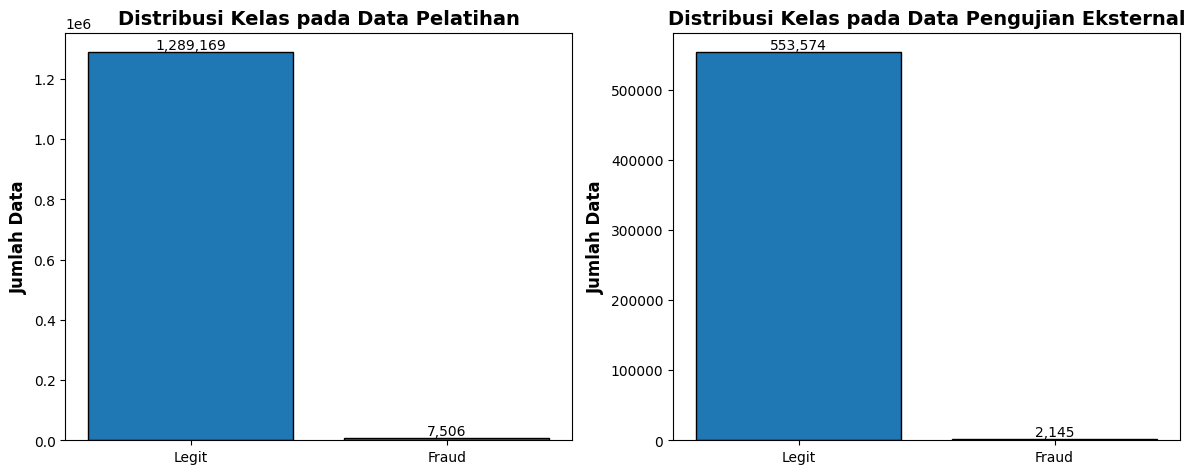


========== KOLOM DATA TRAIN ==========
Unnamed: 0
trans_date_trans_time
cc_num
merchant
category
amt
first
last
gender
street
city
state
zip
lat
long
city_pop
job
dob
trans_num
unix_time
merch_lat
merch_long
is_fraud

========== KOLOM DATA TEST ==========
Unnamed: 0
trans_date_trans_time
cc_num
merchant
category
amt
first
last
gender
street
city
state
zip
lat
long
city_pop
job
dob
trans_num
unix_time
merch_lat
merch_long
is_fraud

Banyak kolom pada dataset masih berupa data mentah,
seperti waktu transaksi, lokasi geografis, identitas merchant,
dan informasi teks lainnya.

Kolom-kolom tersebut belum sepenuhnya representatif
untuk langsung digunakan pada model deep learning,
sehingga diperlukan proses feature engineering untuk
mengekstraksi pola temporal, spasial, dan perilaku transaksi.



In [ ]:
# ============================================================
# III.3 Analisis dan Eksplorasi Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

# ------------------------------------------------------------
# Informasi Dataset
# ------------------------------------------------------------
print("========== INFO DATA TRAIN ==========")
print(train_df.info())

print("\n========== INFO DATA TEST ==========")
print(test_df.info())

# ------------------------------------------------------------
# Visualisasi Distribusi Kelas
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Train
train_counts = train_df['is_fraud'].value_counts().sort_index()

axes[0].bar(['Legit', 'Fraud'],
            train_counts.values,
            edgecolor='black')

axes[0].set_title('Distribusi Kelas pada Data Pelatihan', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')

for i, v in enumerate(train_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Test
test_counts = test_df['is_fraud'].value_counts().sort_index()

axes[1].bar(['Legit', 'Fraud'],
            test_counts.values,
            edgecolor='black')

axes[1].set_title('Distribusi Kelas pada Data Pengujian Eksternal', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')

for i, v in enumerate(test_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Menampilkan Kolom Dataset
# ------------------------------------------------------------

print("\n========== KOLOM DATA TRAIN ==========")
for col in train_df.columns:
    print(col)

print("\n========== KOLOM DATA TEST ==========")
for col in test_df.columns:
    print(col)

# ------------------------------------------------------------
# Penjelasan Awal Feature Engineering
# ------------------------------------------------------------

print("""
Banyak kolom pada dataset masih berupa data mentah,
seperti waktu transaksi, lokasi geografis, identitas merchant,
dan informasi teks lainnya.

Kolom-kolom tersebut belum sepenuhnya representatif
untuk langsung digunakan pada model deep learning,
sehingga diperlukan proses feature engineering untuk
mengekstraksi pola temporal, spasial, dan perilaku transaksi.
""")

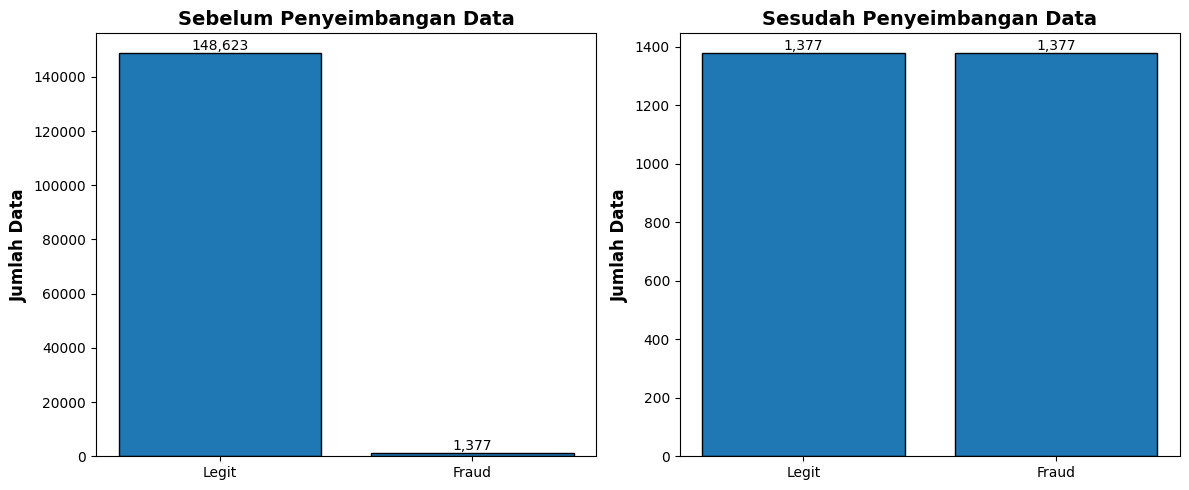

Jumlah data sebelum balancing:
is_fraud
0    148623
1      1377
Name: count, dtype: int64

Jumlah data sesudah balancing:
is_fraud
0    1377
1    1377
Name: count, dtype: int64


In [ ]:
# ============================================================
# III.4 Pengambilan Sampel Data
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

train_df = pd.read_csv('fraudTrain.csv')

# ------------------------------------------------------------
# Mengambil 150.000 Data Pertama
# ------------------------------------------------------------

sample_df = train_df.iloc[:150000].copy()

# ------------------------------------------------------------
# Memisahkan Kelas Fraud dan Legit
# ------------------------------------------------------------

fraud_df = sample_df[sample_df['is_fraud'] == 1]
legit_df = sample_df[sample_df['is_fraud'] == 0]

# ------------------------------------------------------------
# Random Undersampling
# ------------------------------------------------------------

legit_sample = legit_df.sample(
    n=len(fraud_df),
    random_state=42
)

balanced_df = pd.concat([fraud_df, legit_sample])

# Acak ulang data
balanced_df = shuffle(
    balanced_df,
    random_state=42
).reset_index(drop=True)

# ------------------------------------------------------------
# Visualisasi Sebelum dan Sesudah Balancing
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sebelum balancing
before_counts = sample_df['is_fraud'].value_counts().sort_index()

axes[0].bar(['Legit', 'Fraud'],
            before_counts.values,
            edgecolor='black')

axes[0].set_title('Sebelum Penyeimbangan Data', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')

for i, v in enumerate(before_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Sesudah balancing
after_counts = balanced_df['is_fraud'].value_counts().sort_index()

axes[1].bar(['Legit', 'Fraud'],
            after_counts.values,
            edgecolor='black')

axes[1].set_title('Sesudah Penyeimbangan Data', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Jumlah Data', fontsize=12, fontweight='bold')

for i, v in enumerate(after_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Informasi Hasil Sampling
# ------------------------------------------------------------

print("Jumlah data sebelum balancing:")
print(sample_df['is_fraud'].value_counts())

print("\nJumlah data sesudah balancing:")
print(balanced_df['is_fraud'].value_counts())

# Bagian 3 : Pemrosesan Data


## 3.1 Definisi Fungsi-Fungsi Pembantu

In [ ]:
# ===========================================================================
# FUNGSI FEATURE ENGINEERING
# ===========================================================================
def feature_engineering(filepath, nrows=None):
    df = pd.read_csv(filepath, nrows=nrows)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    df['age']            = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
    df['hour']           = df['trans_date_trans_time'].dt.hour
    df['day_of_week']    = df['trans_date_trans_time'].dt.dayofweek
    df['amt_ratio_user'] = df['amt'] / (df.groupby('cc_num')['amt'].transform('mean') + 1e-5)
    df['amt_ratio_cat']  = df['amt'] / (df.groupby('category')['amt'].transform('mean') + 1e-5)
    df['merchant_pop']   = df['merchant'].map(df['merchant'].value_counts())
    df['job_pop']        = df['job'].map(df['job'].value_counts())
    df['amt_log']        = np.log1p(df['amt'])

    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
        return 2 * np.arcsin(np.sqrt(a)) * 6371

    df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])
    df = df.sort_values(['cc_num', 'trans_date_trans_time']).reset_index(drop=True)
    cols_to_drop = ['trans_num','first','last','street','city','state','zip',
                    'job','merchant','trans_date_trans_time','unix_time',
                    'dob','lat','long','merch_lat','merch_long']
    return df.drop(columns=cols_to_drop, errors='ignore')


# ===========================================================================
# FUNGSI GENERATE BALANCED SEQUENCES (SLIDING WINDOW + BALANCE 50:50)
# ===========================================================================
def generate_balanced_sequences(df, seq_len, feature_cols,
                                  target_col='is_fraud', group_col='cc_num'):
    X_list, y_list = [], []
    for _, group in df.groupby(group_col):
        vals_x = group[feature_cols].values
        vals_y = group[target_col].values
        if len(vals_x) < seq_len:
            continue
        _x_win = sliding_window_view(vals_x, (seq_len, len(feature_cols))).squeeze(axis=1)
        _y_win = vals_y[seq_len - 1:]
        min_idx = min(len(_x_win), len(_y_win))
        X_list.append(_x_win[:min_idx])
        y_list.append(_y_win[:min_idx])

    if not X_list:
        return np.array([]), np.array([])

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)
    idx_fraud = np.where(y_all == 1)[0]
    idx_legit = np.where(y_all == 0)[0]
    if len(idx_fraud) == 0:
        return X_all, y_all

    np.random.seed(42)
    idx_legit_s = np.random.choice(idx_legit, size=len(idx_fraud), replace=False)
    balanced = np.concatenate([idx_fraud, idx_legit_s])
    np.random.shuffle(balanced)
    return X_all[balanced], y_all[balanced]


# ===========================================================================
# FUNGSI PLOT TRAINING-VALIDATION LOSS & ACCURACY
# ===========================================================================
def plot_training_history(history, model_name, timestep):
    """Menampilkan kurva loss dan accuracy training vs validasi."""
    plt.figure(figsize=(6, 4))
    plt.plot(history.history['loss'],     label='Train Loss',  linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss',linewidth=2)
    plt.title(f"{model_name} — Loss (TS={timestep})", fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history.history['accuracy'], label='Train Accuracy',  linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy',linewidth=2)
    plt.title(f"{model_name} — Accuracy (TS={timestep})", fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# ===========================================================================
# FUNGSI PLOT AUC-ROC
# ===========================================================================
def plot_roc_curve(model, datasets, model_name, timestep):
    """
    Menampilkan kurva ROC untuk satu atau lebih subset data dalam satu figure.

    Parameters
    ----------
    model    : model Keras yang sudah dilatih
    datasets : list of (X, y, label_string), contoh:
               [(X_val, y_val, 'Validasi'), (X_test, y_test, 'Test Eksternal')]
    model_name : str — nama model untuk judul grafik
    timestep   : int — sequence length untuk judul grafik
    """
    plt.figure(figsize=(6,4))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for (X_ev, y_ev, label), color in zip(datasets, colors):
        y_probs = model.predict(X_ev, verbose=0).flatten()
        fpr, tpr, _ = roc_curve(y_ev, y_probs, pos_label=1)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{label} (AUC = {roc_auc:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.title(f"{model_name} — ROC Curve (TS={timestep})", fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.legend(loc='lower right'); plt.grid()
    plt.tight_layout(); plt.show()


# ===========================================================================
# FUNGSI EVALUASI (training history + AUC-ROC + classification report + CM)
# ===========================================================================
def evaluate_model(model, X_val, y_val, X_test, y_test, model_name, timestep, history=None):
    print(f"\n{'='*66}")
    print(f"EVALUASI {model_name} (TS={timestep})")
    print(f"{'='*66}")

    # 1. Grafik training history
    if history is not None:
        plot_training_history(history, model_name, timestep)

    # 2. Grafik AUC-ROC (validasi + test eksternal dalam satu figure)
    plot_roc_curve(
        model,
        [(X_val,  y_val,  'Validasi (fraudTrain)'),
         (X_test, y_test, 'Test Eksternal (fraudTest)')],
        model_name, timestep
    )

    # 3. Classification report
    for X_ev, y_ev, label in [(X_val, y_val, 'VALIDASI (fraudTrain)'),
                               (X_test, y_test, 'TEST EKSTERNAL (fraudTest)')]:
        y_pred = (model.predict(X_ev, verbose=0) > 0.5).astype(int).flatten()
        print(f"\n[{label}]")
        print(classification_report(y_ev, y_pred, target_names=['Legit (0)','Fraud (1)'], zero_division=0))

    # 4. Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, X_ev, y_ev, title in zip(
            axes,
            [X_val, X_test], [y_val, y_test],
            [f"{model_name} - Validasi (TS={timestep})",
             f"{model_name} - Test Eksternal (TS={timestep})"]):
        y_pred = (model.predict(X_ev, verbose=0) > 0.5).astype(int).flatten()
        cm = confusion_matrix(y_ev, y_pred, labels=[1, 0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Fraud','Legit'], yticklabels=['Fraud','Legit'], ax=ax)
        ax.set_title(title); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.show()


# ===========================================================================
# FUNGSI CROSS VALIDATION (K-Fold Stratified) — hanya fraudTrain
# ===========================================================================
def run_cross_validation(build_fn, X_train_seq, y_train_seq,
                          input_shape, model_name, timestep, k=7):
    print(f"\n{'='*66}")
    print(f"CROSS VALIDATION (K={k}) — {model_name} (TS={timestep})")
    print(f"{'='*66}")
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    cv_results = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_seq, y_train_seq), 1):
        X_f_tr,  y_f_tr  = X_train_seq[tr_idx],  y_train_seq[tr_idx]
        X_f_val, y_f_val = X_train_seq[val_idx], y_train_seq[val_idx]
        model = build_fn(input_shape)
        model.fit(X_f_tr, y_f_tr, validation_data=(X_f_val, y_f_val),
                  epochs=80, batch_size=32, verbose=0)
        y_pred = (model.predict(X_f_val, verbose=0) > 0.5).astype(int).flatten()
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_f_val, y_pred, average='binary', pos_label=1)
        cv_results.append([rec, prec, f1])
        print(f"  Fold {fold}/{k} -> Recall: {rec:.4f} | Precision: {prec:.4f} | F1: {f1:.4f}")

    arr = np.array(cv_results)

    df_report = pd.DataFrame({
        'Metrik Fraud (1)':  ['Recall', 'Precision', 'F1-Score'],
        'Rata-rata (Mean)':  np.mean(arr, axis=0),
        'Variansi (Var)':    np.var(arr, axis=0, ddof=1),
        'Std Deviasi (Std)': np.std(arr, axis=0, ddof=1),
    })
    print("\nTabel Hasil Statistik CV (fraudTrain — Validation Fold):")
    print(df_report.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    plot_data = []
    for f in range(k):
        for mi, mn in enumerate(['Recall', 'Precision', 'F1-Score']):
            plot_data.append({'Fold': f+1, 'Metrik': mn, 'Nilai': arr[f, mi]})
    plt.figure(figsize=(10, 5))
    sns.barplot(data=pd.DataFrame(plot_data), x='Metrik', y='Nilai',
                capsize=0.1, errorbar='sd', color='steelblue')
    plt.title(f"CV (K={k}) — {model_name} (TS={timestep})")
    plt.ylabel("Skor"); plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()
    return df_report


## 3.2 Load Data, Feature Engineering, Scaling & Sekuens

> **Data disiapkan sekali di sini** dan dipakai semua sel model berikutnya.
> Ubah `CUSTOM_TIMESTEP` ke nilai terbaik setelah Sec. 5, lalu *re-run* sel ini.

In [ ]:
# -----------------------------------------------------------------------
# >>> SET SEQUENCE LENGTH TERBAIK DI SINI (setelah menjalankan Sec. 5) <<<
# -----------------------------------------------------------------------
CUSTOM_TIMESTEP = 1

TARGET_COL = 'is_fraud'
GROUP_COL  = 'cc_num'

# Load & feature engineering
df_train_raw = feature_engineering(CONFIG['train_file'], nrows=150000)
df_test_raw  = feature_engineering(CONFIG['test_file'],  nrows=150000)

# One-Hot Encoding
df_train_raw = pd.get_dummies(df_train_raw, drop_first=True)
df_test_raw  = pd.get_dummies(df_test_raw,  drop_first=True)

FEATURE_COLS = [c for c in df_train_raw.columns if c not in [TARGET_COL, GROUP_COL]]

# Selaraskan kolom test
for col in FEATURE_COLS:
    if col not in df_test_raw.columns:
        df_test_raw[col] = 0
df_test_raw = df_test_raw[[GROUP_COL, TARGET_COL] + FEATURE_COLS]

# Scaling (fit train only)
scaler = StandardScaler()
df_train_raw[FEATURE_COLS] = scaler.fit_transform(df_train_raw[FEATURE_COLS])
df_test_raw[FEATURE_COLS]  = scaler.transform(df_test_raw[FEATURE_COLS])

# Sekuens balanced 50:50
X_train_seq, y_train_seq = generate_balanced_sequences(
    df_train_raw, CUSTOM_TIMESTEP, FEATURE_COLS, TARGET_COL, GROUP_COL)
X_test_seq,  y_test_seq  = generate_balanced_sequences(
    df_test_raw,  CUSTOM_TIMESTEP, FEATURE_COLS, TARGET_COL, GROUP_COL)

if len(X_train_seq) == 0 or len(X_test_seq) == 0:
    raise ValueError(f"Data tidak cukup untuk seq_len={CUSTOM_TIMESTEP}.")

# # --- TAMBAHKAN 4 BARIS INI ---
# X_train_seq = np.array(X_train_seq, dtype=np.float32)
# y_train_seq = np.array(y_train_seq, dtype=np.float32)
# X_test_seq  = np.array(X_test_seq, dtype=np.float32)
# y_test_seq  = np.array(y_test_seq, dtype=np.float32)
# # -----------------------------

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, y_train_seq, test_size=0.15, stratify=y_train_seq, random_state=42)

INPUT_SHAPE = (CUSTOM_TIMESTEP, len(FEATURE_COLS))

print(f"Sequence Length  : {CUSTOM_TIMESTEP}")
print(f"Jumlah Fitur     : {len(FEATURE_COLS)}")
print(f"X_tr shape       : {X_tr.shape}")
print(f"X_val shape      : {X_val.shape}")
print(f"X_test shape     : {X_test_seq.shape}")
print(f"Train Fraud/Legit: {sum(y_tr==1)} / {sum(y_tr==0)}")
print(f"Test  Fraud/Legit: {sum(y_test_seq==1)} / {sum(y_test_seq==0)}")


Sequence Length  : 1
Jumlah Fitur     : 26
X_tr shape       : (2340, 1, 26)
X_val shape      : (414, 1, 26)
X_test shape     : (1324, 1, 26)
Train Fraud/Legit: 1170 / 1170
Test  Fraud/Legit: 662 / 662


## 3.3 Data Imbalanced

=== Distribusi Data Imbalanced ===
Sequence Length    : 1
Jumlah Fitur       : 26
X_tr_imb shape     : (42500, 1, 26)
X_val_imb shape    : (7500, 1, 26)
X_test_imb shape   : (50000, 1, 26)
Train Fraud/Legit  : 295 / 42,205  (rasio 1:143)
Test  Fraud/Legit  : 248 / 49,752  (rasio 1:200)


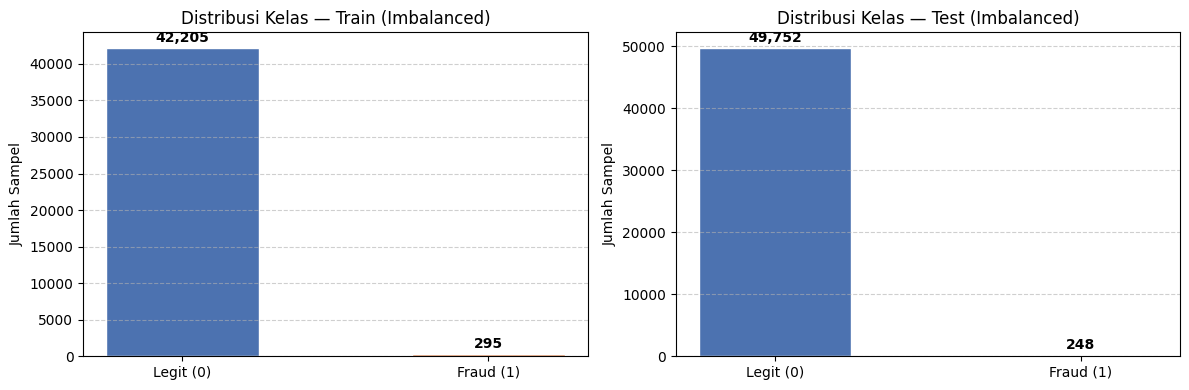

In [ ]:
# ===========================================================================
# FUNGSI SEKUENS TANPA BALANCING (sliding window, urut per cc_num)
# ===========================================================================
def generate_imbalanced_sequences(df, seq_len, feature_cols,
                                   target_col='is_fraud', group_col='cc_num'):
    """Membentuk sekuens sliding window per user TANPA penyeimbangan kelas."""
    X_list, y_list = [], []
    for _, group in df.groupby(group_col):
        vals_x = group[feature_cols].values
        vals_y = group[target_col].values
        if len(vals_x) < seq_len:
            continue
        _x_win = sliding_window_view(vals_x, (seq_len, len(feature_cols))).squeeze(axis=1)
        _y_win = vals_y[seq_len - 1:]
        min_idx = min(len(_x_win), len(_y_win))
        X_list.append(_x_win[:min_idx])
        y_list.append(_y_win[:min_idx])
    if not X_list:
        return np.array([]), np.array([])
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)


# ===========================================================================
# LOAD & PERSIAPAN DATA IMBALANCED (50.000 baris acak)
# ===========================================================================
df_train_imb = feature_engineering(CONFIG['train_file'], nrows=None)
df_train_imb = df_train_imb.iloc[:50000].reset_index(drop=True)

df_test_imb = feature_engineering(CONFIG['test_file'], nrows=None)
df_test_imb = df_test_imb.iloc[:50000].reset_index(drop=True)

# One-Hot Encoding
df_train_imb = pd.get_dummies(df_train_imb, drop_first=True)
df_test_imb  = pd.get_dummies(df_test_imb,  drop_first=True)

FEATURE_COLS_IMB = [c for c in df_train_imb.columns if c not in [TARGET_COL, GROUP_COL]]

# Selaraskan kolom test dengan train
for col in FEATURE_COLS_IMB:
    if col not in df_test_imb.columns:
        df_test_imb[col] = 0
df_test_imb = df_test_imb[[GROUP_COL, TARGET_COL] + FEATURE_COLS_IMB]

# Scaling (fit train only)
scaler_imb = StandardScaler()
df_train_imb[FEATURE_COLS_IMB] = scaler_imb.fit_transform(df_train_imb[FEATURE_COLS_IMB])
df_test_imb[FEATURE_COLS_IMB]  = scaler_imb.transform(df_test_imb[FEATURE_COLS_IMB])

# Bentuk sekuens TANPA balancing
X_train_imb, y_train_imb = generate_imbalanced_sequences(
    df_train_imb, CUSTOM_TIMESTEP, FEATURE_COLS_IMB, TARGET_COL, GROUP_COL)
X_test_imb,  y_test_imb  = generate_imbalanced_sequences(
    df_test_imb,  CUSTOM_TIMESTEP, FEATURE_COLS_IMB, TARGET_COL, GROUP_COL)

if len(X_train_imb) == 0 or len(X_test_imb) == 0:
    raise ValueError(f"Data tidak cukup untuk seq_len={CUSTOM_TIMESTEP} (imbalanced).")

X_tr_imb, X_val_imb, y_tr_imb, y_val_imb = train_test_split(
    X_train_imb, y_train_imb, test_size=0.15, stratify=y_train_imb, random_state=42)

INPUT_SHAPE_IMB = (CUSTOM_TIMESTEP, len(FEATURE_COLS_IMB))

print("=== Distribusi Data Imbalanced ===")
print(f"Sequence Length    : {CUSTOM_TIMESTEP}")
print(f"Jumlah Fitur       : {len(FEATURE_COLS_IMB)}")
print(f"X_tr_imb shape     : {X_tr_imb.shape}")
print(f"X_val_imb shape    : {X_val_imb.shape}")
print(f"X_test_imb shape   : {X_test_imb.shape}")
print(f"Train Fraud/Legit  : {sum(y_tr_imb==1):,} / {sum(y_tr_imb==0):,}  "
      f"(rasio 1:{sum(y_tr_imb==0)//max(sum(y_tr_imb==1),1)})")
print(f"Test  Fraud/Legit  : {sum(y_test_imb==1):,} / {sum(y_test_imb==0):,}  "
      f"(rasio 1:{sum(y_test_imb==0)//max(sum(y_test_imb==1),1)})")

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y, title in zip(axes,
                         [y_tr_imb, y_test_imb],
                         ['Distribusi Kelas — Train (Imbalanced)',
                          'Distribusi Kelas — Test (Imbalanced)']):
    counts = pd.Series(y).value_counts().sort_index()
    bars = ax.bar(['Legit (0)', 'Fraud (1)'], counts.values,
                  color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + counts.max()*0.01,
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title); ax.set_ylabel('Jumlah Sampel')
    ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()



Melatih LSTM — Data Imbalanced (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 32)          │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905 (62.13 KB)

 Trainable params: 15,905 (62.13 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9682 - loss: 0.3414 - val_accuracy: 0.9932 - val_loss: 0.0407
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9934 - loss: 0.0358 - val_accuracy: 0.9940 - val_loss: 0.0259
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9944 - loss: 0.0285 - val_accuracy: 0.9940 - val_loss: 0.0225
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9942 - loss: 0.0252 - val_accuracy: 0.9951 - val_loss: 0.0201
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9952 - loss: 0.0228 - val_accuracy: 0.9951 - val_loss: 0.0183
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9949 - loss: 0.0218 - val_accuracy: 0.9955 - val_loss: 0.0169
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9957 - loss: 0.0203 - val_accuracy: 0.9957 - val_loss: 0.0158
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9957 - loss: 0.0190 - val_accur

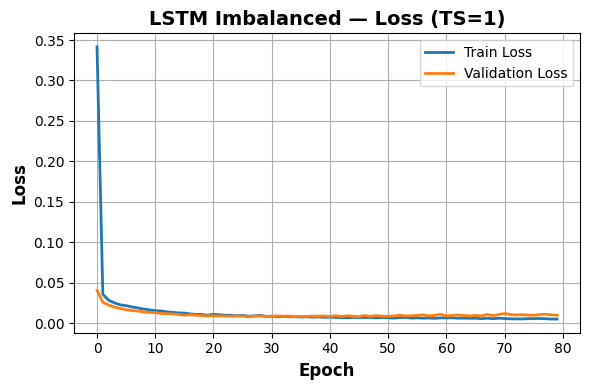

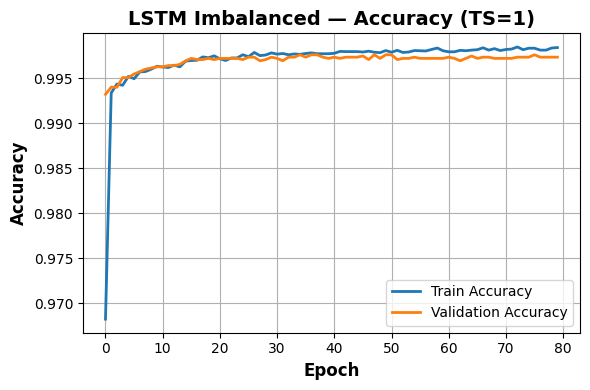

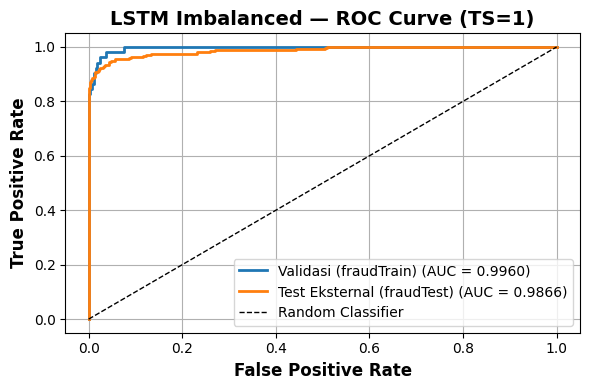


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.92      0.67      0.78        52

    accuracy                           1.00      7500
   macro avg       0.96      0.84      0.89      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     49752
   Fraud (1)       0.88      0.82      0.85       248

    accuracy                           1.00     50000
   macro avg       0.94      0.91      0.92     50000
weighted avg       1.00      1.00      1.00     50000



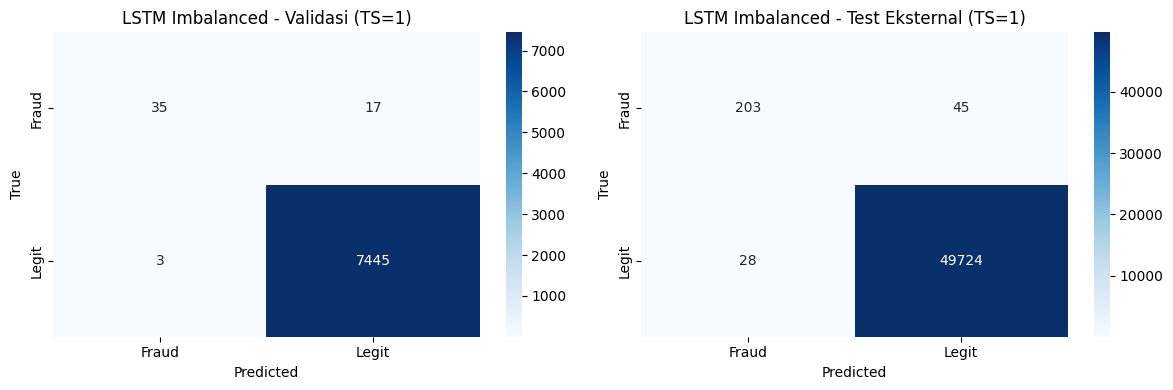

  F1:0.8476 | Recall:0.8185 | Params:15,905

Melatih BiLSTM — Data Imbalanced (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 64)          │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,001 (156.25 KB)

 Trainable params: 40,001 (156.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9731 - loss: 0.2379 - val_accuracy: 0.9940 - val_loss: 0.0275
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9942 - loss: 0.0281 - val_accuracy: 0.9944 - val_loss: 0.0217
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9948 - loss: 0.0237 - val_accuracy: 0.9951 - val_loss: 0.0182
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9953 - loss: 0.0205 - val_accuracy: 0.9955 - val_loss: 0.0159
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9953 - loss: 0.0182 - val_accuracy: 0.9963 - val_loss: 0.0138
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9960 - loss: 0.0165 - val_accuracy: 0.9965 - val_loss: 0.0123
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9958 - loss: 0.0148 - val_accuracy: 0.9969 - val_loss: 0.0118
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9962 - loss: 0.0141 - val

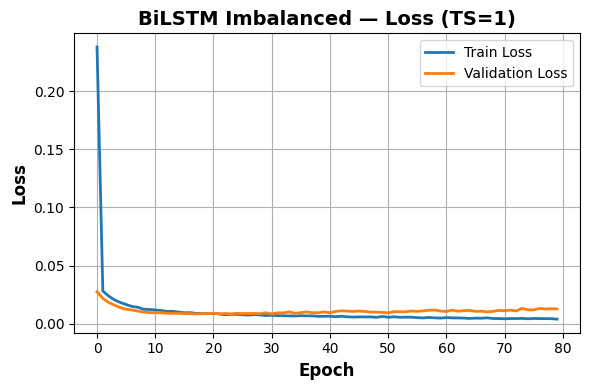

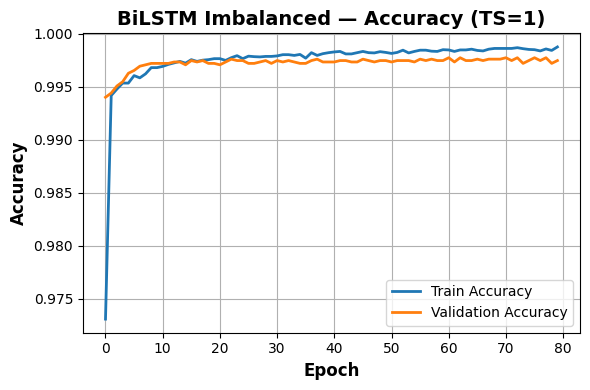

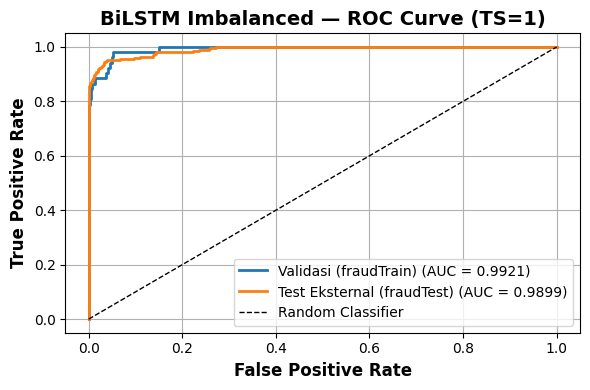


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.95      0.67      0.79        52

    accuracy                           1.00      7500
   macro avg       0.97      0.84      0.89      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     49752
   Fraud (1)       0.87      0.82      0.85       248

    accuracy                           1.00     50000
   macro avg       0.94      0.91      0.92     50000
weighted avg       1.00      1.00      1.00     50000



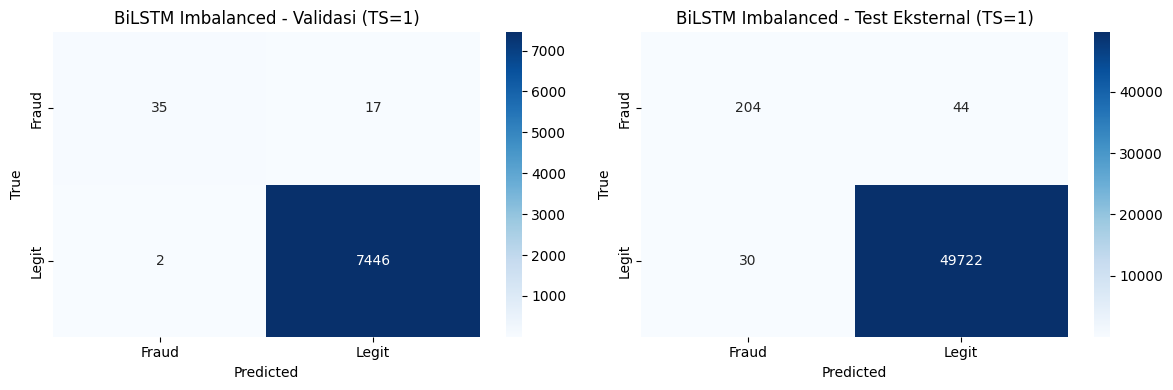

  F1:0.8465 | Recall:0.8226 | Params:40,001

Melatih GRU — Data Imbalanced (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,129 (47.38 KB)

 Trainable params: 12,129 (47.38 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9559 - loss: 0.2369 - val_accuracy: 0.9935 - val_loss: 0.0282
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9937 - loss: 0.0309 - val_accuracy: 0.9944 - val_loss: 0.0216
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9941 - loss: 0.0264 - val_accuracy: 0.9948 - val_loss: 0.0195
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9944 - loss: 0.0239 - val_accuracy: 0.9953 - val_loss: 0.0177
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9948 - loss: 0.0229 - val_accuracy: 0.9953 - val_loss: 0.0170
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9951 - loss: 0.0217 - val_accuracy: 0.9955 - val_loss: 0.0156
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9956 - loss: 0.0203 - val_accuracy: 0.9956 - val_loss: 0.0151
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9957 - loss: 0.0197 - val_accu

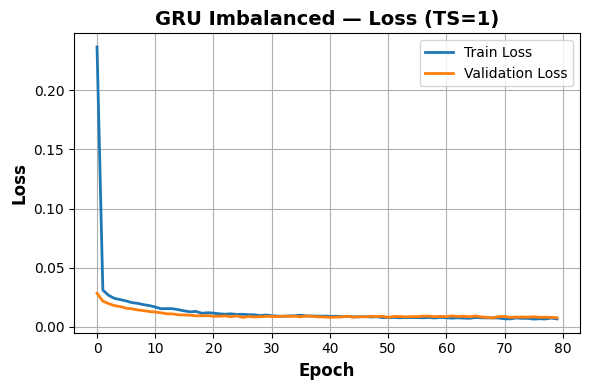

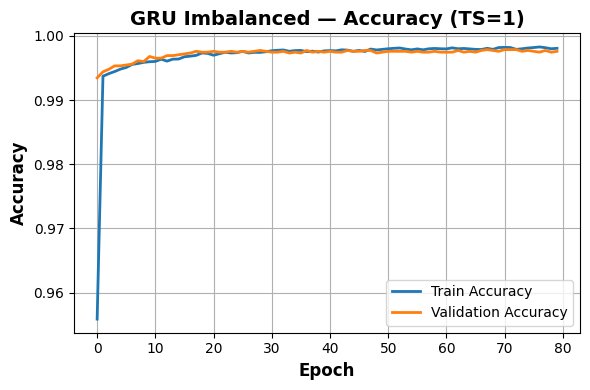

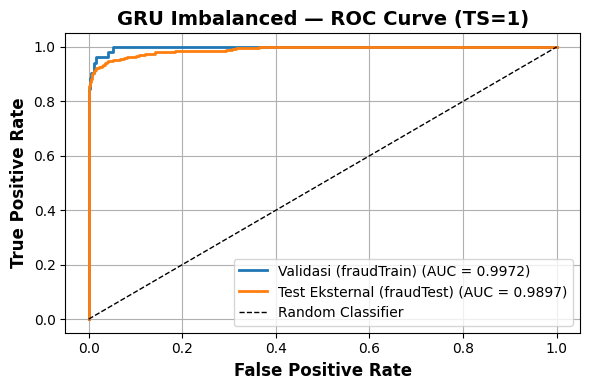


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.93      0.71      0.80        52

    accuracy                           1.00      7500
   macro avg       0.96      0.86      0.90      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     49752
   Fraud (1)       0.83      0.83      0.83       248

    accuracy                           1.00     50000
   macro avg       0.91      0.91      0.91     50000
weighted avg       1.00      1.00      1.00     50000



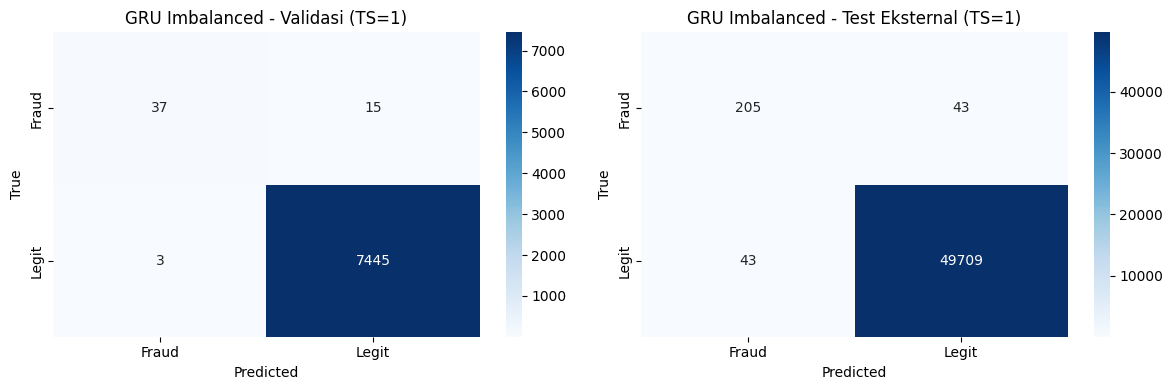

  F1:0.8266 | Recall:0.8266 | Params:12,129

Melatih BiGRU — Data Imbalanced (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 1, 64)          │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9569 - loss: 0.1875 - val_accuracy: 0.9943 - val_loss: 0.0249
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9937 - loss: 0.0283 - val_accuracy: 0.9945 - val_loss: 0.0214
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9943 - loss: 0.0247 - val_accuracy: 0.9947 - val_loss: 0.0193
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9949 - loss: 0.0225 - val_accuracy: 0.9947 - val_loss: 0.0179
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9948 - loss: 0.0211 - val_accuracy: 0.9955 - val_loss: 0.0159
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9953 - loss: 0.0188 - val_accuracy: 0.9957 - val_loss: 0.0146
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9960 - loss: 0.0171 - val_accuracy: 0.9963 - val_loss: 0.0138
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9958 - loss: 0.0164 - val

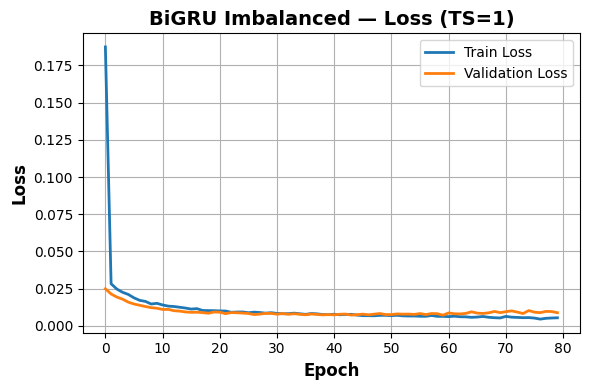

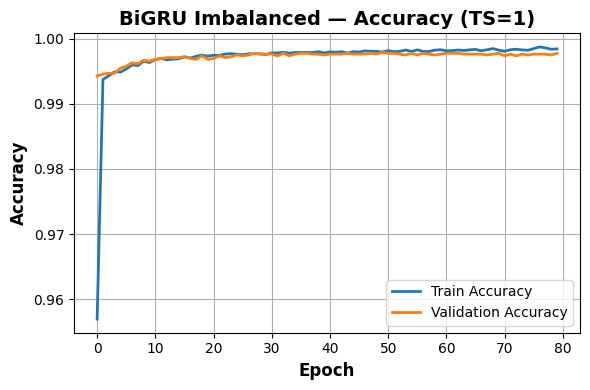

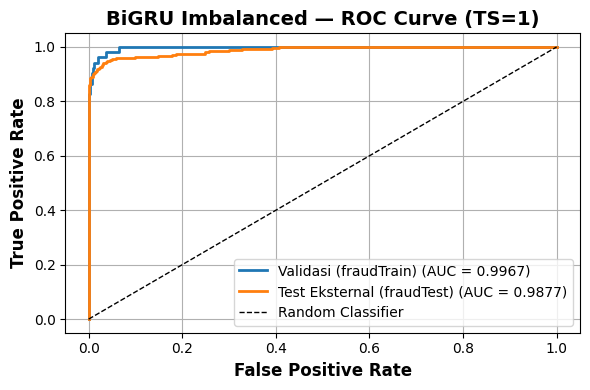


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.95      0.71      0.81        52

    accuracy                           1.00      7500
   macro avg       0.97      0.86      0.91      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     49752
   Fraud (1)       0.83      0.83      0.83       248

    accuracy                           1.00     50000
   macro avg       0.92      0.91      0.92     50000
weighted avg       1.00      1.00      1.00     50000



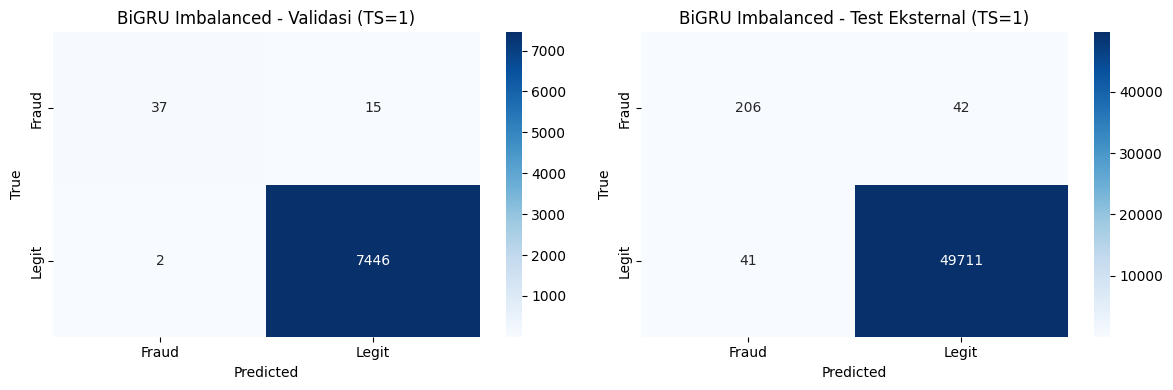

  F1:0.8323 | Recall:0.8306 | Params:30,401

=== Ringkasan Baseline — Data Imbalanced ===
              Model  Precision  Recall     F1  Params
  LSTM (Imbalanced)     0.8788  0.8185 0.8476   15905
BiLSTM (Imbalanced)     0.8718  0.8226 0.8465   40001
   GRU (Imbalanced)     0.8266  0.8266 0.8266   12129
 BiGRU (Imbalanced)     0.8340  0.8306 0.8323   30401


In [ ]:
# ===========================================================================
# PELATIHAN BASELINE (LSTM, BiLSTM, GRU) PADA DATA IMBALANCED
# ===========================================================================
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

baseline_imb_models    = {}
baseline_imb_results   = []

for m_type in ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']:
    print(f"\nMelatih {m_type} — Data Imbalanced (2L-32U)...")
    model = build_baseline_model(m_type, INPUT_SHAPE_IMB)
    print(model.summary())
    history = model.fit(X_tr_imb, y_tr_imb,
                        validation_data=(X_val_imb, y_val_imb),
                        epochs=80, batch_size=256, verbose=1)
    model.save(f"model_imb_baseline_{m_type.lower()}.keras")
    baseline_imb_models[m_type] = model

    evaluate_model(model, X_val_imb, y_val_imb, X_test_imb, y_test_imb,
                   f"{m_type} Imbalanced", CUSTOM_TIMESTEP, history=history)

    y_pred = (model.predict(X_test_imb, verbose=0) > 0.5).astype(int).flatten()
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_imb, y_pred, average='binary', pos_label=1)
    n_params = model.count_params()
    baseline_imb_results.append({'Model': f"{m_type} (Imbalanced)",
                                   'Precision': prec, 'Recall': rec,
                                   'F1': f1, 'Params': n_params})
    print(f"  F1:{f1:.4f} | Recall:{rec:.4f} | Params:{n_params:,}")

print("\n=== Ringkasan Baseline — Data Imbalanced ===")
df_imb_summary = pd.DataFrame(baseline_imb_results)
print(df_imb_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x < 1e3 else f"{int(x):,}"))


Test balanced  — Fraud: 248 | Legit: 248

Melatih LSTM — Train Imbalanced / Test Balanced (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9699 - loss: 0.3268 - val_accuracy: 0.9933 - val_loss: 0.0365
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9937 - loss: 0.0340 - val_accuracy: 0.9944 - val_loss: 0.0232
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9944 - loss: 0.0269 - val_accuracy: 0.9952 - val_loss: 0.0202
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9948 - loss: 0.0243 - val_accuracy: 0.9951 - val_loss: 0.0185
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9950 - loss: 0.0223 - val_accuracy: 0.9951 - val_loss: 0.0167
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9954 - loss: 0.0204 - val_accuracy: 0.9961 - val_loss: 0.0157
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9955 - loss: 0.0198 - val_accuracy: 0.9960 - val_loss: 0.0148
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9959 - loss: 0.0186 - val_accuracy

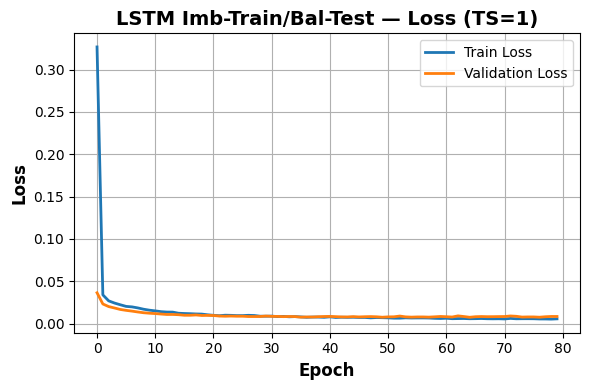

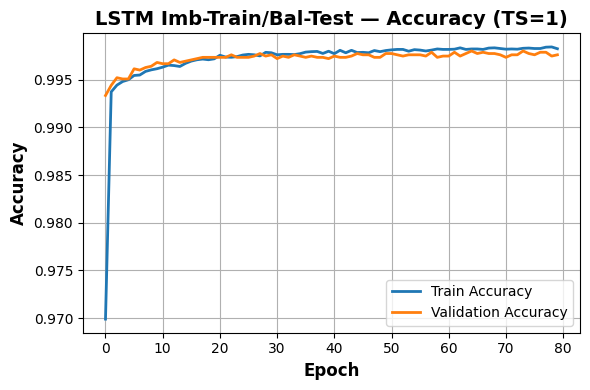

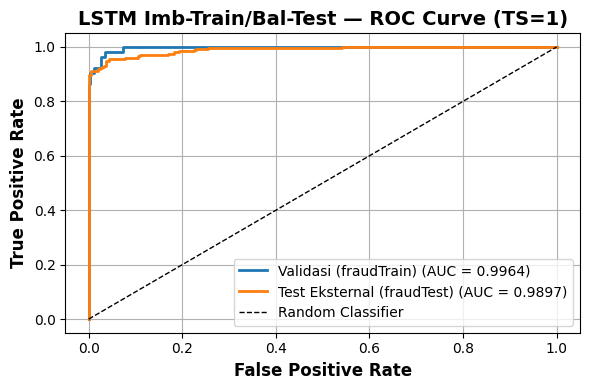


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.95      0.69      0.80        52

    accuracy                           1.00      7500
   macro avg       0.97      0.85      0.90      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.83      1.00      0.91       248
   Fraud (1)       1.00      0.80      0.89       248

    accuracy                           0.90       496
   macro avg       0.92      0.90      0.90       496
weighted avg       0.92      0.90      0.90       496



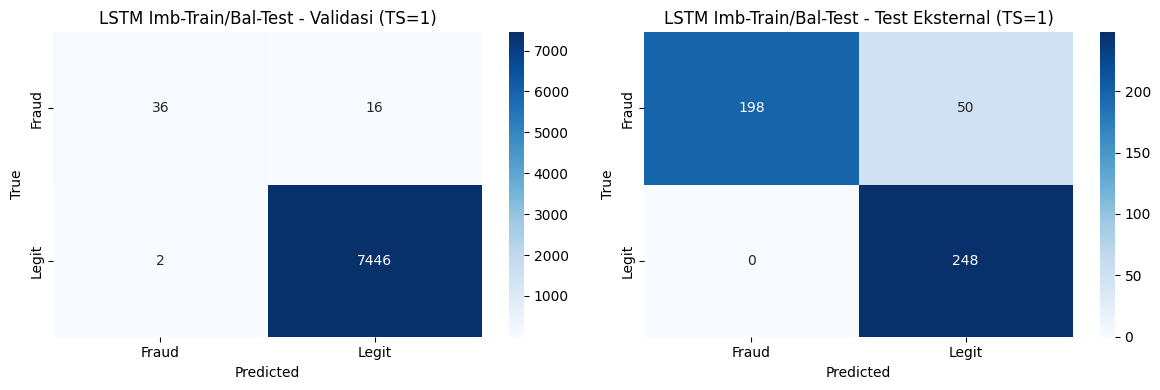

  F1:0.8879 | Recall:0.7984 | Params:15,905

Melatih BiLSTM — Train Imbalanced / Test Balanced (2L-32U)...
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9676 - loss: 0.2390 - val_accuracy: 0.9943 - val_loss: 0.0265
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9942 - loss: 0.0286 - val_accuracy: 0.9947 - val_loss: 0.0212
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9950 - loss: 0.0235 - val_accuracy: 0.9951 - val_loss: 0.0179
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9950 - loss: 0.0209 - val_accuracy: 0.9953 - val_loss: 0.0159
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9954 - loss: 0.0189 - val_accuracy: 0.9961 - val_loss: 0.0142
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9957 - loss: 0.0173 - val_accuracy: 0.9963 - val_loss: 0.0129
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9957 - loss: 0.0163 - val_accuracy: 0.9968 - val_loss: 0.0118
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9960 - loss: 0.0156 - val_accuracy: 0.996

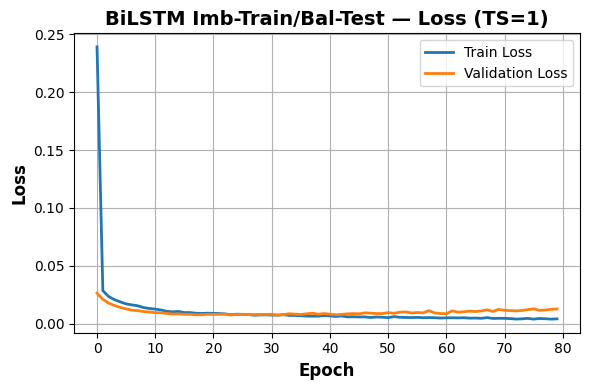

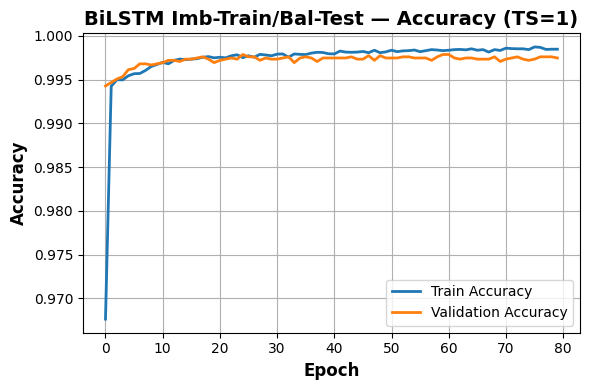

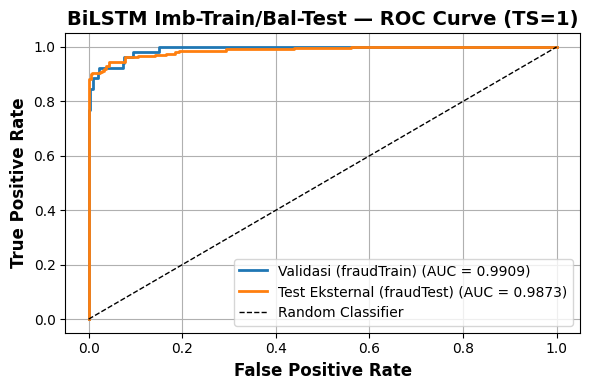


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.92      0.69      0.79        52

    accuracy                           1.00      7500
   macro avg       0.96      0.85      0.89      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.85      1.00      0.92       248
   Fraud (1)       1.00      0.82      0.90       248

    accuracy                           0.91       496
   macro avg       0.92      0.91      0.91       496
weighted avg       0.92      0.91      0.91       496



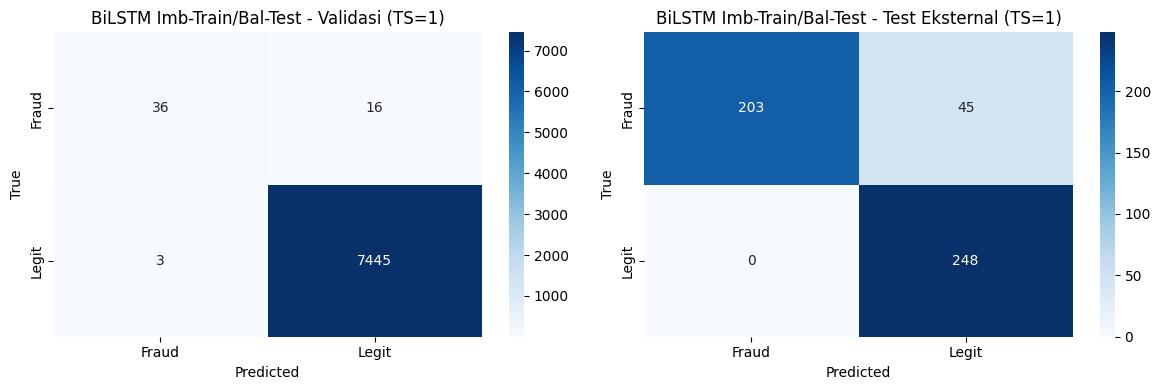

  F1:0.9002 | Recall:0.8185 | Params:40,001

Melatih GRU — Train Imbalanced / Test Balanced (2L-32U)...
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9553 - loss: 0.2407 - val_accuracy: 0.9939 - val_loss: 0.0278
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9939 - loss: 0.0305 - val_accuracy: 0.9947 - val_loss: 0.0214
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9940 - loss: 0.0262 - val_accuracy: 0.9945 - val_loss: 0.0196
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9944 - loss: 0.0244 - val_accuracy: 0.9949 - val_loss: 0.0180
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9950 - loss: 0.0226 - val_accuracy: 0.9948 - val_loss: 0.0167
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9953 - loss: 0.0205 - val_accuracy: 0.9953 - val_loss: 0.0156
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9956 - loss: 0.0201 - val_accuracy: 0.9957 - val_loss: 0.0142
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9958 - loss: 0.0185 - val_accuracy: 0.9961 - v

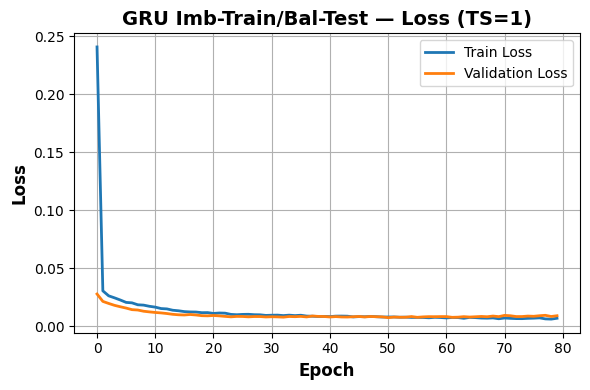

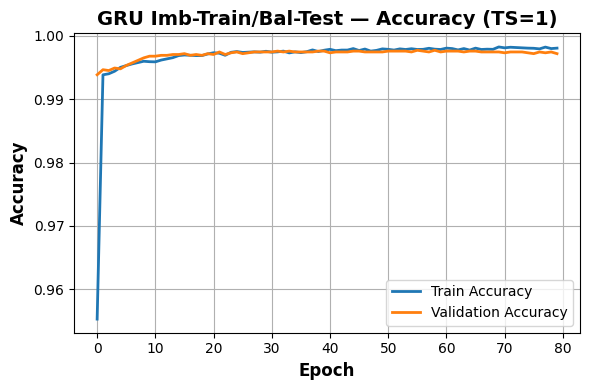

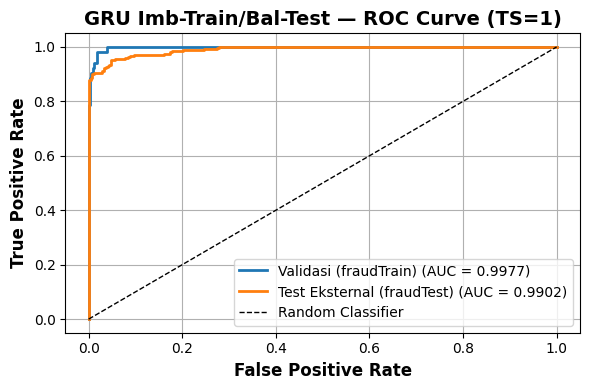


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.92      0.65      0.76        52

    accuracy                           1.00      7500
   macro avg       0.96      0.83      0.88      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.84      1.00      0.92       248
   Fraud (1)       1.00      0.81      0.90       248

    accuracy                           0.91       496
   macro avg       0.92      0.91      0.91       496
weighted avg       0.92      0.91      0.91       496



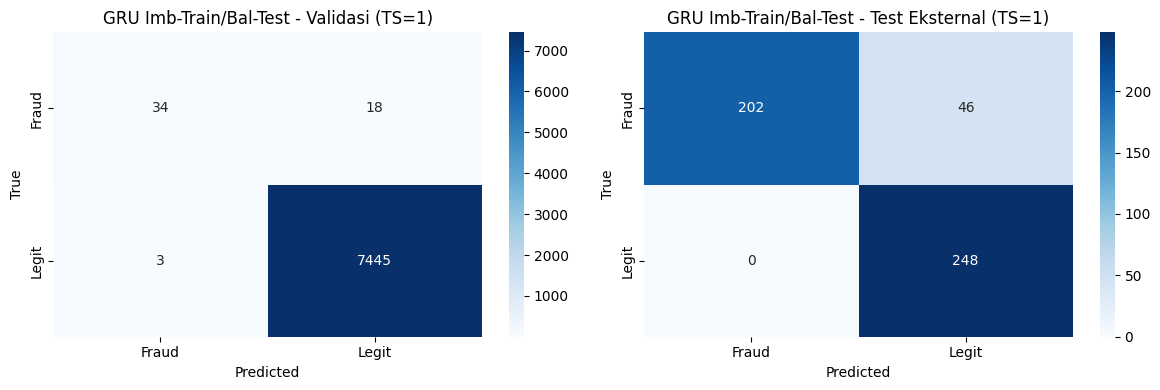

  F1:0.8978 | Recall:0.8145 | Params:12,129

Melatih BiGRU — Train Imbalanced / Test Balanced (2L-32U)...
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9642 - loss: 0.1715 - val_accuracy: 0.9939 - val_loss: 0.0236
Epoch 2/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9938 - loss: 0.0277 - val_accuracy: 0.9945 - val_loss: 0.0197
Epoch 3/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9945 - loss: 0.0241 - val_accuracy: 0.9951 - val_loss: 0.0178
Epoch 4/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9950 - loss: 0.0222 - val_accuracy: 0.9953 - val_loss: 0.0165
Epoch 5/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9949 - loss: 0.0209 - val_accuracy: 0.9959 - val_loss: 0.0151
Epoch 6/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9956 - loss: 0.0191 - val_accuracy: 0.9960 - val_loss: 0.0145
Epoch 7/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9958 - loss: 0.0178 - val_accuracy: 0.9961 - val_loss: 0.0134
Epoch 8/80
167/167 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9960 - loss: 0.0169 - val_accuracy: 0.996

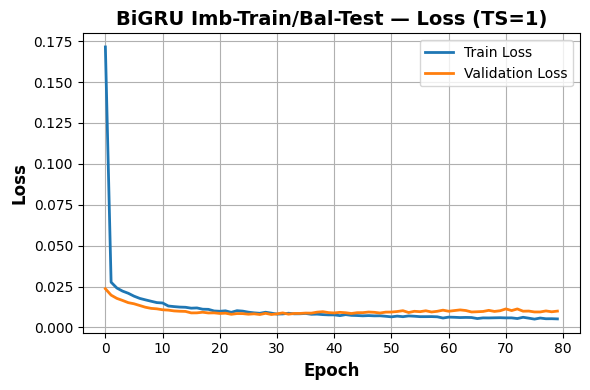

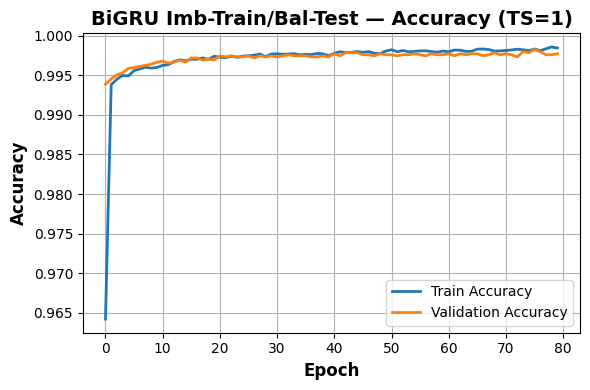

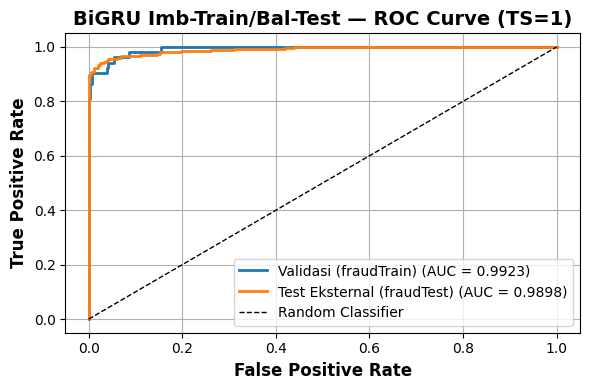


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00      7448
   Fraud (1)       0.93      0.73      0.82        52

    accuracy                           1.00      7500
   macro avg       0.96      0.87      0.91      7500
weighted avg       1.00      1.00      1.00      7500


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.87      1.00      0.93       248
   Fraud (1)       1.00      0.85      0.92       248

    accuracy                           0.93       496
   macro avg       0.94      0.93      0.92       496
weighted avg       0.94      0.93      0.92       496



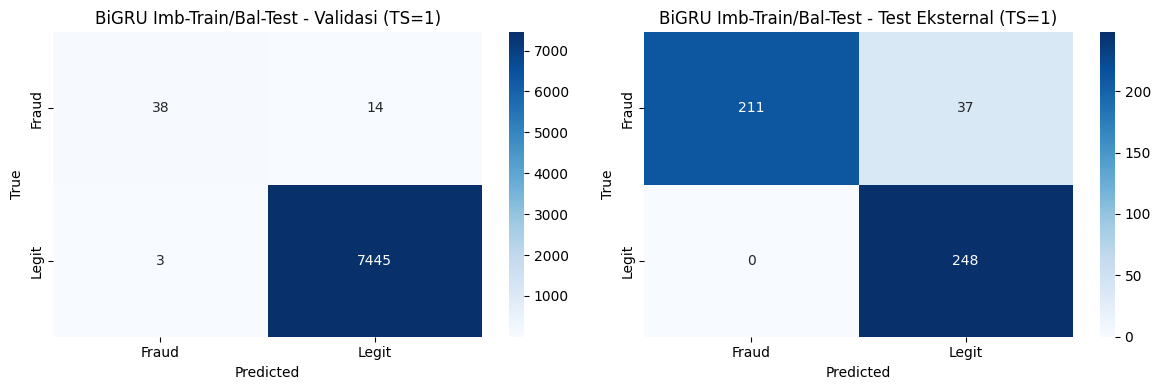

  F1:0.9194 | Recall:0.8508 | Params:30,401

=== Ringkasan Baseline — Train Imbalanced / Test Balanced ===
                      Model  Precision  Recall     F1  Params
  LSTM (Imb-Train/Bal-Test)     1.0000  0.7984 0.8879   15905
BiLSTM (Imb-Train/Bal-Test)     1.0000  0.8185 0.9002   40001
   GRU (Imb-Train/Bal-Test)     1.0000  0.8145 0.8978   12129
 BiGRU (Imb-Train/Bal-Test)     1.0000  0.8508 0.9194   30401


In [ ]:
# ===========================================================================
# PELATIHAN BASELINE — TRAIN IMBALANCED, TEST DISEIMBANGKAN
# ===========================================================================
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

# Seimbangkan data test eksternal (pakai df_test_imb yang sudah di-scale)
X_test_imb_bal, y_test_imb_bal = generate_balanced_sequences(
    df_test_imb, CUSTOM_TIMESTEP, FEATURE_COLS_IMB, TARGET_COL, GROUP_COL)

print(f"Test balanced  — Fraud: {sum(y_test_imb_bal==1):,} | Legit: {sum(y_test_imb_bal==0):,}")

baseline_imb_bal_models  = {}
baseline_imb_bal_results = []

for m_type in ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']:
    print(f"\nMelatih {m_type} — Train Imbalanced / Test Balanced (2L-32U)...")
    model = build_baseline_model(m_type, INPUT_SHAPE_IMB)
    history = model.fit(X_tr_imb, y_tr_imb,
                        validation_data=(X_val_imb, y_val_imb),
                        epochs=80, batch_size=256, verbose=1)
    model.save(f"model_imb_bal_baseline_{m_type.lower()}.keras")
    baseline_imb_bal_models[m_type] = model

    # Evaluasi: val tetap imbalanced, test sudah balanced
    evaluate_model(model, X_val_imb, y_val_imb, X_test_imb_bal, y_test_imb_bal,
                   f"{m_type} Imb-Train/Bal-Test", CUSTOM_TIMESTEP, history=history)

    y_pred = (model.predict(X_test_imb_bal, verbose=0) > 0.5).astype(int).flatten()
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_imb_bal, y_pred, average='binary', pos_label=1)
    n_params = model.count_params()
    baseline_imb_bal_results.append({'Model': f"{m_type} (Imb-Train/Bal-Test)",
                                      'Precision': prec, 'Recall': rec,
                                      'F1': f1, 'Params': n_params})
    print(f"  F1:{f1:.4f} | Recall:{rec:.4f} | Params:{n_params:,}")

print("\n=== Ringkasan Baseline — Train Imbalanced / Test Balanced ===")
df_imb_bal_summary = pd.DataFrame(baseline_imb_bal_results)
print(df_imb_bal_summary.to_string(index=False,
      float_format=lambda x: f"{x:.4f}" if x < 1e3 else f"{int(x):,}"))

# Bagian 4 : Model Baseline: LSTM, BiLSTM, GRU (2 Layer 32 Unit)

Implementasi model mengacu pada paper [Toward Practical Quantum Machine Learning: A Novel Hybrid Quantum LSTM for Fraud Detection](https://arxiv.org/pdf/2505.00137), kemudian diterapkan pada BiLSTM dan GRU.

In [ ]:
def build_baseline_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(32, input_shape=input_shape, return_sequences=True))
        model.add(Dropout(0.3))
        model.add(LSTM(32))
        model.add(Dropout(0.3))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(32, return_sequences=True), input_shape=input_shape))
        model.add(Dropout(0.3))
        model.add(Bidirectional(LSTM(32)))
        model.add(Dropout(0.3))
    elif model_type == 'GRU':
        model.add(GRU(32, input_shape=input_shape, return_sequences=True))
        model.add(Dropout(0.3))
        model.add(GRU(32))
        model.add(Dropout(0.3))
    elif model_type == 'BiGRU':
        model.add(Bidirectional(GRU(32, return_sequences=True), input_shape=input_shape))
        model.add(Dropout(0.3))
        model.add(Bidirectional(GRU(32)))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001, weight_decay=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model



Melatih LSTM baseline (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 32)          │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905 (62.13 KB)

 Trainable params: 15,905 (62.13 KB)

 Non-trainable params: 0 (0.00 B)

None

EVALUASI LSTM (TS=1)


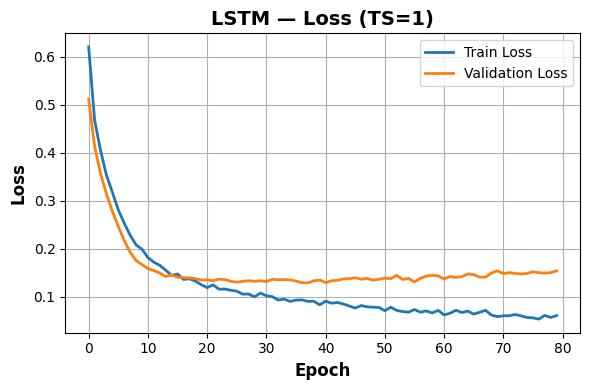

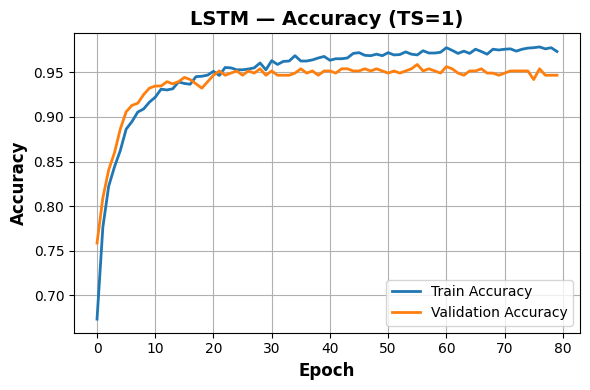

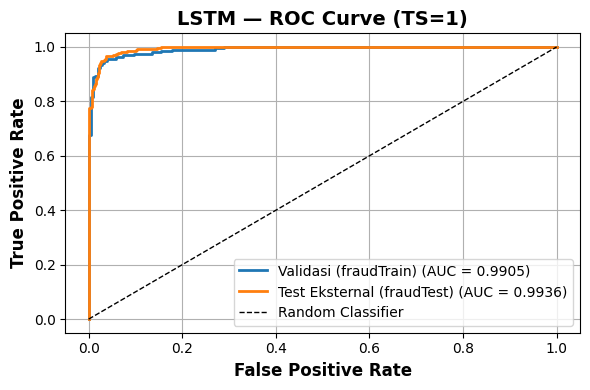


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.96      0.93      0.95       207
   Fraud (1)       0.93      0.97      0.95       207

    accuracy                           0.95       414
   macro avg       0.95      0.95      0.95       414
weighted avg       0.95      0.95      0.95       414


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.95      0.96       662
   Fraud (1)       0.95      0.97      0.96       662

    accuracy                           0.96      1324
   macro avg       0.96      0.96      0.96      1324
weighted avg       0.96      0.96      0.96      1324



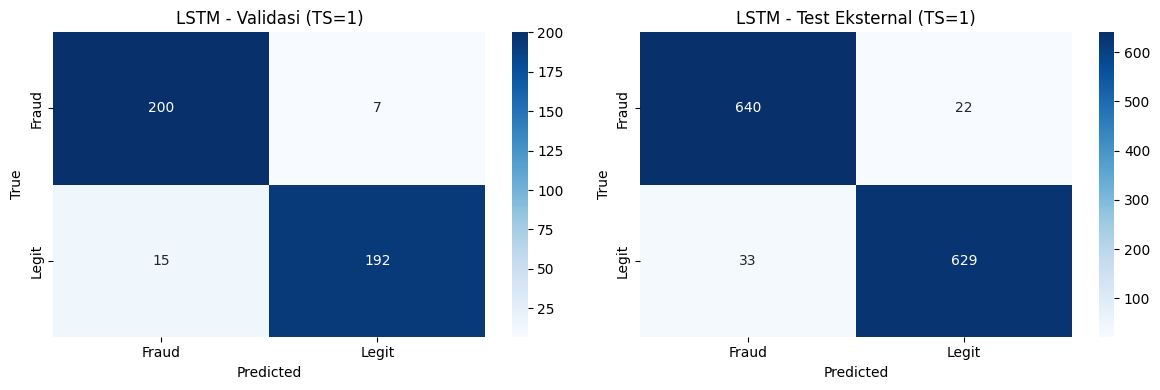


Melatih BiLSTM baseline (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 64)          │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,001 (156.25 KB)

 Trainable params: 40,001 (156.25 KB)

 Non-trainable params: 0 (0.00 B)

None

EVALUASI BiLSTM (TS=1)


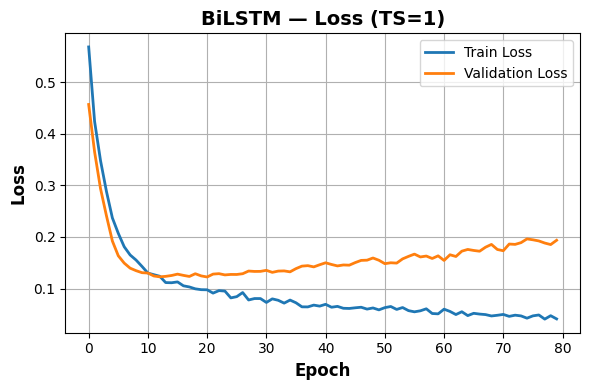

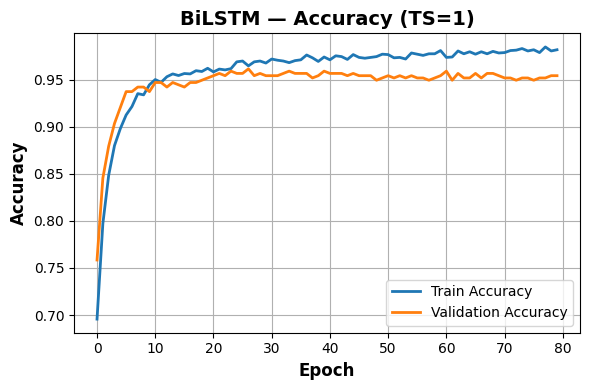

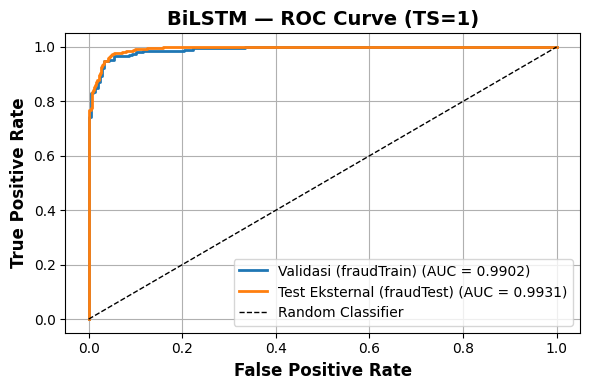


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.96      0.95      0.95       207
   Fraud (1)       0.95      0.96      0.95       207

    accuracy                           0.95       414
   macro avg       0.95      0.95      0.95       414
weighted avg       0.95      0.95      0.95       414


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.95      0.96       662
   Fraud (1)       0.95      0.97      0.96       662

    accuracy                           0.96      1324
   macro avg       0.96      0.96      0.96      1324
weighted avg       0.96      0.96      0.96      1324



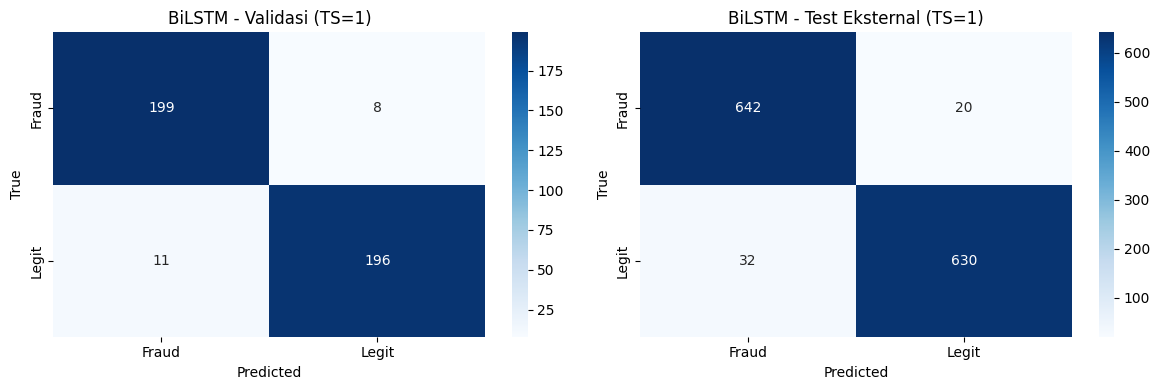


Melatih GRU baseline (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 32)          │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,129 (47.38 KB)

 Trainable params: 12,129 (47.38 KB)

 Non-trainable params: 0 (0.00 B)

None

EVALUASI GRU (TS=1)


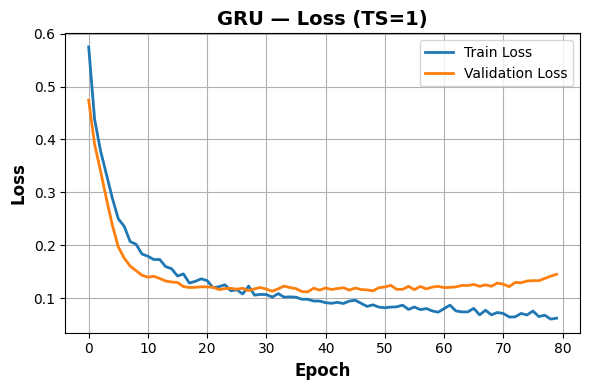

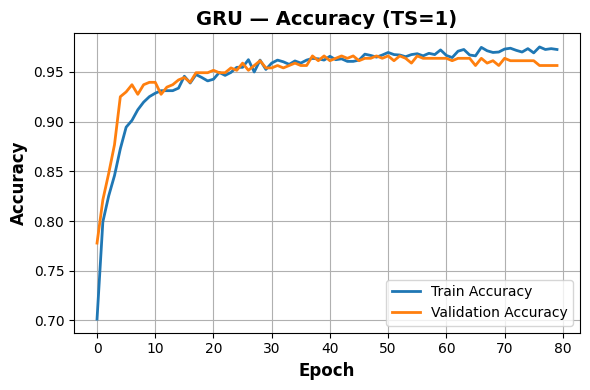

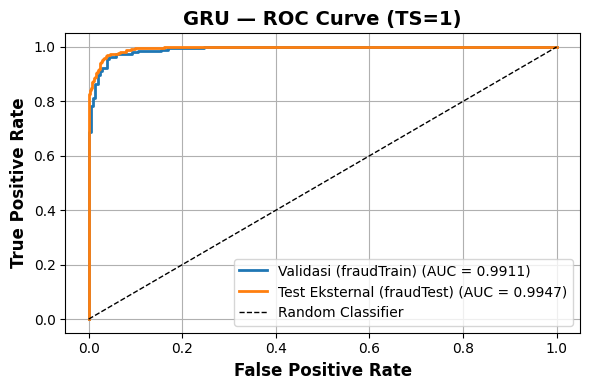


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.94      0.96       207
   Fraud (1)       0.94      0.97      0.96       207

    accuracy                           0.96       414
   macro avg       0.96      0.96      0.96       414
weighted avg       0.96      0.96      0.96       414


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.95      0.96       662
   Fraud (1)       0.95      0.97      0.96       662

    accuracy                           0.96      1324
   macro avg       0.96      0.96      0.96      1324
weighted avg       0.96      0.96      0.96      1324



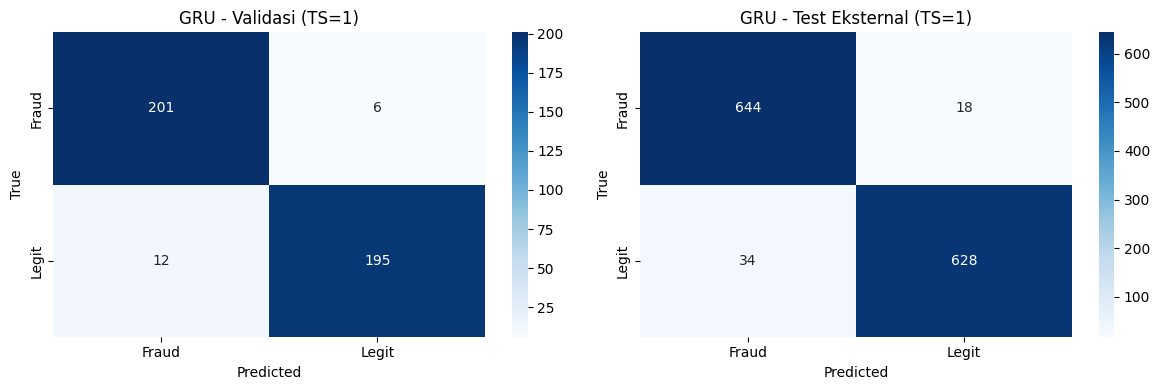


Melatih BiGRU baseline (2L-32U)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 1, 64)          │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

None

EVALUASI BiGRU (TS=1)


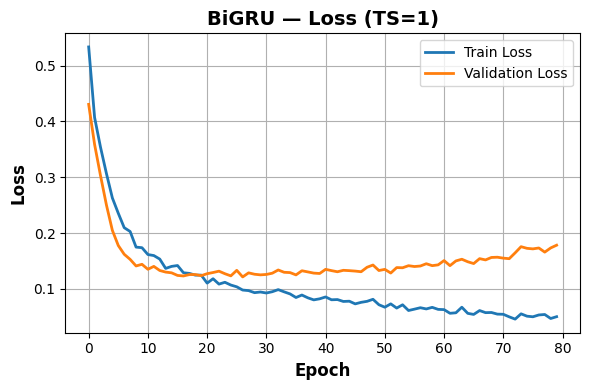

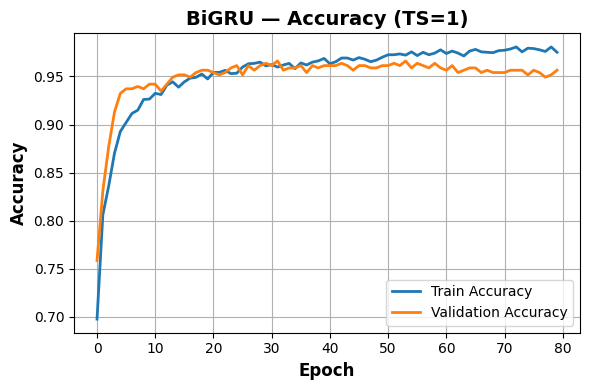

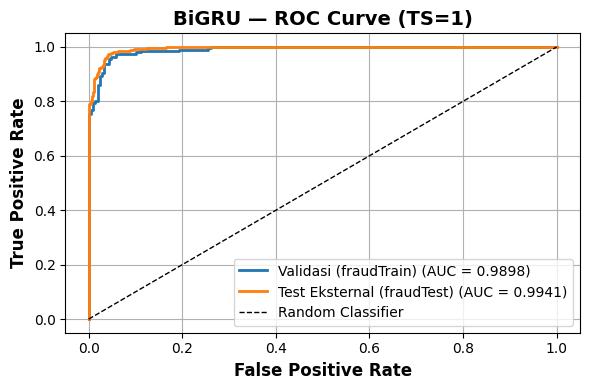


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.94      0.96       207
   Fraud (1)       0.94      0.97      0.96       207

    accuracy                           0.96       414
   macro avg       0.96      0.96      0.96       414
weighted avg       0.96      0.96      0.96       414


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.95      0.96       662
   Fraud (1)       0.96      0.97      0.96       662

    accuracy                           0.96      1324
   macro avg       0.96      0.96      0.96      1324
weighted avg       0.96      0.96      0.96      1324



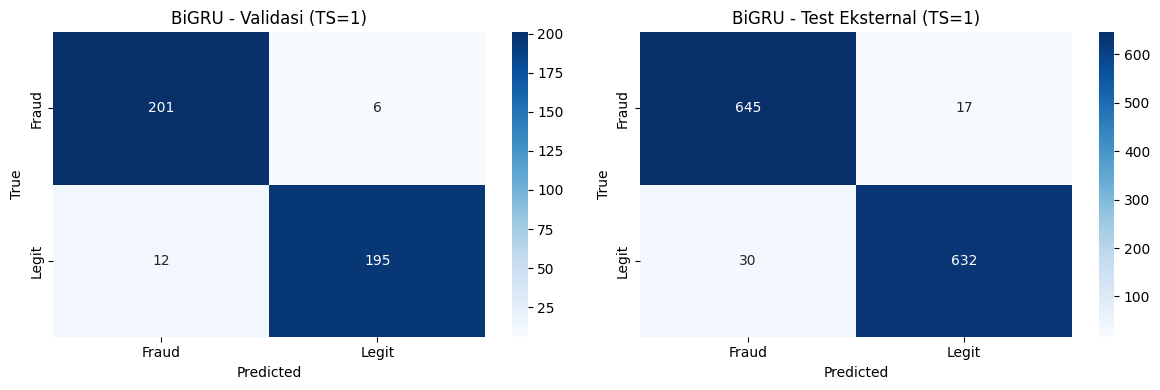

In [ ]:
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

baseline_models    = {}
baseline_histories = {}

for m_type in ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']:
    print(f"\nMelatih {m_type} baseline (2L-32U)...")
    model = build_baseline_model(m_type, INPUT_SHAPE)
    print(model.summary())
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                        epochs=80, batch_size=32, verbose=0)
    model.save(f"model_baseline_{m_type.lower()}.keras")
    baseline_models[m_type]    = model
    baseline_histories[m_type] = history
    evaluate_model(model, X_val, y_val, X_test_seq, y_test_seq,
                   m_type, CUSTOM_TIMESTEP, history=history)


# Bagian 5 : Pengujian Sequence Length

In [ ]:
sequence_lengths   = list(range(1, 15))
seq_experiment_res = []

for seq_len in sequence_lengths:
    print(f"\nSeq_Len = {seq_len}")
    X_tr_s, y_tr_s = generate_balanced_sequences(
        df_train_raw, seq_len, FEATURE_COLS, TARGET_COL, GROUP_COL)
    X_ts_s, y_ts_s = generate_balanced_sequences(
        df_test_raw,  seq_len, FEATURE_COLS, TARGET_COL, GROUP_COL)
    if len(X_tr_s) == 0 or len(X_ts_s) == 0:
        print("  Data tidak cukup, dilewati."); continue

    X_tr_s_, X_val_s_, y_tr_s_, y_val_s_ = train_test_split(
        X_tr_s, y_tr_s, test_size=0.15, stratify=y_tr_s, random_state=42)

    for m_type in ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']:
        model = build_baseline_model(m_type, (seq_len, len(FEATURE_COLS)))
        model.fit(X_tr_s_, y_tr_s_, validation_data=(X_val_s_, y_val_s_),
                  epochs=30, batch_size=32, verbose=0)
        y_pred = (model.predict(X_ts_s, verbose=0) > 0.5).astype(int).flatten()
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_ts_s, y_pred, labels=[1], average='macro')
        seq_experiment_res.append({'Model': m_type, 'Seq_Len': seq_len,
                                    'Precision': prec, 'Recall': rec, 'F1_Score': f1})
        print(f"  {m_type} -> F1: {f1:.4f} | Recall: {rec:.4f}")



Seq_Len = 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  LSTM -> F1: 0.9539 | Recall: 0.9683


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  BiLSTM -> F1: 0.9530 | Recall: 0.9653


...

  BiLSTM -> F1: 0.9556 | Recall: 0.9444


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  GRU -> F1: 0.9547 | Recall: 0.9427


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  BiGRU -> F1: 0.9685 | Recall: 0.9595


         Recall                         F1_Score                        
Model     BiGRU  BiLSTM     GRU    LSTM    BiGRU  BiLSTM     GRU    LSTM
Seq_Len                                                                 
1        0.9713  0.9653  0.9683  0.9683   0.9540  0.9530  0.9553  0.9539
2        0.9755  0.9801  0.9740  0.9755   0.9770  0.9727  0.9755  0.9748
3        0.9783  0.9675  0.9489  0.9675   0.9798  0.9735  0.9669  0.9667
4        0.9546  0.9452  0.9468  0.9562   0.9675  0.9656  0.9634  0.9599
5        0.9621  0.9747  0.9668  0.9526   0.9713  0.9755  0.9615  0.9625
6        0.9665  0.9362  0.9219  0.9330   0.9751  0.9623  0.9522  0.9567
7        0.9581  0.9646  0.9630  0.9404   0.9675  0.9724  0.9700  0.9613
8        0.9528  0.9431  0.9447  0.9236   0.9702  0.9635  0.9635  0.9459
9        0.9442  0.9524  0.9179  0.9031   0.9656  0.9659  0.9483  0.9410
10       0.9421  0.9405  0.9207  0.8926   0.9645  0.9579  0.9497  0.9247
11       0.9618  0.9435  0.9336  0.8771   0.9731  0

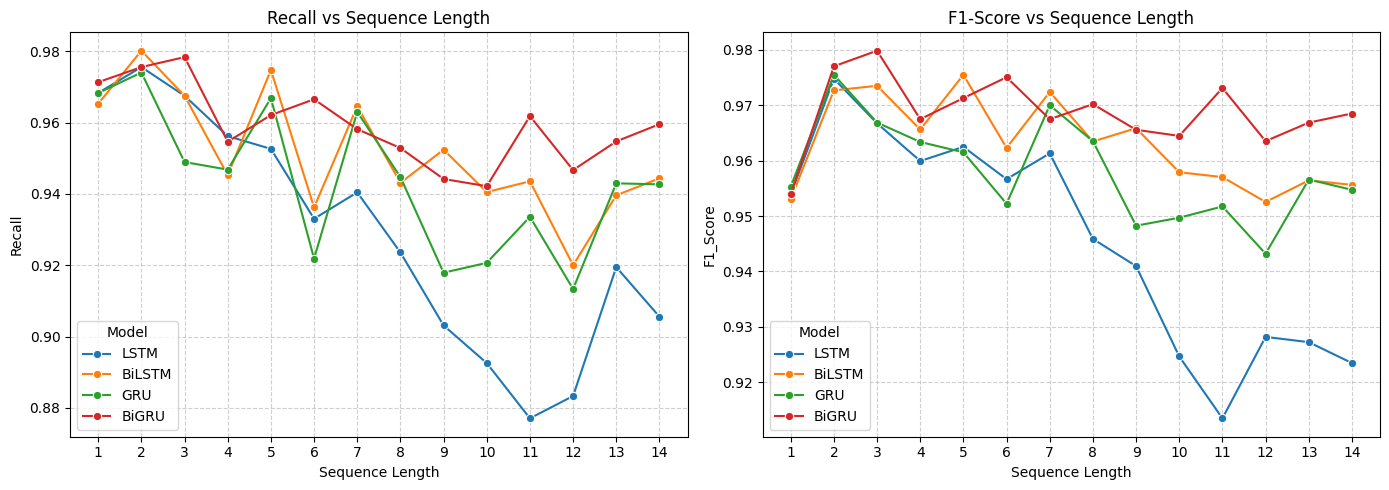

In [ ]:
df_seq = pd.DataFrame(seq_experiment_res)
print(df_seq.pivot(index='Seq_Len', columns='Model', values=['Recall','F1_Score']).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in zip(axes,
                               ['Recall','F1_Score'],
                               ['Recall vs Sequence Length','F1-Score vs Sequence Length']):
    sns.lineplot(data=df_seq, x='Seq_Len', y=metric, hue='Model', marker='o', ax=ax)
    ax.set_title(title); ax.set_xlabel('Sequence Length')
    ax.set_xticks(sequence_lengths); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


In [ ]:
df_seq

,Model,Seq_Len,Precision,Recall,F1_Score
0,LSTM,1,0.939883,0.968278,0.953869
1,BiLSTM,1,0.941090,0.965257,0.953020
2,GRU,1,0.942647,0.968278,0.955291
3,BiGRU,1,0.937318,0.971299,0.954006
4,LSTM,2,0.974046,0.975535,0.974790
5,BiLSTM,2,0.965361,0.980122,0.972686
6,GRU,2,0.976994,0.974006,0.975498
7,BiGRU,2,0.978528,0.975535,0.977029
8,LSTM,3,0.965997,0.967492,0.966744
9,BiLSTM,3,0.979624,0.967492,0.973520


# Bagian 6 : Melatih Model dengan Sequence Length Terbaik

> Set `CUSTOM_TIMESTEP` di Sel **3.2** ke nilai terbaik, lalu *re-run* Sel 3.2 terlebih dahulu.

In [ ]:
# -----------------------------------------------------------------------
# >>> SET SEQUENCE LENGTH TERBAIK DI SINI (setelah menjalankan Sec. 5) <<<
# -----------------------------------------------------------------------
CUSTOM_TIMESTEP = 2

TARGET_COL = 'is_fraud'
GROUP_COL  = 'cc_num'

# Load & feature engineering
df_train_raw = feature_engineering(CONFIG['train_file'], nrows=150000)
df_test_raw  = feature_engineering(CONFIG['test_file'],  nrows=150000)

# One-Hot Encoding
df_train_raw = pd.get_dummies(df_train_raw, drop_first=True)
df_test_raw  = pd.get_dummies(df_test_raw,  drop_first=True)

FEATURE_COLS = [c for c in df_train_raw.columns if c not in [TARGET_COL, GROUP_COL]]

# Selaraskan kolom test
for col in FEATURE_COLS:
    if col not in df_test_raw.columns:
        df_test_raw[col] = 0
df_test_raw = df_test_raw[[GROUP_COL, TARGET_COL] + FEATURE_COLS]

# Scaling (fit train only)
scaler = StandardScaler()
df_train_raw[FEATURE_COLS] = scaler.fit_transform(df_train_raw[FEATURE_COLS])
df_test_raw[FEATURE_COLS]  = scaler.transform(df_test_raw[FEATURE_COLS])

# Sekuens balanced 50:50
X_train_seq, y_train_seq = generate_balanced_sequences(
    df_train_raw, CUSTOM_TIMESTEP, FEATURE_COLS, TARGET_COL, GROUP_COL)
X_test_seq,  y_test_seq  = generate_balanced_sequences(
    df_test_raw,  CUSTOM_TIMESTEP, FEATURE_COLS, TARGET_COL, GROUP_COL)

if len(X_train_seq) == 0 or len(X_test_seq) == 0:
    raise ValueError(f"Data tidak cukup untuk seq_len={CUSTOM_TIMESTEP}.")

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, y_train_seq, test_size=0.15, stratify=y_train_seq, random_state=42)

INPUT_SHAPE = (CUSTOM_TIMESTEP, len(FEATURE_COLS))

print(f"Sequence Length  : {CUSTOM_TIMESTEP}")
print(f"Jumlah Fitur     : {len(FEATURE_COLS)}")
print(f"X_tr shape       : {X_tr.shape}")
print(f"X_val shape      : {X_val.shape}")
print(f"X_test shape     : {X_test_seq.shape}")
print(f"Train Fraud/Legit: {sum(y_tr==1)} / {sum(y_tr==0)}")
print(f"Test  Fraud/Legit: {sum(y_test_seq==1)} / {sum(y_test_seq==0)}")


Sequence Length  : 2
Jumlah Fitur     : 26
X_tr shape       : (2306, 2, 26)
X_val shape      : (408, 2, 26)
X_test shape     : (1308, 2, 26)
Train Fraud/Legit: 1153 / 1153
Test  Fraud/Legit: 654 / 654



Melatih LSTM (TS=2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



EVALUASI LSTM (TS=2) (TS=2)


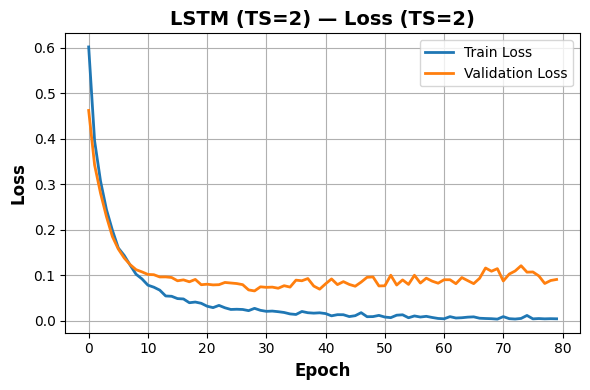

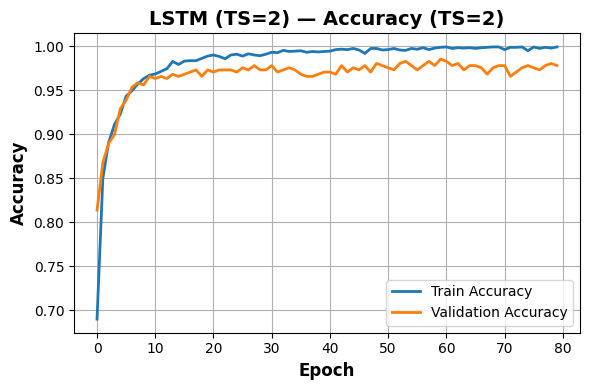

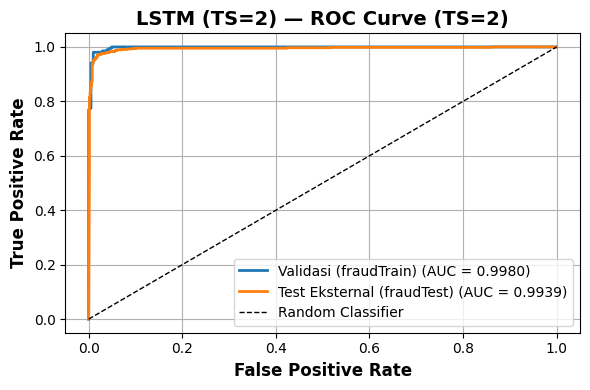


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.97      0.98       204
   Fraud (1)       0.97      0.99      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



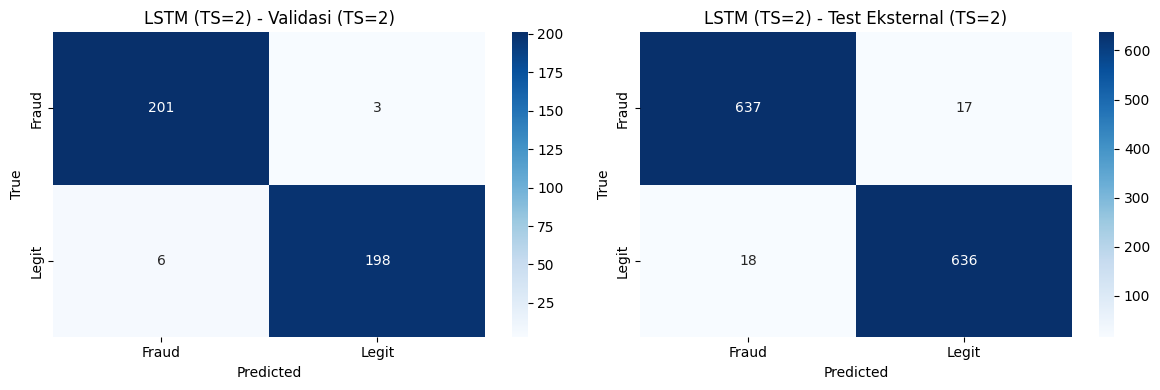


Melatih BiLSTM (TS=2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



EVALUASI BiLSTM (TS=2) (TS=2)


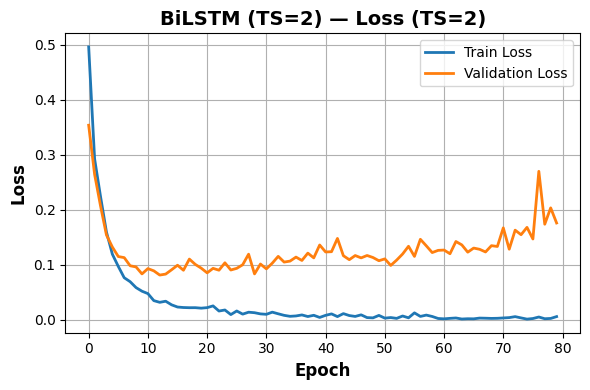

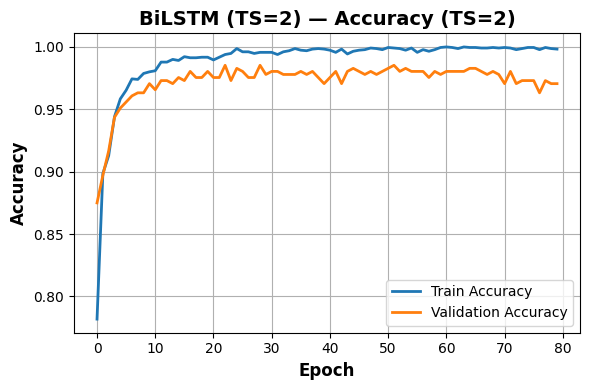

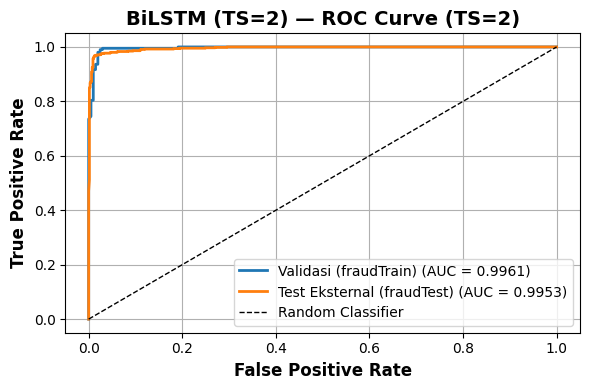


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.95      0.97       204
   Fraud (1)       0.95      1.00      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.96      0.97       654
   Fraud (1)       0.97      0.98      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



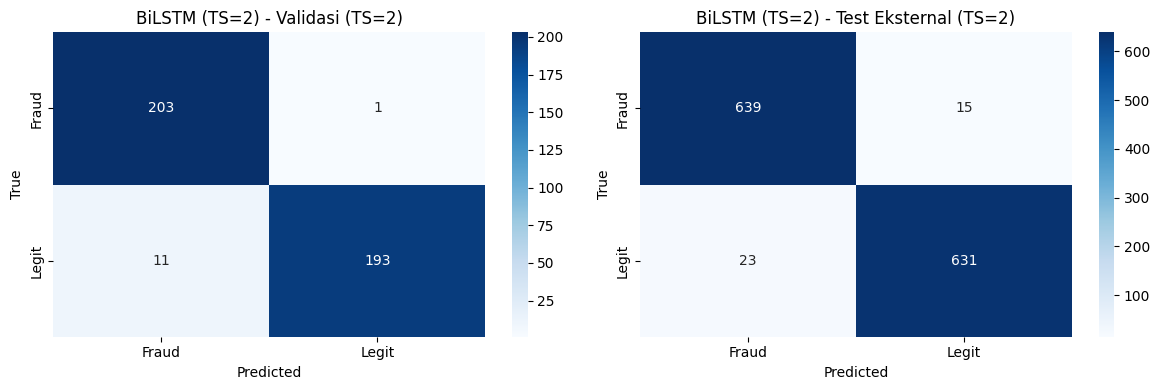


Melatih GRU (TS=2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



EVALUASI GRU (TS=2) (TS=2)


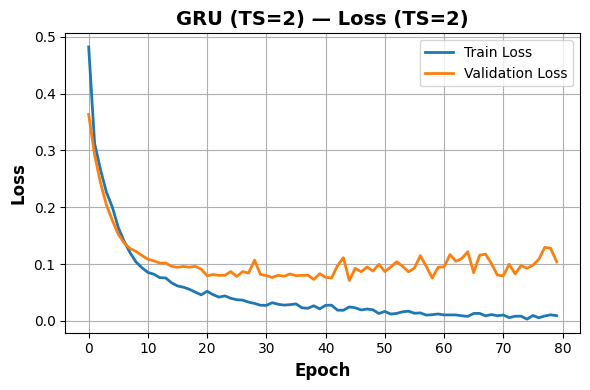

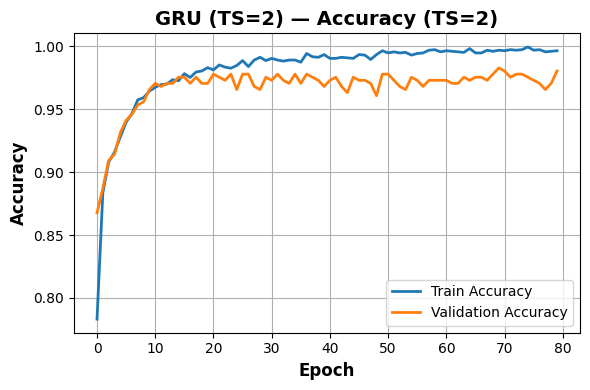

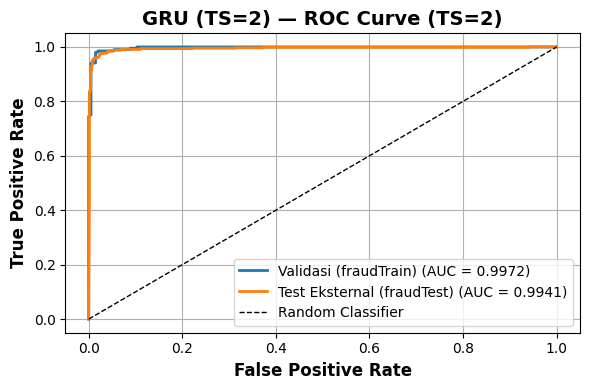


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.98      0.98       204
   Fraud (1)       0.98      0.99      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.98      0.97       654
   Fraud (1)       0.98      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



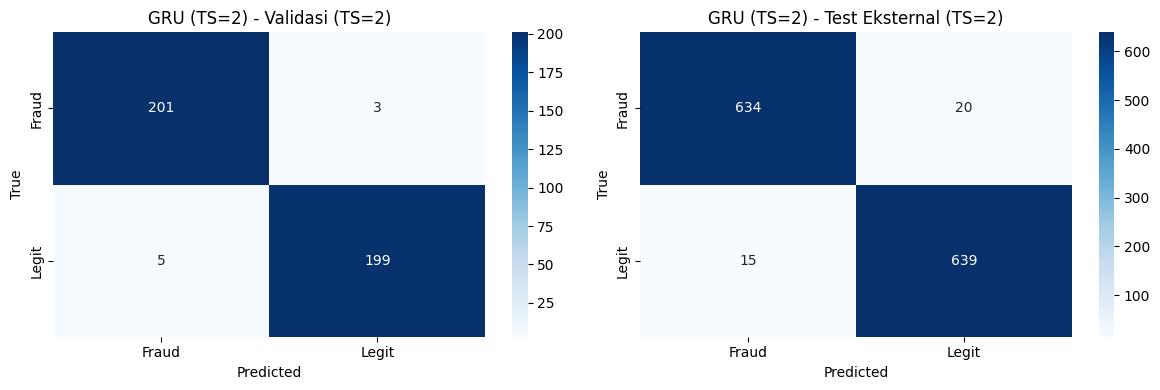


Melatih BiGRU (TS=2)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



EVALUASI BiGRU (TS=2) (TS=2)


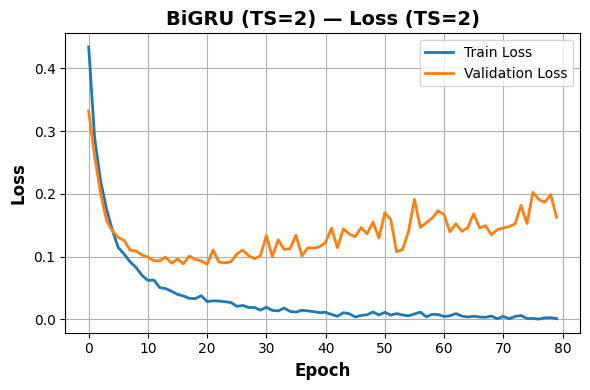

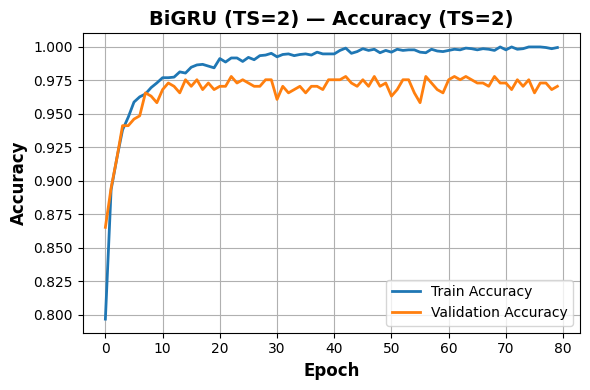

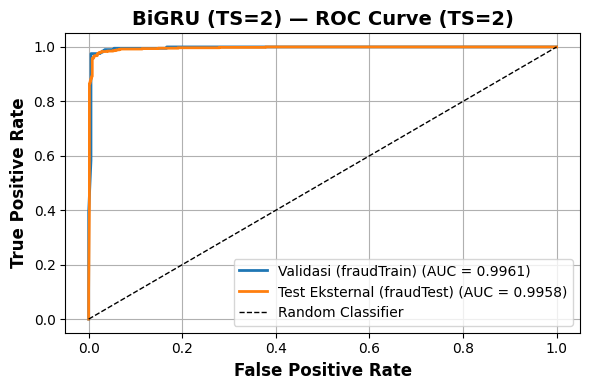


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.95      0.97       204
   Fraud (1)       0.95      0.99      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.98       654
   Fraud (1)       0.97      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



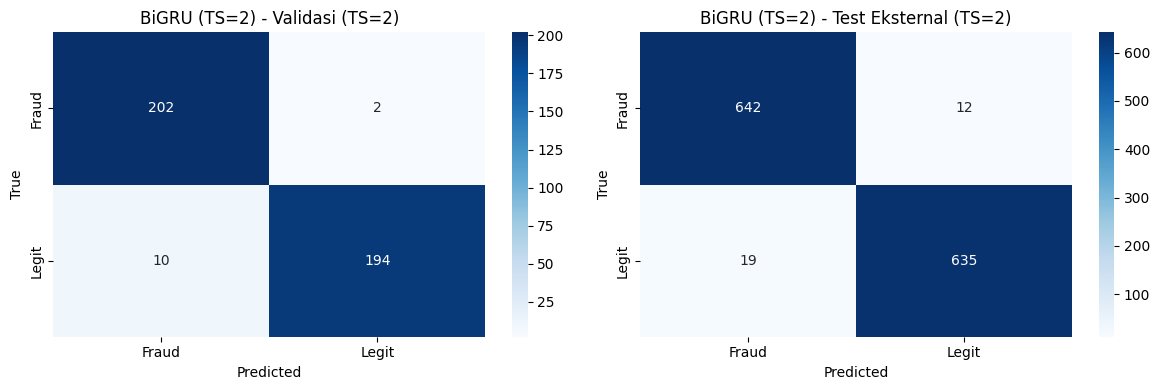

In [ ]:
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

best_models    = {}
best_histories = {}

for m_type in ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']:
    print(f"\nMelatih {m_type} (TS={CUSTOM_TIMESTEP})...")
    model = build_baseline_model(m_type, INPUT_SHAPE)
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                        epochs=80, batch_size=32, verbose=0)
    model.save(f"model_ts{CUSTOM_TIMESTEP}_{m_type.lower()}.keras")
    best_models[m_type]    = model
    best_histories[m_type] = history
    evaluate_model(model, X_val, y_val, X_test_seq, y_test_seq,
                   f"{m_type} (TS={CUSTOM_TIMESTEP})", CUSTOM_TIMESTEP, history=history)


# Bagian 7 : Hyperparameter Tuning (Grid Search)



## 7.1 Fungsi Builder Dinamis

In [ ]:
def _make_sequential_rnn(rnn_layer_fn, num_layers, num_units, input_shape):
    model = Sequential()
    for i in range(num_layers):
        is_last = (i == num_layers - 1)
        kw = dict(return_sequences=not is_last)
        if i == 0:
            kw['input_shape'] = input_shape
        model.add(rnn_layer_fn(num_units, **kw))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001, weight_decay=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_tuned_lstm(nl, nu, s):
    return _make_sequential_rnn(LSTM, nl, nu, s)

def build_tuned_bilstm(nl, nu, s):
    model = Sequential()
    for i in range(nl):
        is_last = (i == nl - 1)
        kw = dict(return_sequences=not is_last)
        if i == 0:
            model.add(Bidirectional(LSTM(nu, **kw), input_shape=s))
        else:
            model.add(Bidirectional(LSTM(nu, **kw)))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001, weight_decay=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_tuned_gru(nl, nu, s):
    return _make_sequential_rnn(GRU, nl, nu, s)

def build_tuned_bigru(nl, nu, s):
    model = Sequential()
    for i in range(nl):
        is_last = (i == nl - 1)
        kw = dict(return_sequences=not is_last)
        if i == 0:
            model.add(Bidirectional(GRU(nu, **kw), input_shape=s))
        else:
            model.add(Bidirectional(GRU(nu, **kw)))
        model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001, weight_decay=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


def run_grid_search(builder_fn, arch_name, input_shape,
                    X_tr, y_tr, X_val, y_val, X_test, y_test):
    grid = list(itertools.product([1,2,3,4], [1,2,4,8,16,32,64]))
    # early = EarlyStopping(monitor='val_accuracy', patience=75, restore_best_weights=True)
    results = []
    best_f1, best_cfg, best_mdl = -1.0, None, None

    print(f"{'='*66}")
    print(f"GRID SEARCH {arch_name} ({len(grid)} kombinasi)")
    print(f"{'='*66}")

    for idx, (nl, nu) in enumerate(grid, 1):
        print(f"[{idx}/{len(grid)}] L:{nl} U:{nu} ...", end=" ")
        m = builder_fn(nl, nu, input_shape)
        m.fit(X_tr, y_tr, validation_data=(X_val, y_val),
              epochs=80, batch_size=32, verbose=0)
        y_pred = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='binary', pos_label=1)
        print(f"| F1:{f1:.4f} Rec:{rec:.4f} Prec:{prec:.4f}")
        results.append({'Layers':nl,'Units':nu,'Test_F1':f1,'Test_Recall':rec,'Test_Precision':prec})
        if f1 > best_f1:
            best_f1, best_cfg, best_mdl = f1, (nl,nu), m

    print(f"\nTerbaik {arch_name}: {best_cfg[0]}L x {best_cfg[1]}U (F1={best_f1:.4f})")
    best_mdl.save(f"model_{arch_name.lower()}_optimal_L{best_cfg[0]}_U{best_cfg[1]}.keras")

    df_t = pd.DataFrame(results)
    for col, cmap, lbl in [('Test_F1','Blues','F1'),('Test_Precision','Greens','Precision'),('Test_Recall','Oranges','Recall')]:
        plt.figure(figsize=(10,5))
        sns.heatmap(df_t.pivot(index='Layers',columns='Units',values=col),
                    annot=True, fmt='.4f', cmap=cmap,
                    cbar_kws={'label': f'fraudTest {lbl}'})
        plt.title(f"Grid Search {arch_name} — {lbl}", fontsize=14, fontweight='bold'); plt.tight_layout(); plt.show()

    print("\nTop 10 konfigurasi:")
    print(df_t.sort_values(['Test_F1','Test_Recall'],ascending=False).head(10).to_string(index=False))
    return df_t, best_cfg, best_mdl


## 7.2 Tuning LSTM

GRID SEARCH LSTM (28 kombinasi)
[1/28] L:1 U:1 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.8920 Rec:0.9220 Prec:0.8639
[2/28] L:1 U:2 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9390 Rec:0.9067 Prec:0.9737
[3/28] L:1 U:4 ... 

...

| F1:0.9763 Rec:0.9771 Prec:0.9756
[27/28] L:4 U:32 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9748 Rec:0.9755 Prec:0.9740
[28/28] L:4 U:64 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9702 Rec:0.9694 Prec:0.9709

Terbaik LSTM: 1L x 8U (F1=0.9809)


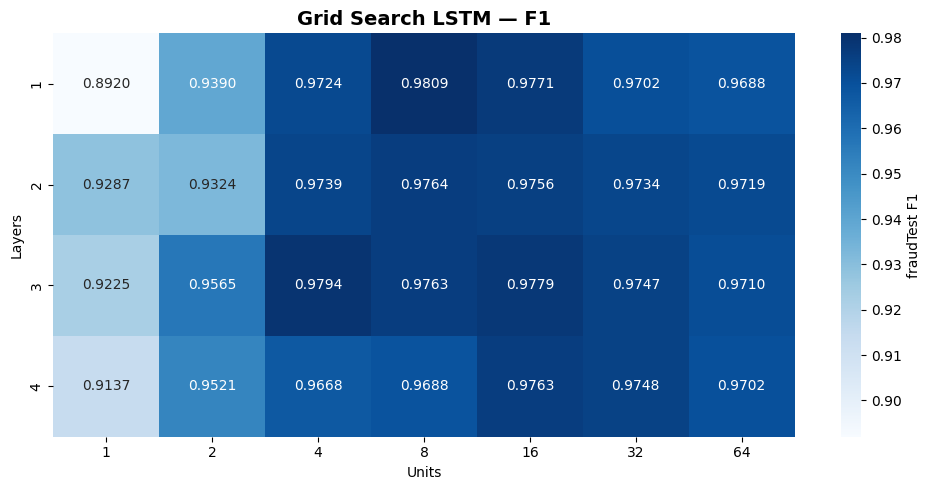

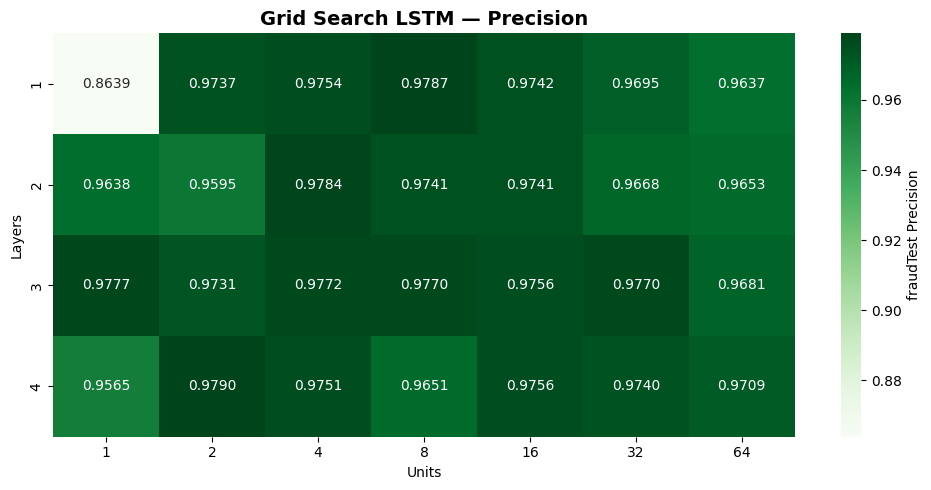

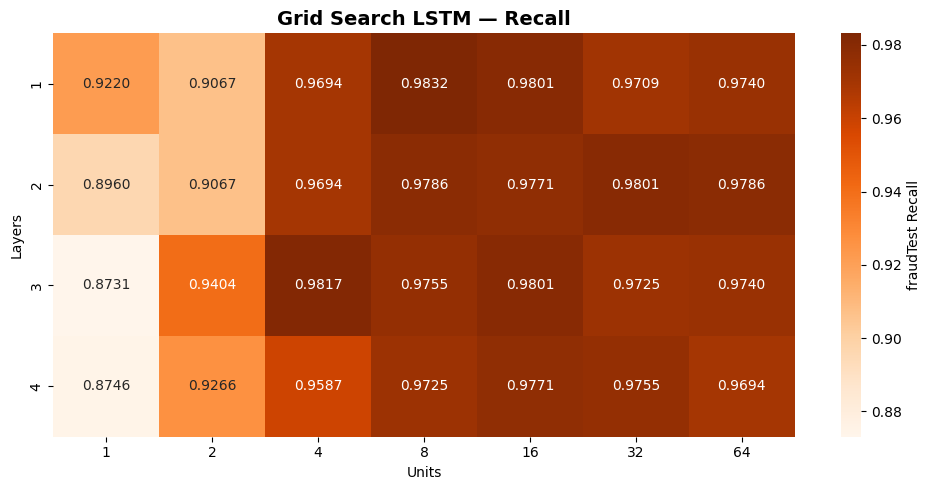


Top 10 konfigurasi:
 Layers  Units  Test_F1  Test_Recall  Test_Precision
      1      8 0.980931     0.983180        0.978691
      3      4 0.979405     0.981651        0.977169
      3     16 0.977879     0.980122        0.975647
      1     16 0.977134     0.980122        0.974164
      2      8 0.976354     0.978593        0.974125
      4     16 0.976318     0.977064        0.975573
      3      8 0.976282     0.975535        0.977029
      2     16 0.975573     0.977064        0.974085
      4     32 0.974790     0.975535        0.974046
      3     32 0.974713     0.972477        0.976959


In [ ]:
df_tuning_lstm, best_lstm_cfg, best_lstm_mdl = run_grid_search(
    build_tuned_lstm, 'LSTM', INPUT_SHAPE, X_tr, y_tr, X_val, y_val, X_test_seq, y_test_seq)


## 7.3 Tuning BiLSTM

GRID SEARCH BiLSTM (28 kombinasi)
[1/28] L:1 U:1 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9549 Rec:0.9557 Prec:0.9542
[2/28] L:1 U:2 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9622 Rec:0.9541 Prec:0.9705
[3/28] L:1 U:4 ... 

...

| F1:0.9770 Rec:0.9740 Prec:0.9800
[27/28] L:4 U:32 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9749 Rec:0.9801 Prec:0.9697
[28/28] L:4 U:64 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9679 Rec:0.9694 Prec:0.9665

Terbaik BiLSTM: 4L x 8U (F1=0.9787)


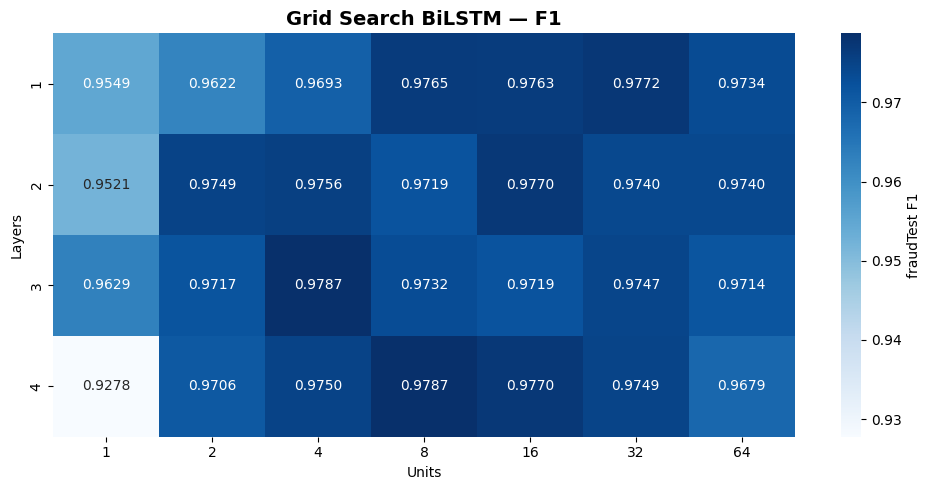

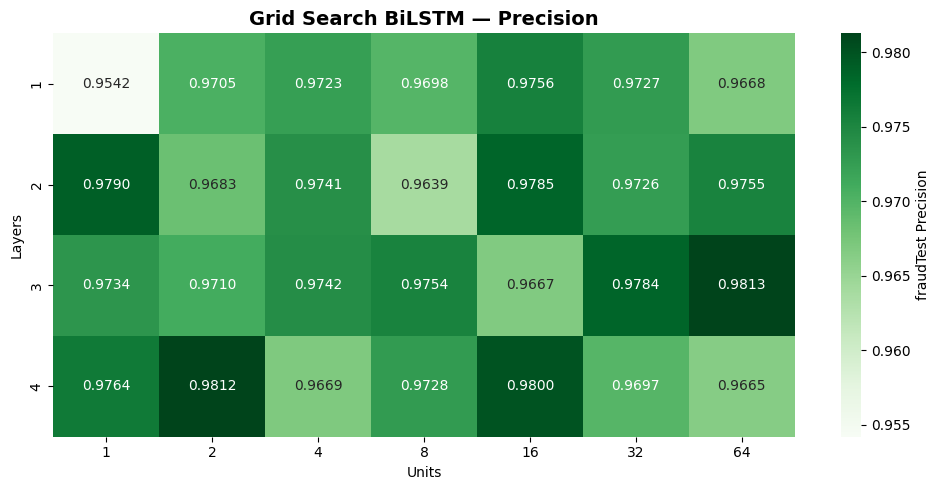

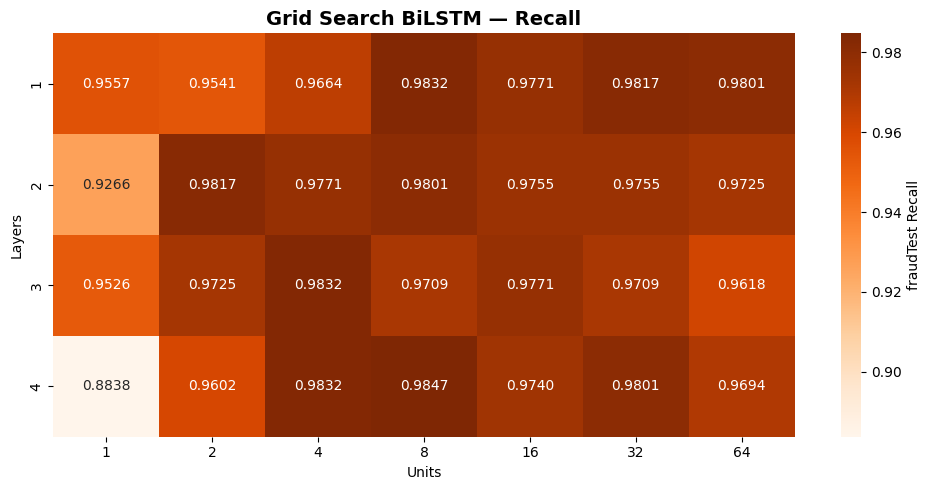


Top 10 konfigurasi:
 Layers  Units  Test_F1  Test_Recall  Test_Precision
      4      8 0.978723     0.984709        0.972810
      3      4 0.978691     0.983180        0.974242
      1     32 0.977169     0.981651        0.972727
      2     16 0.977029     0.975535        0.978528
      4     16 0.976994     0.974006        0.980000
      1      8 0.976462     0.983180        0.969834
      1     16 0.976318     0.977064        0.975573
      2      4 0.975573     0.977064        0.974085
      4      4 0.974981     0.983180        0.966917
      2      2 0.974943     0.981651        0.968326


In [ ]:
df_tuning_bilstm, best_bilstm_cfg, best_bilstm_mdl = run_grid_search(
    build_tuned_bilstm, 'BiLSTM', INPUT_SHAPE, X_tr, y_tr, X_val, y_val, X_test_seq, y_test_seq)


## 7.4 Tuning GRU

GRID SEARCH GRU (28 kombinasi)
[1/28] L:1 U:1 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9206 Rec:0.8869 Prec:0.9571
[2/28] L:1 U:2 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9436 Rec:0.9083 Prec:0.9818
[3/28] L:1 U:4 ... 

...

| F1:0.9786 Rec:0.9786 Prec:0.9786
[27/28] L:4 U:32 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9779 Rec:0.9817 Prec:0.9742
[28/28] L:4 U:64 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9708 Rec:0.9648 Prec:0.9768

Terbaik GRU: 4L x 8U (F1=0.9808)


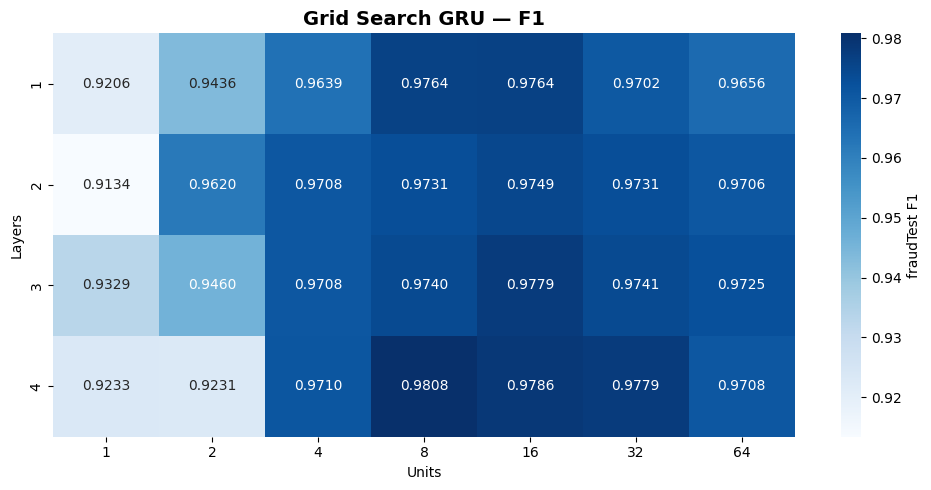

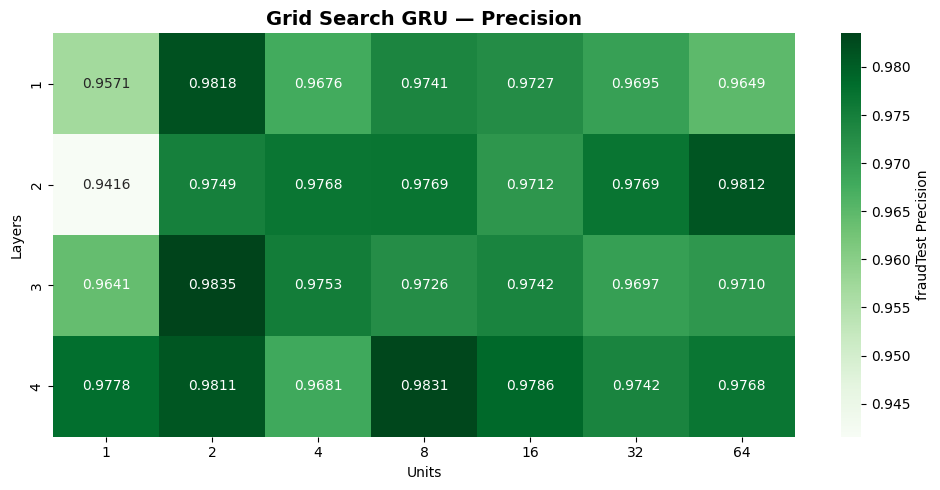

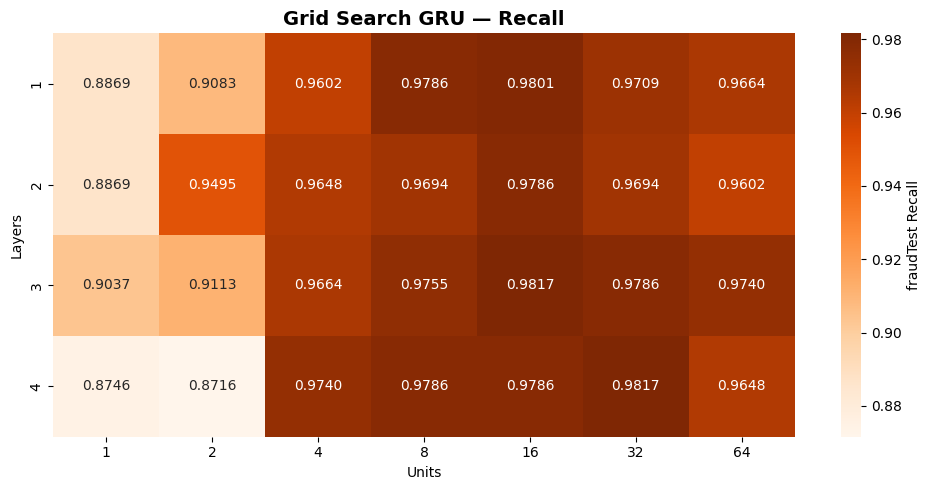


Top 10 konfigurasi:
 Layers  Units  Test_F1  Test_Recall  Test_Precision
      4      8 0.980843     0.978593        0.983103
      4     16 0.978593     0.978593        0.978593
      3     16 0.977913     0.981651        0.974203
      4     32 0.977913     0.981651        0.974203
      1     16 0.976390     0.980122        0.972686
      1      8 0.976354     0.978593        0.974125
      2     16 0.974867     0.978593        0.971168
      3     32 0.974125     0.978593        0.969697
      3      8 0.974046     0.975535        0.972561
      2      8 0.973139     0.969419        0.976888


In [ ]:
df_tuning_gru, best_gru_cfg, best_gru_mdl = run_grid_search(
    build_tuned_gru, 'GRU', INPUT_SHAPE, X_tr, y_tr, X_val, y_val, X_test_seq, y_test_seq)


## 7.5 Tuning BiGRU

GRID SEARCH BiGRU (28 kombinasi)
[1/28] L:1 U:1 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9248 Rec:0.8746 Prec:0.9811
[2/28] L:1 U:2 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9529 Rec:0.9281 Prec:0.9790
[3/28] L:1 U:4 ... 

...

| F1:0.9810 Rec:0.9847 Prec:0.9772
[27/28] L:4 U:32 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9705 Rec:0.9801 Prec:0.9610
[28/28] L:4 U:64 ... 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


| F1:0.9689 Rec:0.9771 Prec:0.9609

Terbaik BiGRU: 1L x 32U (F1=0.9855)


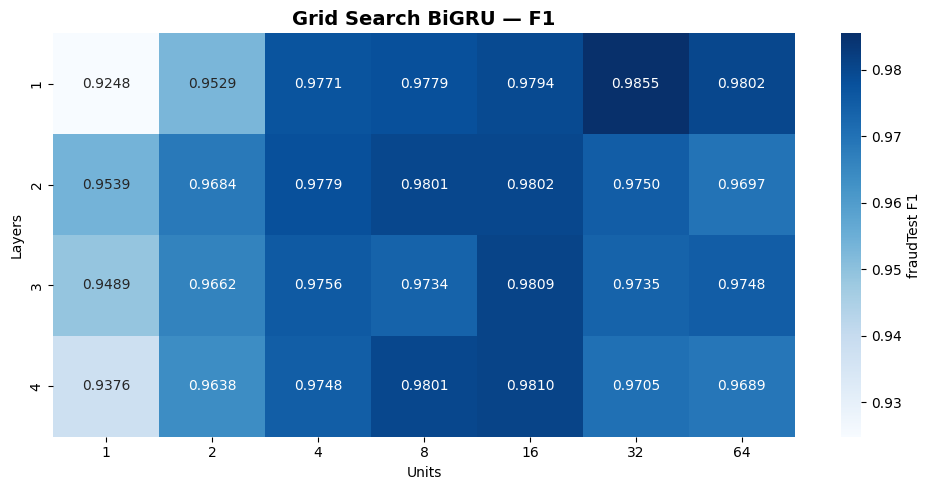

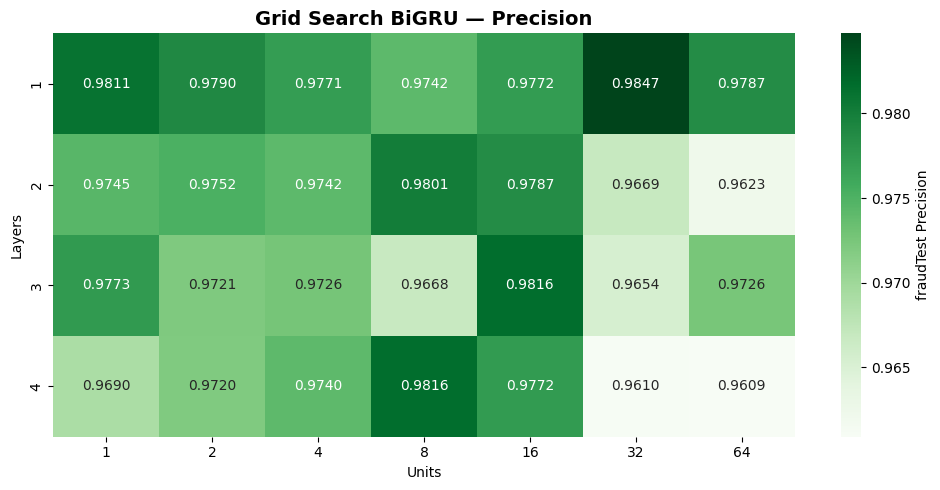

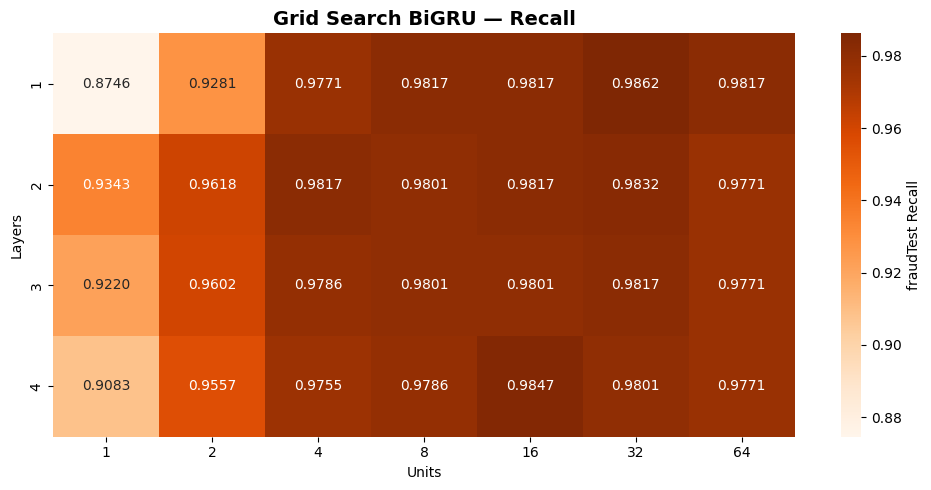


Top 10 konfigurasi:
 Layers  Units  Test_F1  Test_Recall  Test_Precision
      1     32 0.985485     0.986239        0.984733
      4     16 0.980960     0.984709        0.977238
      3     16 0.980872     0.980122        0.981623
      1     64 0.980153     0.981651        0.978659
      2     16 0.980153     0.981651        0.978659
      2      8 0.980122     0.980122        0.980122
      4      8 0.980092     0.978593        0.981595
      1     16 0.979405     0.981651        0.977169
      1      8 0.977913     0.981651        0.974203
      2      4 0.977913     0.981651        0.974203


In [ ]:
df_tuning_bigru, best_bigru_cfg, best_bigru_mdl = run_grid_search(
    build_tuned_bigru, 'BiGRU', INPUT_SHAPE, X_tr, y_tr, X_val, y_val, X_test_seq, y_test_seq)


# Bagian 8 : Rekap 8 Model Terbaik (Tanpa Attention)



Melatih LSTM_2L32U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 32)          │         7,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905 (62.13 KB)

 Trainable params: 15,905 (62.13 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI LSTM_2L32U (TS=2)


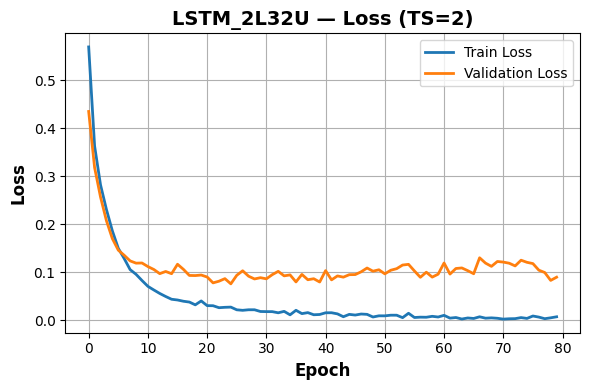

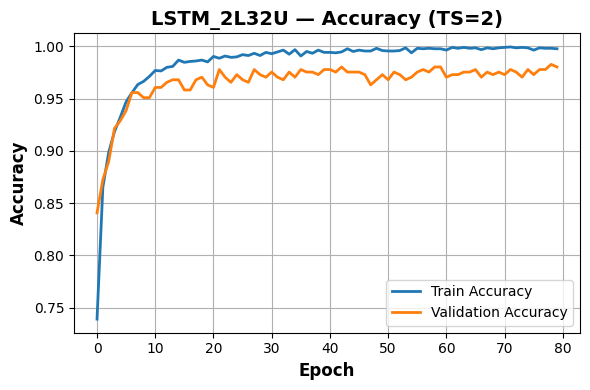

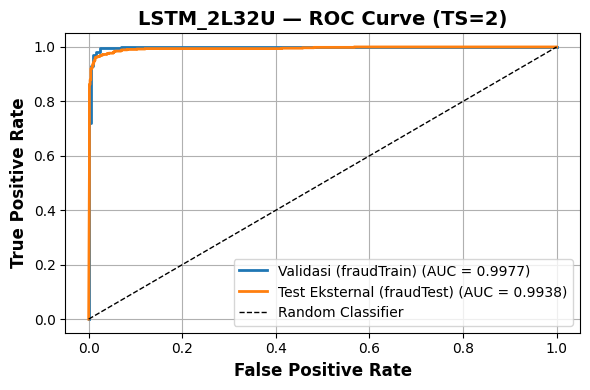


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.97      0.98       204
   Fraud (1)       0.97      1.00      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



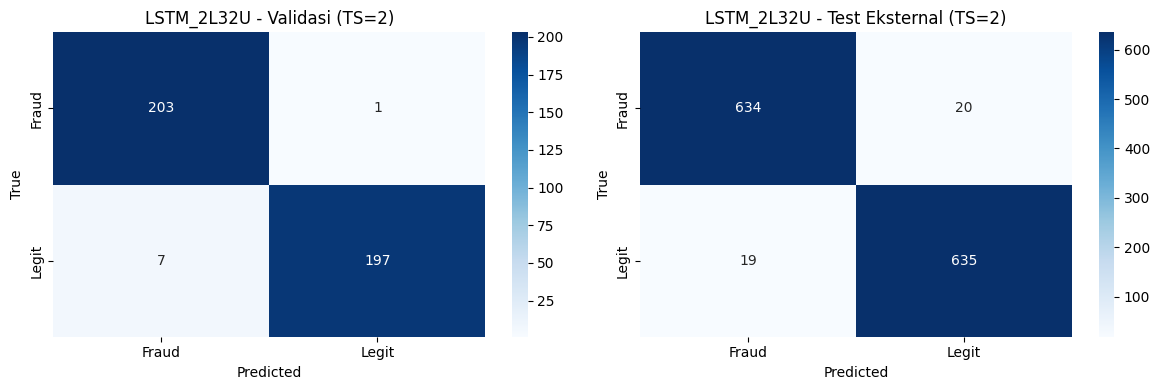

  F1:0.9702 | Recall:0.9694 | Params:15,905

Melatih LSTM_1L8U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 8)              │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,129 (4.41 KB)

 Trainable params: 1,129 (4.41 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI LSTM_1L8U (TS=2)


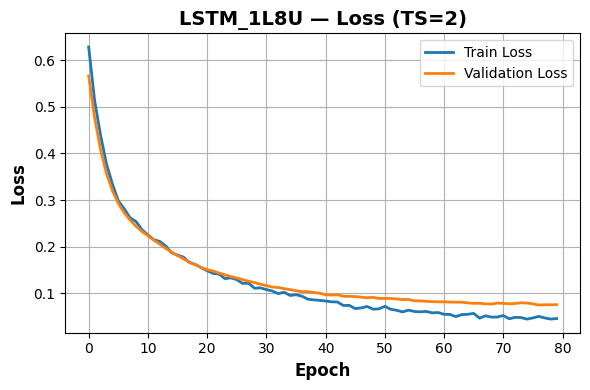

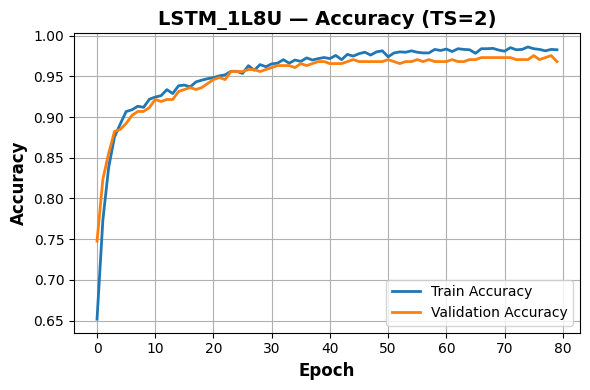

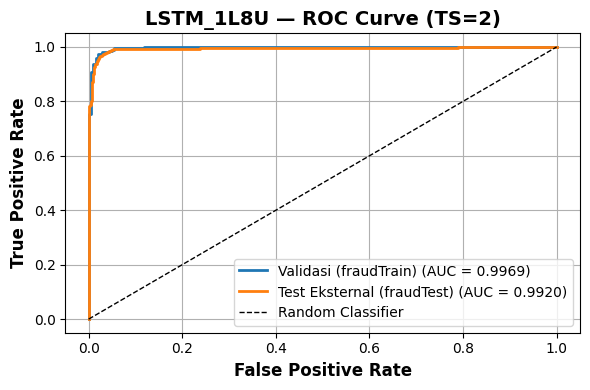


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.96      0.97       204
   Fraud (1)       0.96      0.98      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.97       654
   Fraud (1)       0.97      0.98      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



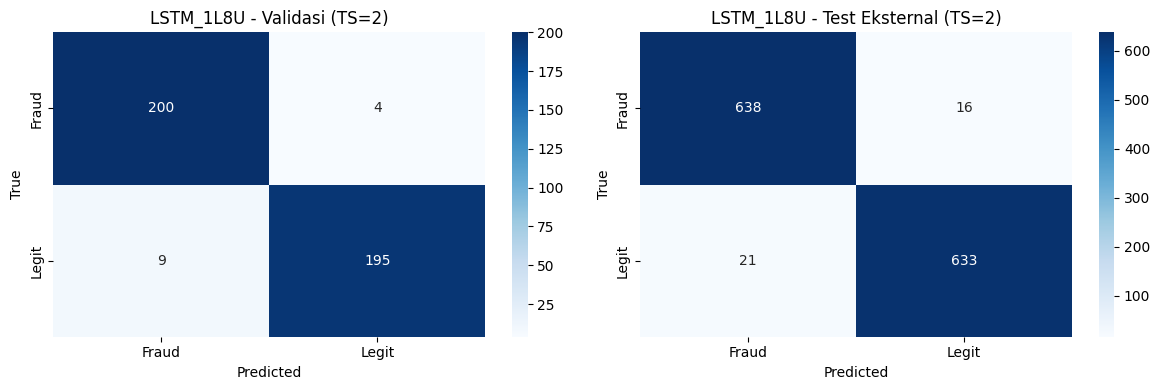

  F1:0.9718 | Recall:0.9755 | Params:1,129

Melatih BiLSTM_2L32U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 2, 64)          │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,001 (156.25 KB)

 Trainable params: 40,001 (156.25 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiLSTM_2L32U (TS=2)


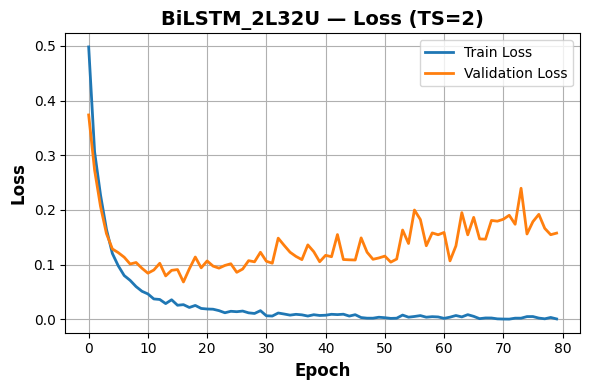

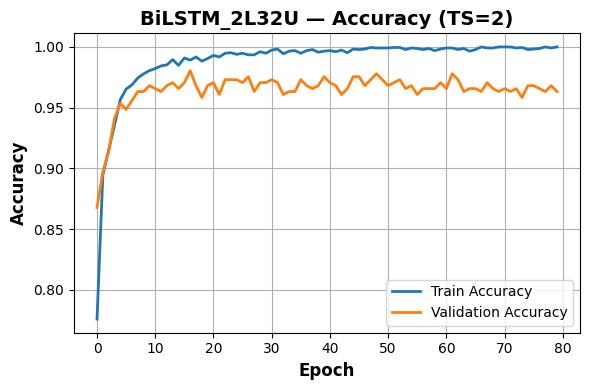

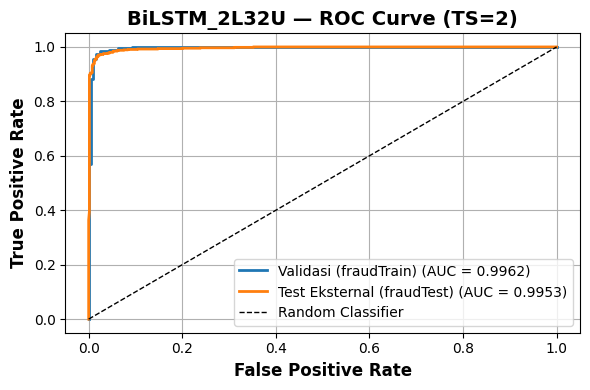


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.94      0.96       204
   Fraud (1)       0.94      0.99      0.96       204

    accuracy                           0.96       408
   macro avg       0.96      0.96      0.96       408
weighted avg       0.96      0.96      0.96       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



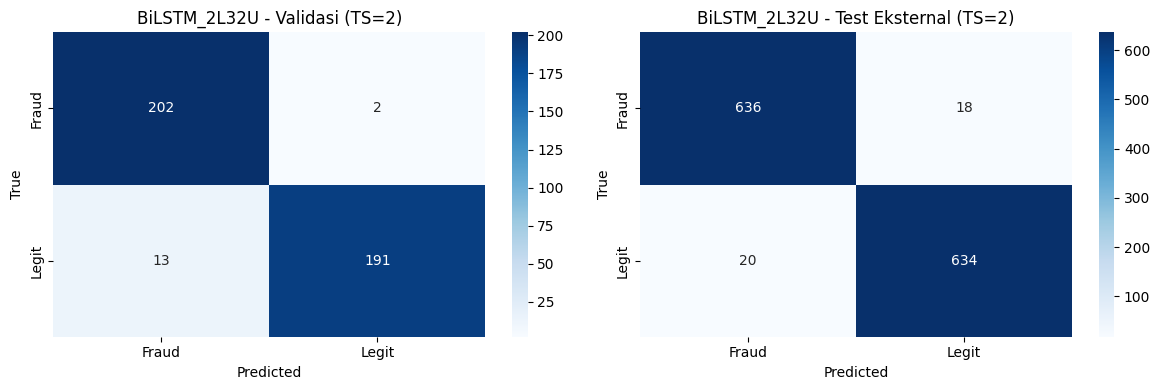

  F1:0.9710 | Recall:0.9725 | Params:40,001

Melatih BiLSTM_4L8U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 2, 16)          │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 2, 16)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 2, 16)          │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 16)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,057 (27.57 KB)

 Trainable params: 7,057 (27.57 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiLSTM_4L8U (TS=2)


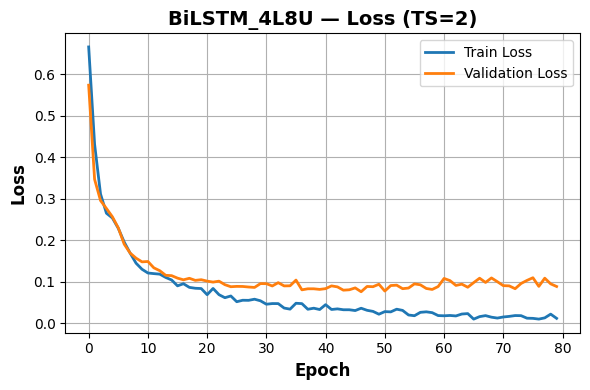

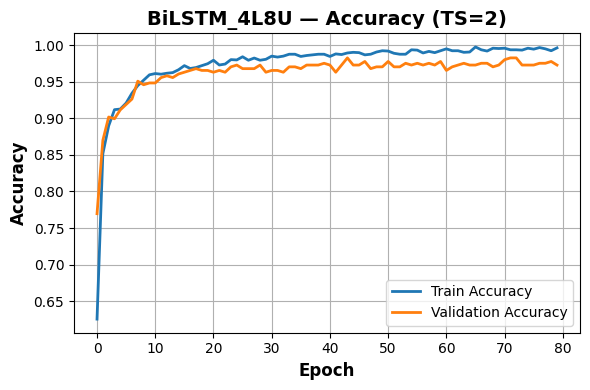

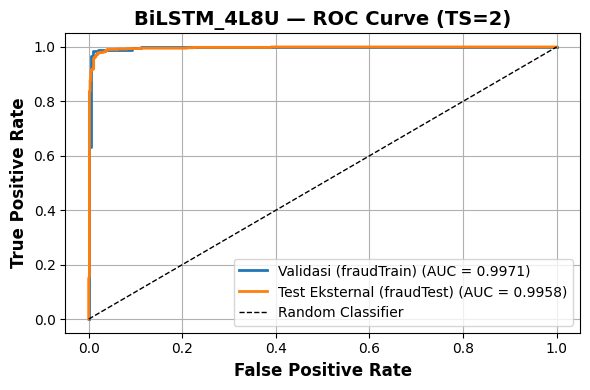


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.96      0.97       204
   Fraud (1)       0.96      0.99      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.98       654
   Fraud (1)       0.97      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



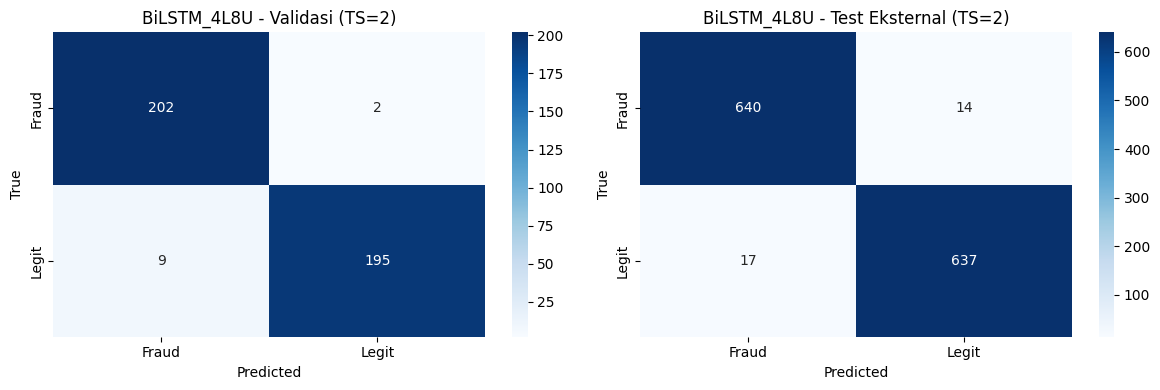

  F1:0.9764 | Recall:0.9786 | Params:7,057

Melatih GRU_2L32U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2, 32)          │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,129 (47.38 KB)

 Trainable params: 12,129 (47.38 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI GRU_2L32U (TS=2)


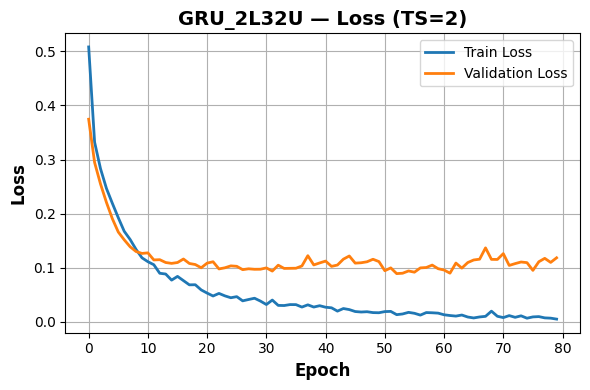

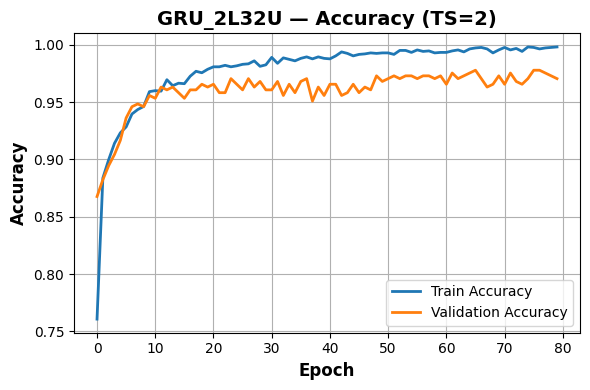

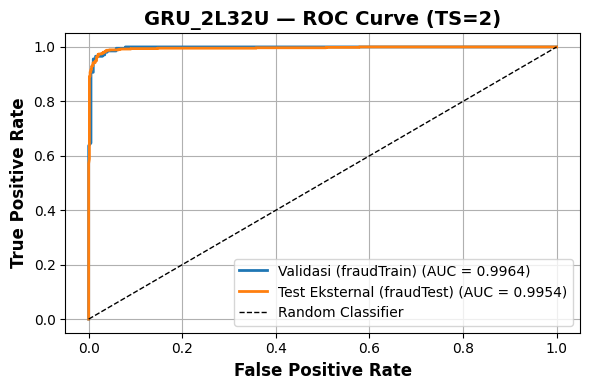


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.96      0.97       204
   Fraud (1)       0.96      0.98      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



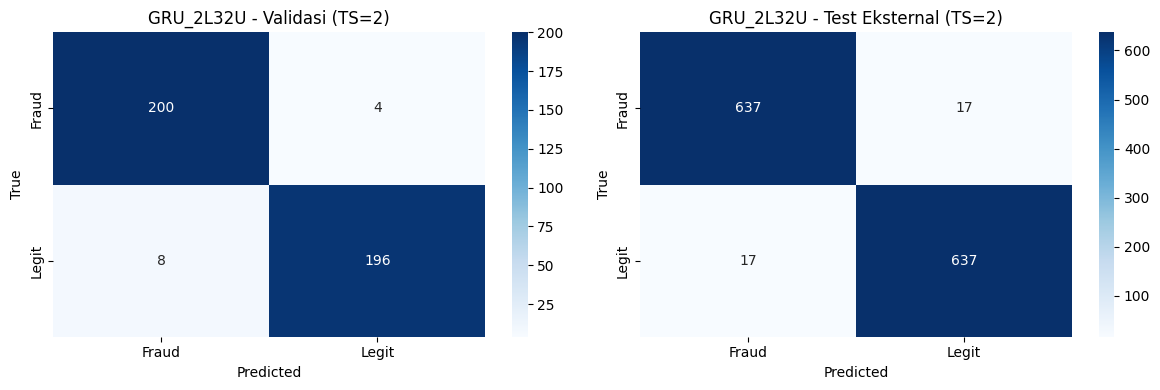

  F1:0.9740 | Recall:0.9740 | Params:12,129

Melatih GRU_3L16U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 2, 16)          │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 2, 16)          │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,393 (21.07 KB)

 Trainable params: 5,393 (21.07 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI GRU_3L16U (TS=2)


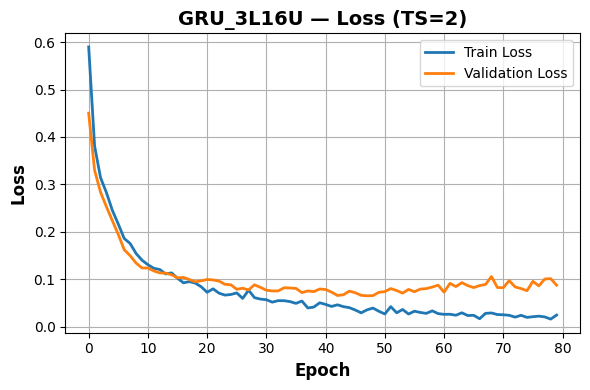

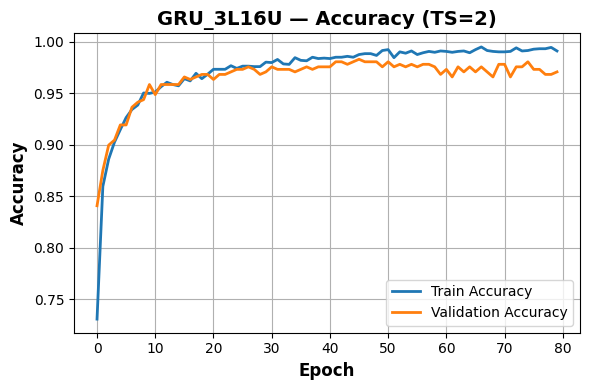

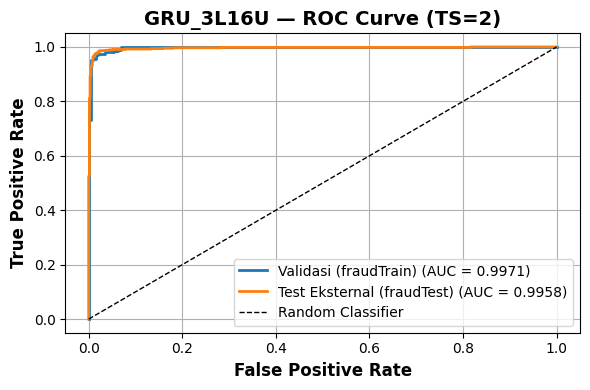


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.96      0.97       204
   Fraud (1)       0.96      0.98      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       654
   Fraud (1)       0.98      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



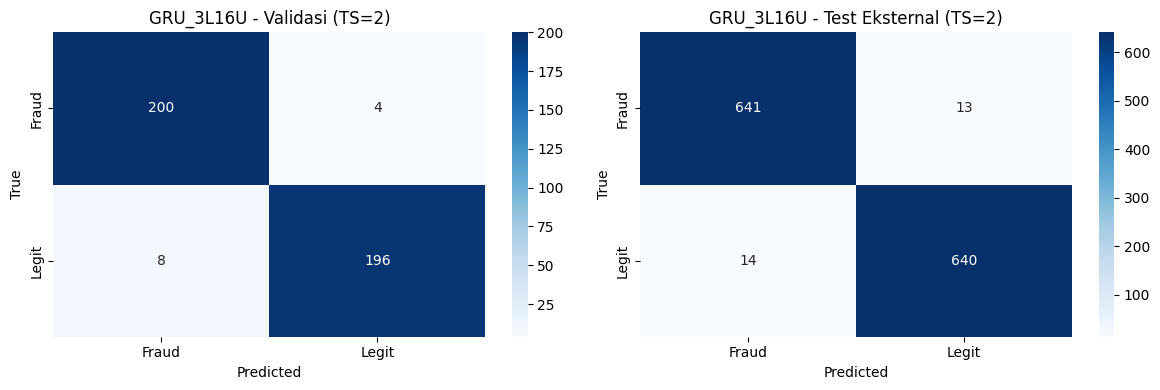

  F1:0.9794 | Recall:0.9801 | Params:5,393

Melatih BiGRU_2L32U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 2, 64)          │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiGRU_2L32U (TS=2)


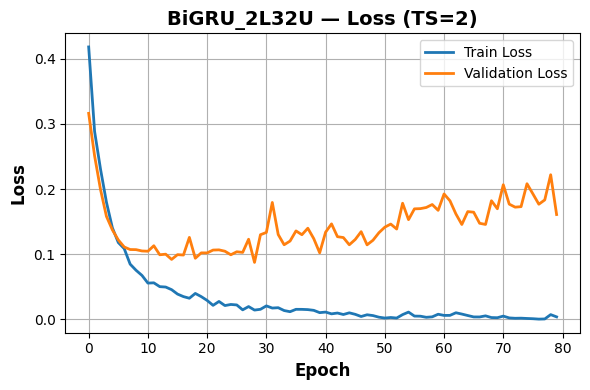

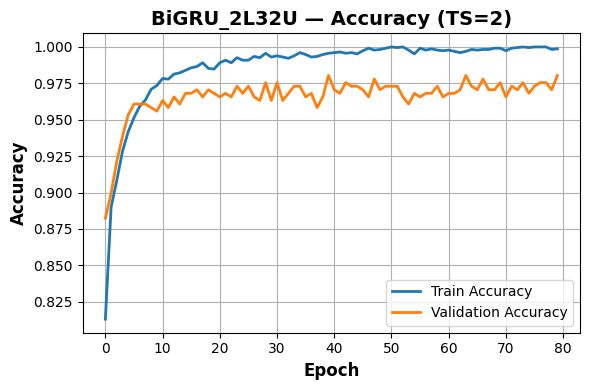

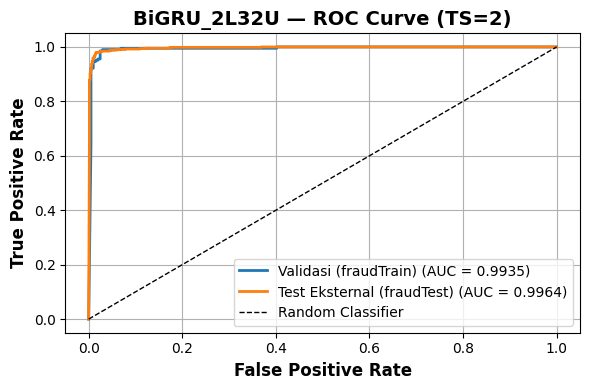


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.98      0.98       204
   Fraud (1)       0.98      0.99      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       654
   Fraud (1)       0.98      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



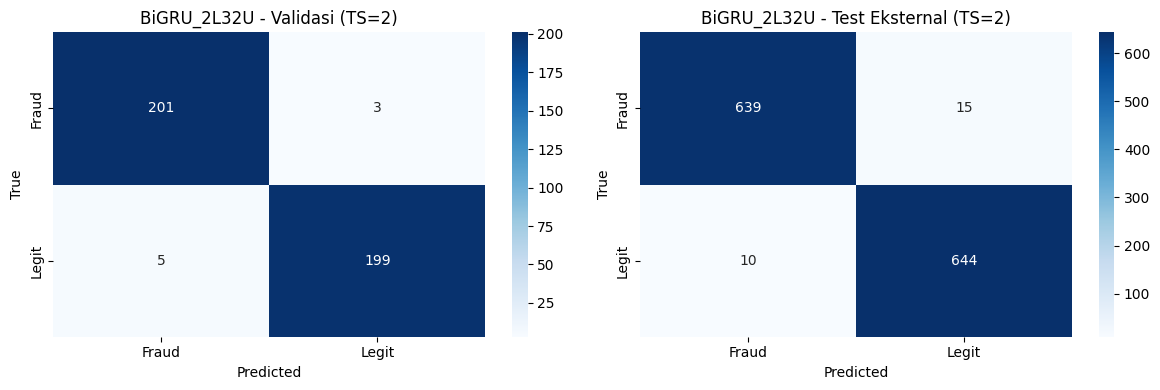

  F1:0.9808 | Recall:0.9771 | Params:30,401

Melatih BiGRU_1L32U...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_8 (Bidirectional) │ (None, 64)             │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,585 (45.25 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiGRU_1L32U (TS=2)


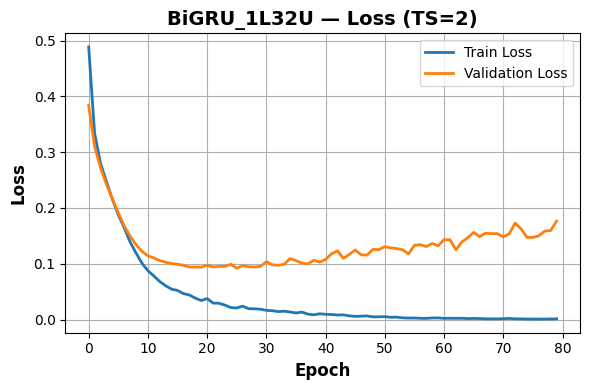

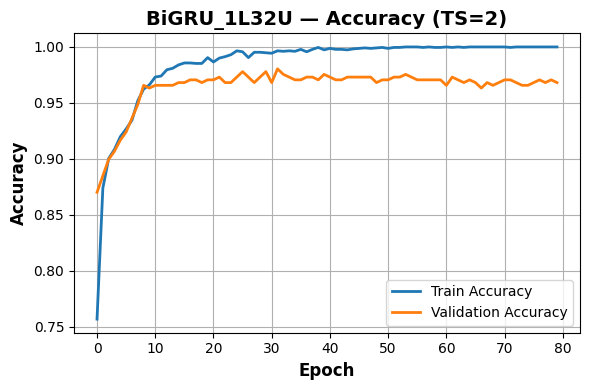

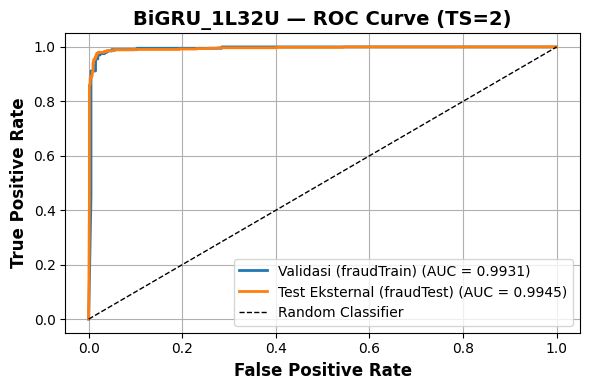


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.95      0.97       204
   Fraud (1)       0.95      0.99      0.97       204

    accuracy                           0.97       408
   macro avg       0.97      0.97      0.97       408
weighted avg       0.97      0.97      0.97       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.97       654
   Fraud (1)       0.97      0.98      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



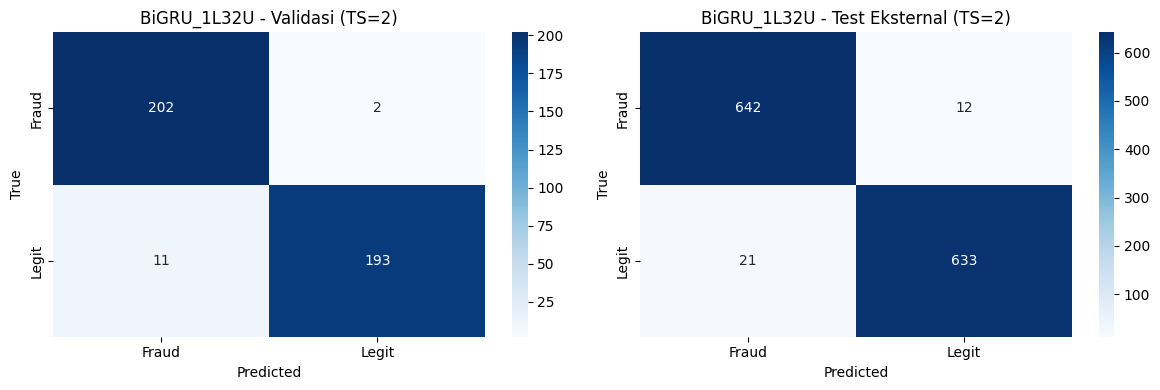

  F1:0.9749 | Recall:0.9817 | Params:11,585


In [ ]:
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

recap_configs = {
    'LSTM_2L32U':   lambda s: build_tuned_lstm(2, 32, s),
    'LSTM_1L8U':   lambda s: build_tuned_lstm(1, 8, s),
    'BiLSTM_2L32U': lambda s: build_tuned_bilstm(2, 32, s),
    'BiLSTM_4L8U':  lambda s: build_tuned_bilstm(4, 8, s),
    'GRU_2L32U':    lambda s: build_tuned_gru(2, 32, s),
    'GRU_3L16U':    lambda s: build_tuned_gru(3, 16, s),
    'BiGRU_2L32U':  lambda s: build_tuned_bigru(2, 32, s),
    'BiGRU_1L32U':  lambda s: build_tuned_bigru(1, 32, s),
}

recap_models  = {}
recap_results = []

for name, builder in recap_configs.items():
    print(f"\nMelatih {name}...")
    model = builder(INPUT_SHAPE)
    model.summary()
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                        epochs=80, batch_size=32, verbose=0)
    recap_models[name] = model
    model.save(f"model_recap_{name.lower()}.keras")

    # Evaluasi lengkap: training curves + AUC-ROC + classification report + confusion matrix
    evaluate_model(model, X_val, y_val, X_test_seq, y_test_seq,
                   name, CUSTOM_TIMESTEP, history=history)

    y_pred = (model.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_seq, y_pred, average='binary', pos_label=1)
    n_params = model.count_params()
    recap_results.append({'Model':name,'Precision':prec,'Recall':rec,'F1':f1,'Params':n_params})
    print(f"  F1:{f1:.4f} | Recall:{rec:.4f} | Params:{n_params:,}")


In [ ]:
df_recap = pd.DataFrame(recap_results).sort_values('F1', ascending=False).reset_index(drop=True)
print("\n=== Rekap 8 Model (Tanpa Attention) ===")
print(df_recap.to_string(index=False, float_format=lambda x: f"{x:.4f}" if x < 1e3 else f"{int(x):,}"))



=== Rekap 8 Model (Tanpa Attention) ===
       Model  Precision  Recall     F1  Params
 BiGRU_2L32U     0.9846  0.9771 0.9808   30401
   GRU_3L16U     0.9786  0.9801 0.9794    5393
 BiLSTM_4L8U     0.9741  0.9786 0.9764    7057
 BiGRU_1L32U     0.9683  0.9817 0.9749   11585
   GRU_2L32U     0.9740  0.9740 0.9740   12129
   LSTM_1L8U     0.9681  0.9755 0.9718    1129
BiLSTM_2L32U     0.9695  0.9725 0.9710   40001
  LSTM_2L32U     0.9709  0.9694 0.9702   15905


# Bagian 9 : Penambahan Mekanisme Attention pada 8 Model


## 9.1 Fungsi Builder dengan Attention

In [ ]:
def build_with_attention(base_type, input_shape, num_layers=2, num_units=32):
    inputs = Input(shape=input_shape)
    x = inputs
    for i in range(num_layers):
        if base_type == 'LSTM':
            x = LSTM(num_units, return_sequences=True)(x)
        elif base_type == 'BiLSTM':
            x = Bidirectional(LSTM(num_units, return_sequences=True))(x)
        elif base_type == 'GRU':
            x = GRU(num_units, return_sequences=True)(x)
        elif base_type == 'BiGRU':
            x = Bidirectional(GRU(num_units, return_sequences=True))(x)
        x = Dropout(0.3)(x)
    # Self-Attention
    scores  = Dense(1, activation='tanh')(x)
    weights = tf.keras.layers.Softmax(axis=1)(scores)
    context = Multiply()([x, weights])
    x       = Lambda(lambda z: tf.reduce_sum(z, axis=1))(context)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.001, weight_decay=1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

## 9.2 Pelatihan 8 Model + Attention


Melatih LSTM_2L32U_Attn...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 2, 32)     │      7,552 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2, 32)     │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 2, 32)     │      8,320 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2, 32)     │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2, 1)      │         33 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 2, 1)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 2, 32)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,938 (62.26 KB)

 Trainable params: 15,938 (62.26 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI LSTM_2L32U_Attn (TS=2)


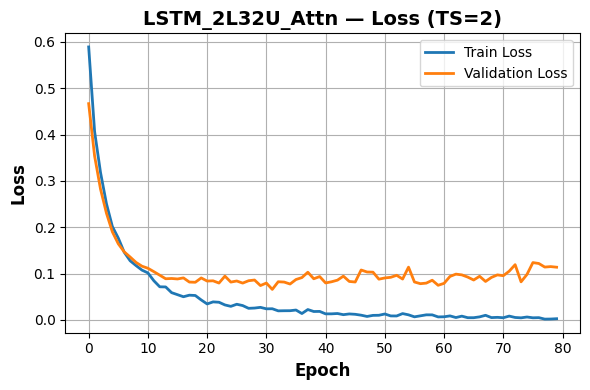

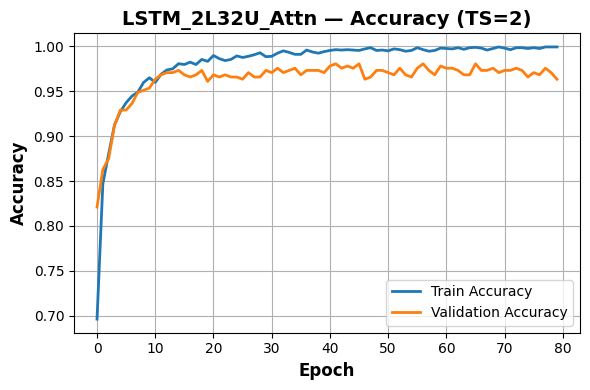

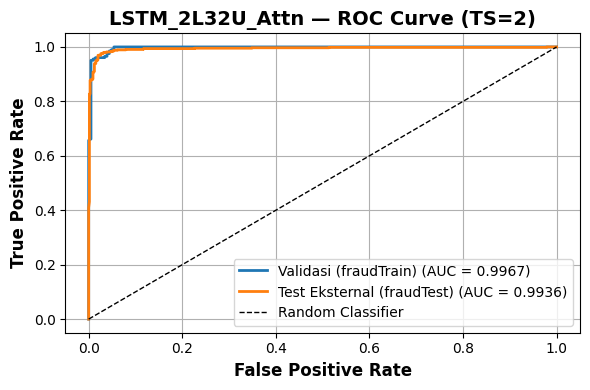


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.96      0.96       204
   Fraud (1)       0.96      0.97      0.96       204

    accuracy                           0.96       408
   macro avg       0.96      0.96      0.96       408
weighted avg       0.96      0.96      0.96       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



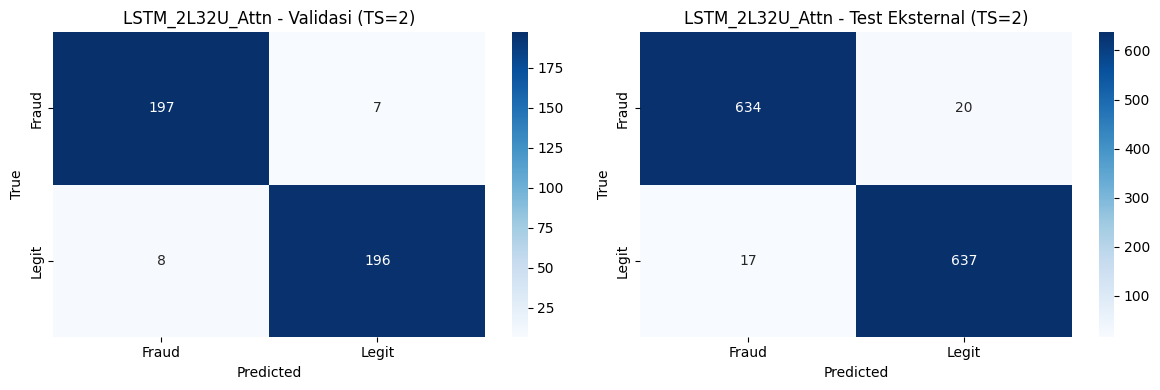

  F1:0.9716 | Recall:0.9694 | Params:15,938

Melatih LSTM_1L8U_Attn...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 2, 8)      │      1,120 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2, 8)      │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2, 1)      │          9 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 2, 1)      │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 2, 8)      │          0 │ dropout_2[0][0],  │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 8)         │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │          9 │ lambda_1[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,138 (4.45 KB)

 Trainable params: 1,138 (4.45 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI LSTM_1L8U_Attn (TS=2)


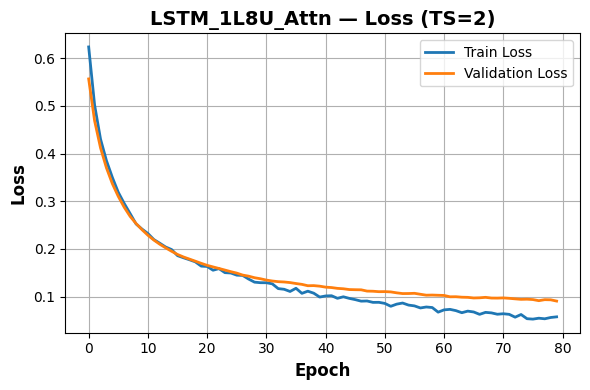

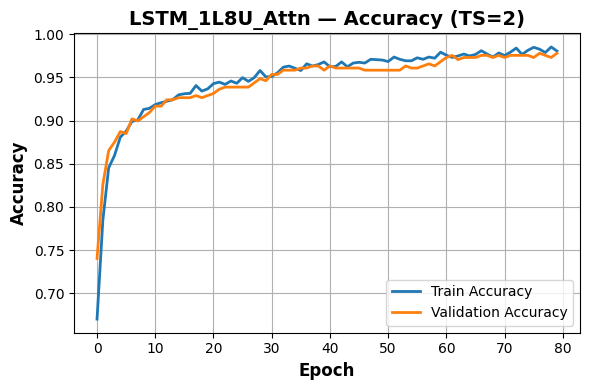

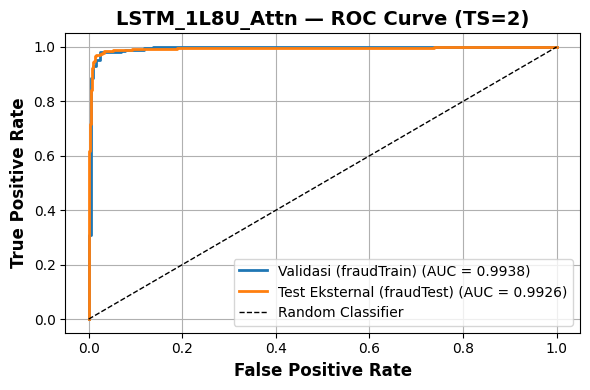


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       204
   Fraud (1)       0.98      0.98      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.96      0.99      0.98       654
   Fraud (1)       0.99      0.96      0.97       654

    accuracy                           0.97      1308
   macro avg       0.98      0.97      0.97      1308
weighted avg       0.98      0.97      0.97      1308



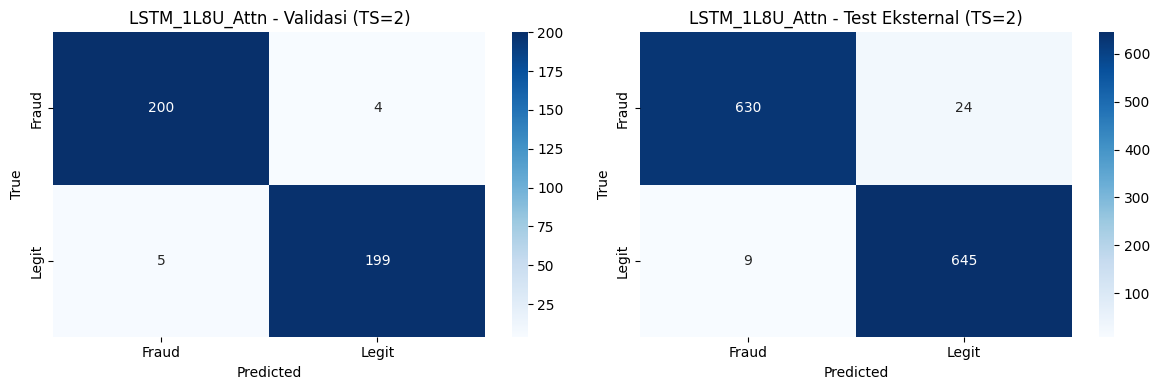

  F1:0.9745 | Recall:0.9633 | Params:1,138

Melatih BiLSTM_2L32U_Attn...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 2, 64)     │     15,104 │ input_layer_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2, 64)     │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 2, 64)     │     24,832 │ dropout_3[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 2, 64)     │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 2, 1)      │         65 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_2 (Softmax) │ (None, 2, 1)      │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 2, 64)     │          0 │ dropout_4[0][0],  │
│ (Multiply)          │                   │            │ softmax_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 64)        │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ lambda_2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,066 (156.51 KB)

 Trainable params: 40,066 (156.51 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiLSTM_2L32U_Attn (TS=2)


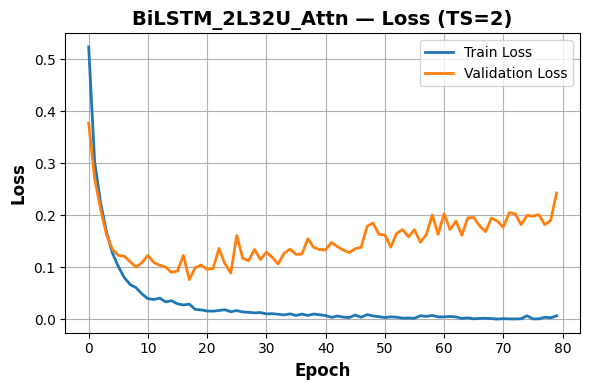

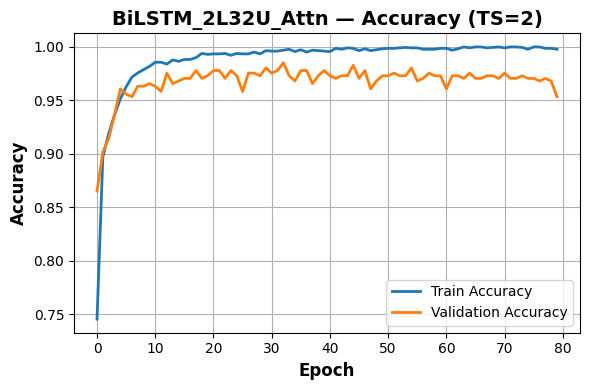

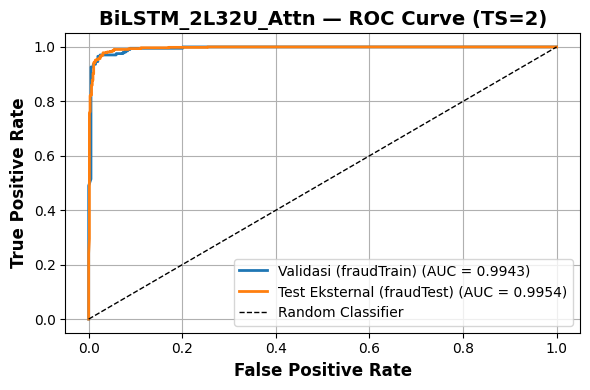


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.93      0.95       204
   Fraud (1)       0.93      0.98      0.95       204

    accuracy                           0.95       408
   macro avg       0.95      0.95      0.95       408
weighted avg       0.95      0.95      0.95       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.97      0.97      0.97       654
   Fraud (1)       0.97      0.97      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



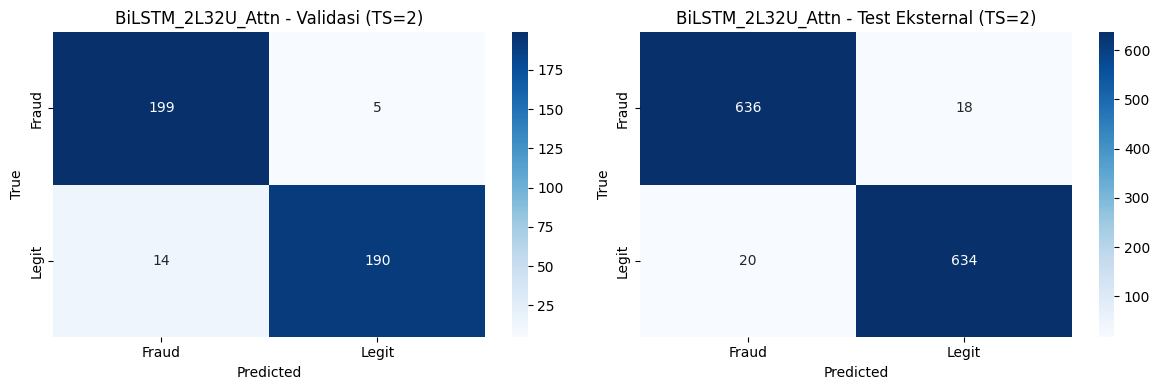

  F1:0.9710 | Recall:0.9725 | Params:40,066

Melatih BiLSTM_4L8U_Attn...


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 2, 16)     │      2,240 │ input_layer_3[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 2, 16)     │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 2, 16)     │      1,600 │ dropout_5[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 2, 16)     │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 2, 16)     │      1,600 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 2, 16)     │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 2, 16)     │      1,600 │ dropout_7[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 2, 16)     │          0 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 2, 1)      │         17 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_3 (Softmax) │ (None, 2, 1)      │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 2, 16)     │          0 │ dropout_8[0][0],  │
│ (Multiply)          │                   │            │ softmax_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 16)        │          0 │ multiply_3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         17 │ lambda_3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,074 (27.63 KB)

 Trainable params: 7,074 (27.63 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiLSTM_4L8U_Attn (TS=2)


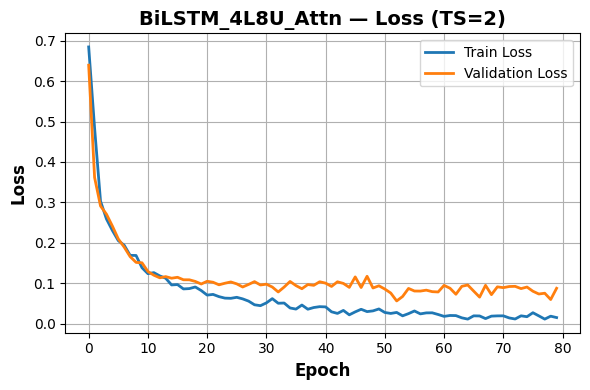

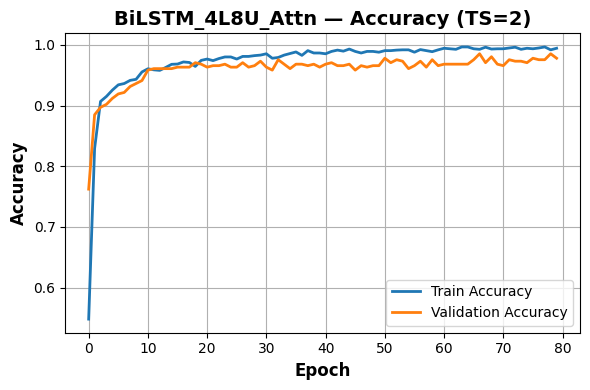

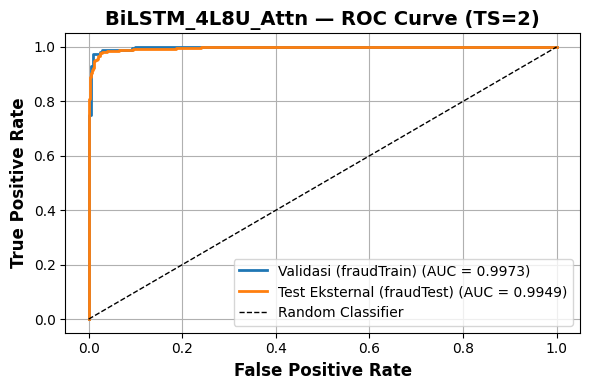


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.97      0.98       204
   Fraud (1)       0.97      0.99      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       654
   Fraud (1)       0.98      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



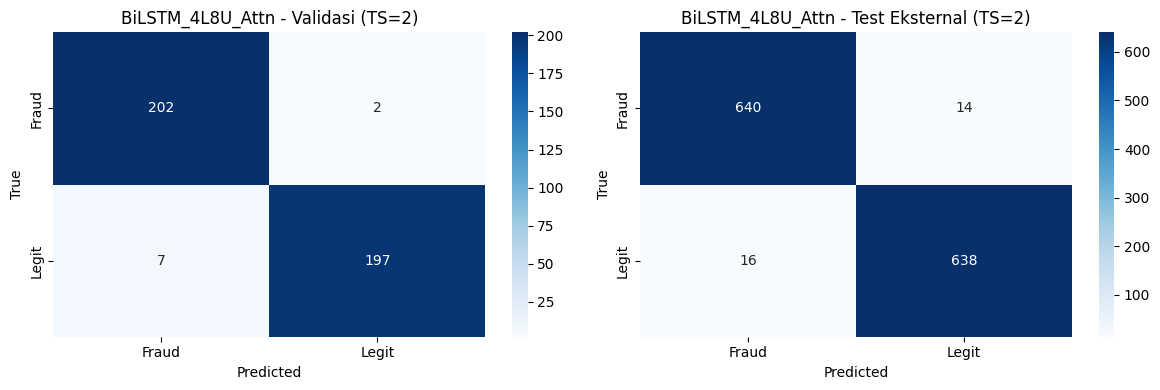

  F1:0.9771 | Recall:0.9786 | Params:7,074

Melatih GRU_2L32U_Attn...


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 2, 32)     │      5,760 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 2, 32)     │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 2, 32)     │      6,336 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 2, 32)     │          0 │ gru_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 2, 1)      │         33 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_4 (Softmax) │ (None, 2, 1)      │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 2, 32)     │          0 │ dropout_10[0][0], │
│ (Multiply)          │                   │            │ softmax_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 32)        │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         33 │ lambda_4[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,162 (47.51 KB)

 Trainable params: 12,162 (47.51 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI GRU_2L32U_Attn (TS=2)


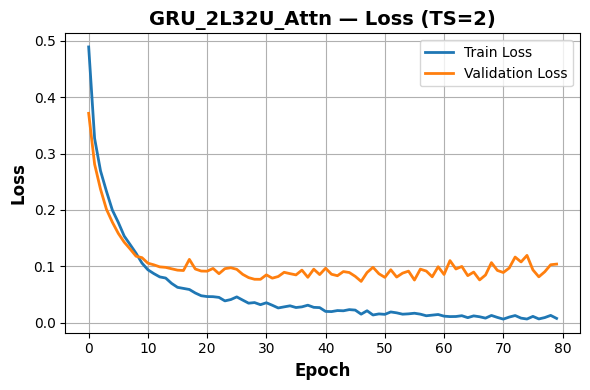

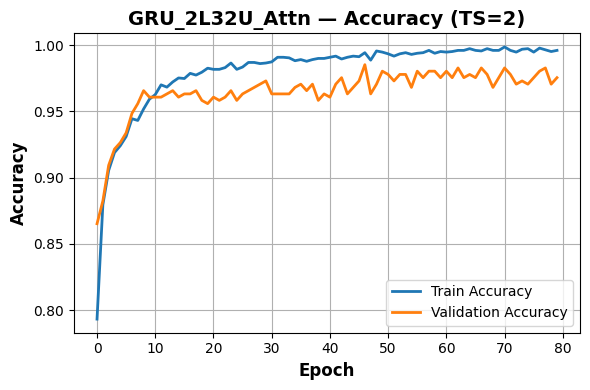

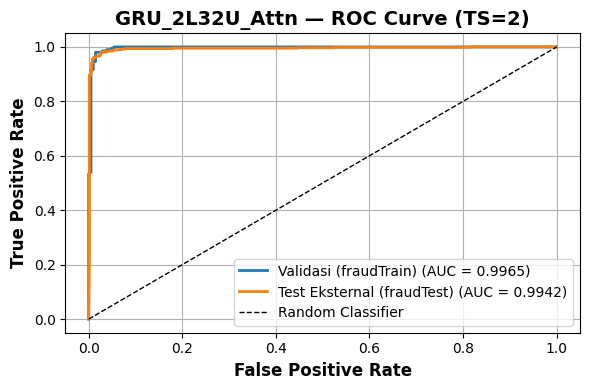


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.96      0.98       204
   Fraud (1)       0.96      0.99      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.97       654
   Fraud (1)       0.97      0.98      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



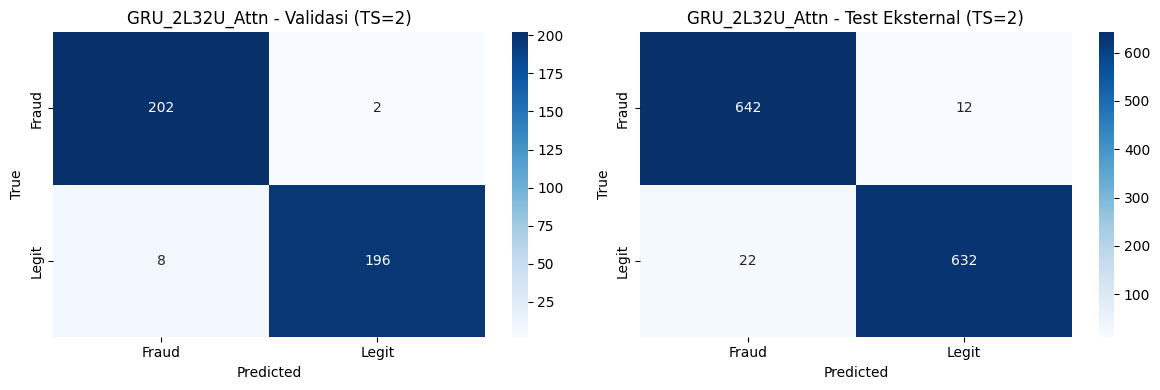

  F1:0.9742 | Recall:0.9817 | Params:12,162

Melatih GRU_3L16U_Attn...


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 2, 16)     │      2,112 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 2, 16)     │          0 │ gru_2[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_3 (GRU)         │ (None, 2, 16)     │      1,632 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 2, 16)     │          0 │ gru_3[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 2, 16)     │      1,632 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 2, 16)     │          0 │ gru_4[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 2, 1)      │         17 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_5 (Softmax) │ (None, 2, 1)      │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_5          │ (None, 2, 16)     │          0 │ dropout_13[0][0], │
│ (Multiply)          │                   │            │ softmax_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 16)        │          0 │ multiply_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         17 │ lambda_5[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,410 (21.13 KB)

 Trainable params: 5,410 (21.13 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI GRU_3L16U_Attn (TS=2)


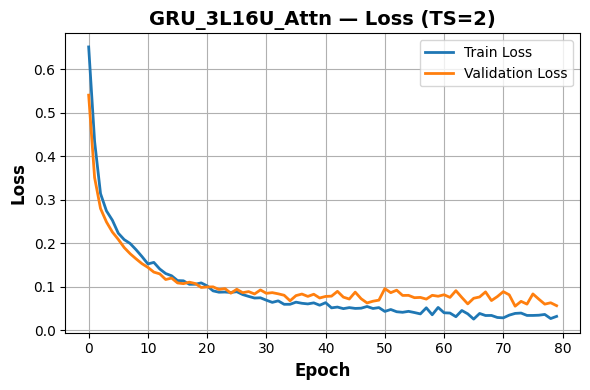

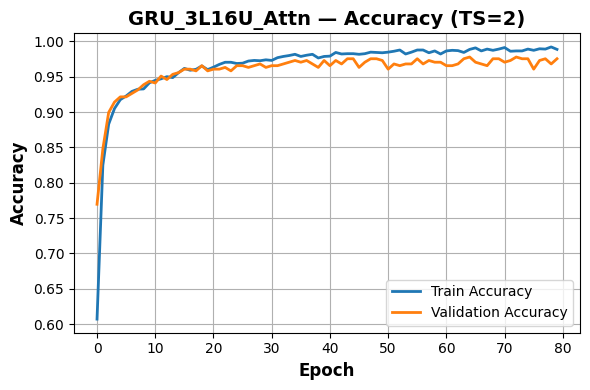

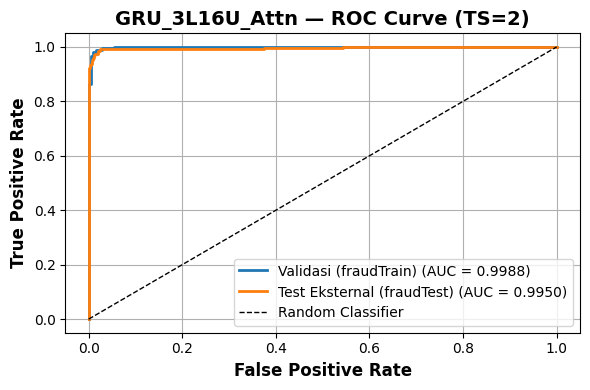


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.99      0.96      0.97       204
   Fraud (1)       0.96      1.00      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       654
   Fraud (1)       0.98      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



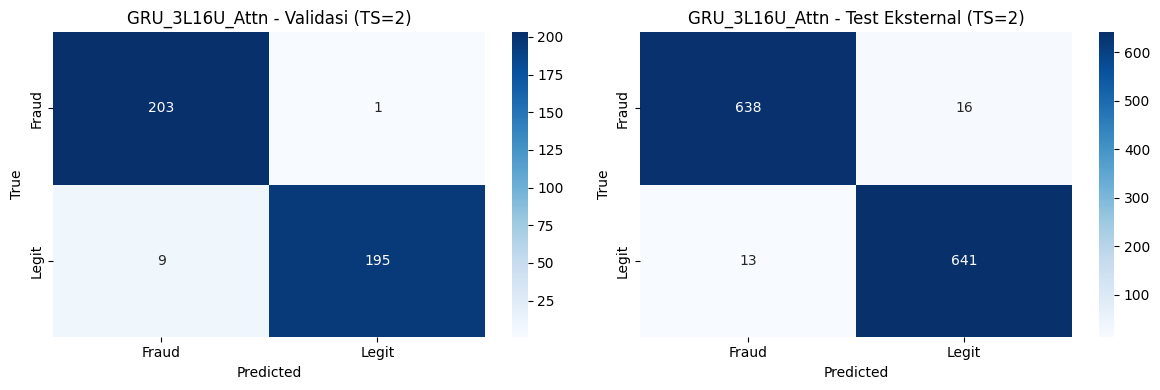

  F1:0.9778 | Recall:0.9755 | Params:5,410

Melatih BiGRU_2L32U_Attn...


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 2, 64)     │     11,520 │ input_layer_6[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 2, 64)     │          0 │ bidirectional_6[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 2, 64)     │     18,816 │ dropout_14[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 2, 64)     │          0 │ bidirectional_7[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 2, 1)      │         65 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_6 (Softmax) │ (None, 2, 1)      │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 2, 64)     │          0 │ dropout_15[0][0], │
│ (Multiply)          │                   │            │ softmax_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 64)        │          0 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         65 │ lambda_6[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,466 (119.01 KB)

 Trainable params: 30,466 (119.01 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiGRU_2L32U_Attn (TS=2)


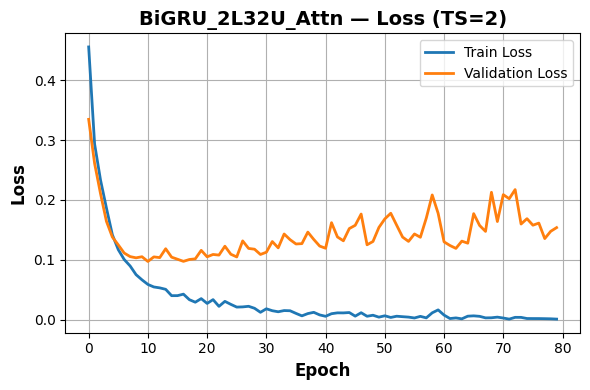

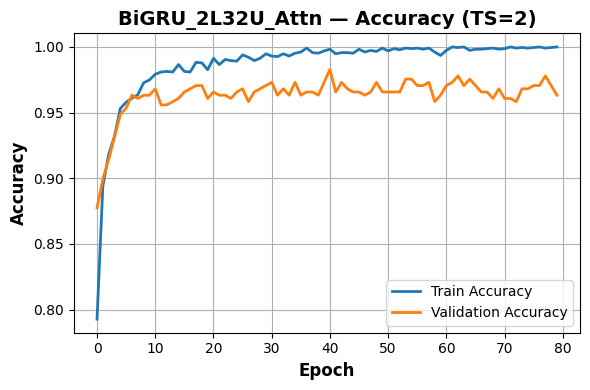

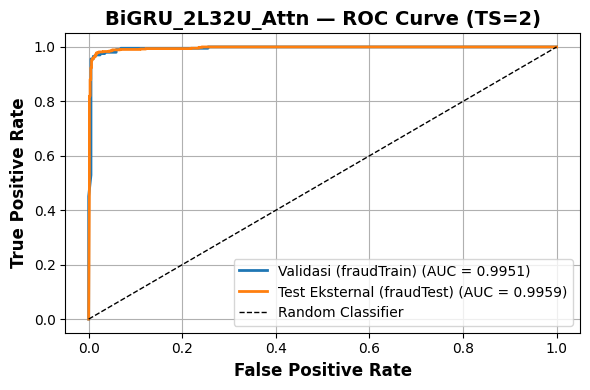


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.95      0.96       204
   Fraud (1)       0.95      0.98      0.96       204

    accuracy                           0.96       408
   macro avg       0.96      0.96      0.96       408
weighted avg       0.96      0.96      0.96       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.98      0.98       654
   Fraud (1)       0.98      0.98      0.98       654

    accuracy                           0.98      1308
   macro avg       0.98      0.98      0.98      1308
weighted avg       0.98      0.98      0.98      1308



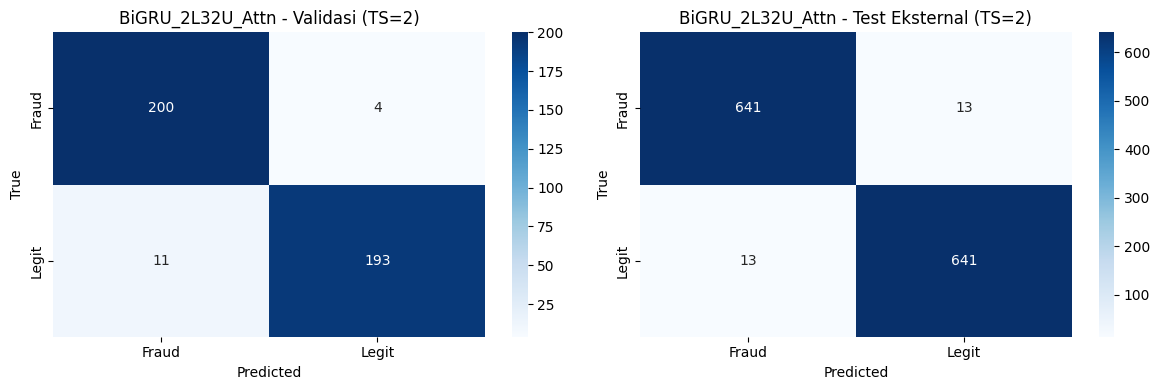

  F1:0.9801 | Recall:0.9801 | Params:30,466

Melatih BiGRU_1L32U_Attn...


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 2, 26)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 2, 64)     │     11,520 │ input_layer_7[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 2, 64)     │          0 │ bidirectional_8[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 2, 1)      │         65 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_7 (Softmax) │ (None, 2, 1)      │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 2, 64)     │          0 │ dropout_16[0][0], │
│ (Multiply)          │                   │            │ softmax_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 64)        │          0 │ multiply_7[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         65 │ lambda_7[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,650 (45.51 KB)

 Trainable params: 11,650 (45.51 KB)

 Non-trainable params: 0 (0.00 B)


EVALUASI BiGRU_1L32U_Attn (TS=2)


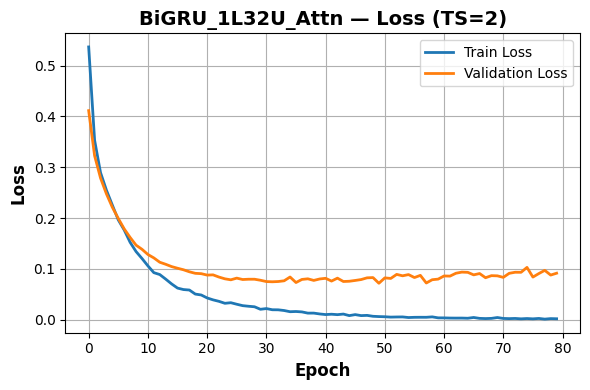

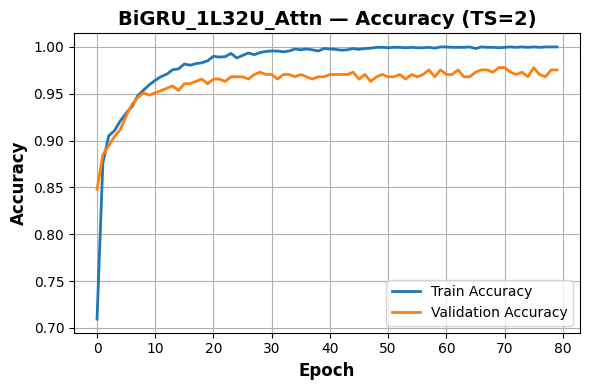

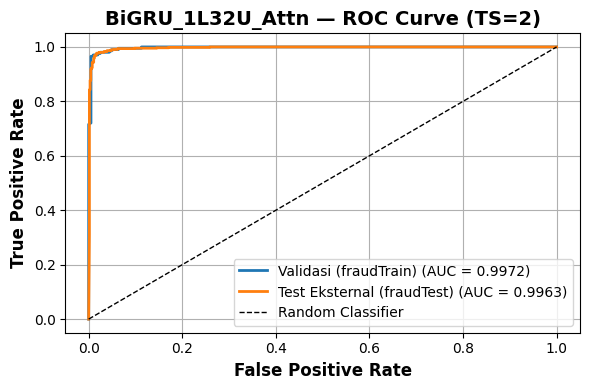


[VALIDASI (fraudTrain)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.98       204
   Fraud (1)       0.97      0.98      0.98       204

    accuracy                           0.98       408
   macro avg       0.98      0.98      0.98       408
weighted avg       0.98      0.98      0.98       408


[TEST EKSTERNAL (fraudTest)]
              precision    recall  f1-score   support

   Legit (0)       0.98      0.97      0.97       654
   Fraud (1)       0.97      0.98      0.97       654

    accuracy                           0.97      1308
   macro avg       0.97      0.97      0.97      1308
weighted avg       0.97      0.97      0.97      1308



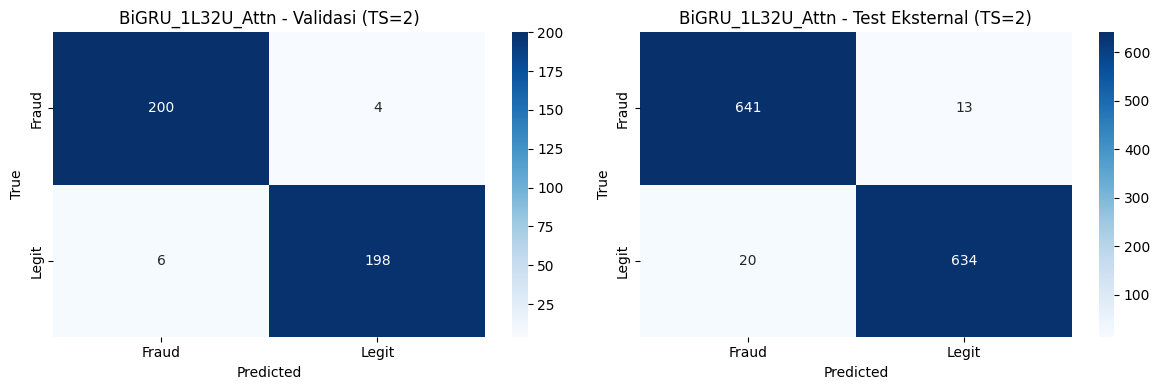

  F1:0.9749 | Recall:0.9801 | Params:11,650


In [ ]:
tf.keras.backend.clear_session()
tf.compat.v1.enable_eager_execution()

attention_configs = {
    'LSTM_2L32U_Attn':   lambda s: build_with_attention('LSTM',   s, 2, 32),
    'LSTM_1L8U_Attn':    lambda s: build_with_attention('LSTM',   s, 1, 8),
    'BiLSTM_2L32U_Attn': lambda s: build_with_attention('BiLSTM', s, 2, 32),
    'BiLSTM_4L8U_Attn':  lambda s: build_with_attention('BiLSTM', s, 4, 8),
    'GRU_2L32U_Attn':    lambda s: build_with_attention('GRU',    s, 2, 32),
    'GRU_3L16U_Attn':    lambda s: build_with_attention('GRU',    s, 3, 16),
    'BiGRU_2L32U_Attn':  lambda s: build_with_attention('BiGRU',  s, 2, 32),
    'BiGRU_1L32U_Attn':  lambda s: build_with_attention('BiGRU',  s, 1, 32),
}

attn_models  = {}
attn_results = []

for name, builder in attention_configs.items():
    print(f"\nMelatih {name}...")
    model = builder(INPUT_SHAPE)
    model.summary()
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                        epochs=80, batch_size=32, verbose=0)
    attn_models[name] = model
    model.save(f"model_attn_{name.lower()}.keras")

    evaluate_model(model, X_val, y_val, X_test_seq, y_test_seq,
                   name, CUSTOM_TIMESTEP, history=history)

    y_pred = (model.predict(X_test_seq, verbose=0) > 0.5).astype(int).flatten()
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test_seq, y_pred, average='binary', pos_label=1)
    n_params = model.count_params()
    attn_results.append({'Model':name,'Precision':prec,'Recall':rec,'F1':f1,'Params':n_params})
    print(f"  F1:{f1:.4f} | Recall:{rec:.4f} | Params:{n_params:,}")

# Bagian 10 : Rekapitulasi 16 Model (Tanpa Attention + Dengan Attention)

In [ ]:
df_no_attn   = pd.DataFrame(recap_results).assign(Attention='Tanpa Attention')
df_with_attn = pd.DataFrame(attn_results).assign(Attention='Dengan Attention')
df_all_16    = (pd.concat([df_no_attn, df_with_attn], ignore_index=True)
                .sort_values('F1', ascending=False)
                .reset_index(drop=True))

print(f"\n=== Rekapitulasi {len(df_all_16)} Model (Tanpa Attention + Dengan Attention) ===")
print(df_all_16[['Model','Attention','Precision','Recall','F1','Params']].to_string(
    index=False, float_format=lambda x: f"{x:.4f}" if x < 1e3 else f"{int(x):,}"))


=== Rekapitulasi 16 Model (Tanpa Attention + Dengan Attention) ===
            Model        Attention  Precision  Recall     F1  Params
      BiGRU_2L32U  Tanpa Attention     0.9846  0.9771 0.9808   30401
 BiGRU_2L32U_Attn Dengan Attention     0.9801  0.9801 0.9801   30466
        GRU_3L16U  Tanpa Attention     0.9786  0.9801 0.9794    5393
   GRU_3L16U_Attn Dengan Attention     0.9800  0.9755 0.9778    5410
 BiLSTM_4L8U_Attn Dengan Attention     0.9756  0.9786 0.9771    7074
      BiLSTM_4L8U  Tanpa Attention     0.9741  0.9786 0.9764    7057
      BiGRU_1L32U  Tanpa Attention     0.9683  0.9817 0.9749   11585
 BiGRU_1L32U_Attn Dengan Attention     0.9697  0.9801 0.9749   11650
   LSTM_1L8U_Attn Dengan Attention     0.9859  0.9633 0.9745    1138
   GRU_2L32U_Attn Dengan Attention     0.9669  0.9817 0.9742   12162
        GRU_2L32U  Tanpa Attention     0.9740  0.9740 0.9740   12129
        LSTM_1L8U  Tanpa Attention     0.9681  0.9755 0.9718    1129
  LSTM_2L32U_Attn Dengan Attention 

# Bagian 11 : Pemilihan 4 Model Terbaik (1 LSTM, 1 BiLSTM, 1 GRU, 1 BiGRU)


## 11.1 Seleksi Arsitektur Terbaik: Tanpa Attention vs Dengan Attention

Setiap arsitektur (LSTM, BiLSTM, GRU, BiGRU) memiliki 2 kandidat:
- Versi **tanpa attention** (dari Bagian 8)
- Versi **dengan attention** (dari Bagian 9)

Pemilihan dilakukan berdasarkan **F1-Score tertinggi** (seri → pilih yang lebih sedikit parameter).
Hasil seleksi ini yang akan dilatih ulang 7× di sub-bagian berikutnya.

In [ ]:
BEST_LSTM_NAME   = 'LSTM_1L8U'
BEST_BILSTM_NAME = 'BiLSTM_4L8U_Attn'
BEST_GRU_NAME    = 'GRU_2L32U_Attn'
BEST_BIGRU_NAME  = 'BiGRU_1L32U'
print(f"\nModel terpilih: {BEST_LSTM_NAME} | {BEST_BILSTM_NAME} | {BEST_GRU_NAME} | {BEST_BIGRU_NAME}")



Model terpilih: LSTM_1L8U | BiLSTM_4L8U_Attn | GRU_2L32U_Attn | BiGRU_1L32U


# Bagian 12 : Cross Validation 4 Model Terbaik (K = 7)


## 12.1 Fungsi Builder CV (sesuai model terpilih)

In [ ]:
def _is_attn(name): return '_Attn' in name

def _parse_config(name):
    if '3L32' in name: return 3, 32
    if '2L32' in name: return 2, 32
    if '1L32' in name: return 1, 32
    if '1L16' in name: return 1, 16
    if '1L8'  in name: return 1, 8
    if '3L16' in name: return 3, 16
    if '4L8'  in name: return 4, 8
    return 2, 32   # fallback

def build_cv_best_lstm(input_shape):
    nl, nu = _parse_config(BEST_LSTM_NAME)
    if _is_attn(BEST_LSTM_NAME):
        return build_with_attention('LSTM', input_shape, nl, nu)
    return build_tuned_lstm(nl, nu, input_shape)

def build_cv_best_bilstm(input_shape):
    nl, nu = _parse_config(BEST_BILSTM_NAME)
    if _is_attn(BEST_BILSTM_NAME):
        return build_with_attention('BiLSTM', input_shape, nl, nu)
    return build_tuned_bilstm(nl, nu, input_shape)

def build_cv_best_gru(input_shape):
    nl, nu = _parse_config(BEST_GRU_NAME)
    if _is_attn(BEST_GRU_NAME):
        return build_with_attention('GRU', input_shape, nl, nu)
    return build_tuned_gru(nl, nu, input_shape)

def build_cv_best_bigru(input_shape):
    nl, nu = _parse_config(BEST_BIGRU_NAME)
    if _is_attn(BEST_BIGRU_NAME):
        return build_with_attention('BiGRU', input_shape, nl, nu)
    return build_tuned_bigru(nl, nu, input_shape)

## 12.2 Cross Validation LSTM Terbaik


CROSS VALIDATION (K=7) — LSTM_1L8U (TS=2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1/7 -> Recall: 0.9845 | Precision: 0.9845 | F1: 0.9845


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2/7 -> Recall: 0.9794 | Precision: 0.9845 | F1: 0.9819


...

  Fold 5/7 -> Recall: 0.9845 | Precision: 0.9795 | F1: 0.9820


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6/7 -> Recall: 0.9639 | Precision: 0.9689 | F1: 0.9664


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7/7 -> Recall: 0.9534 | Precision: 0.9840 | F1: 0.9684

Tabel Hasil Statistik CV (fraudTrain — Validation Fold):
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9712          0.0001             0.0119
       Precision            0.9756          0.0001             0.0100
        F1-Score            0.9734          0.0001             0.0089


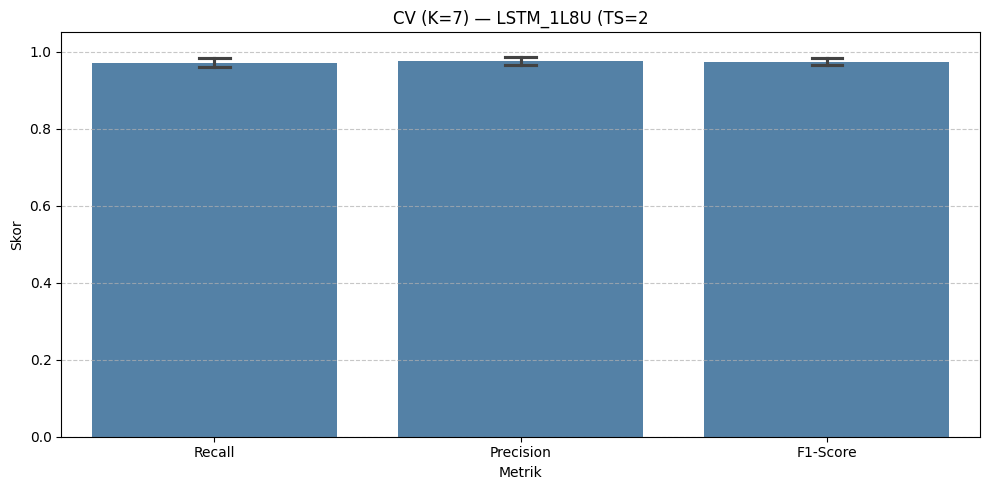

In [ ]:
df_cv_lstm = run_cross_validation(
    build_cv_best_lstm, X_train_seq, y_train_seq,
    INPUT_SHAPE, BEST_LSTM_NAME, CUSTOM_TIMESTEP, k=7)


## 12.3 Cross Validation BiLSTM Terbaik


CROSS VALIDATION (K=7) — BiLSTM_4L8U_Attn (TS=2)
  Fold 1/7 -> Recall: 0.9897 | Precision: 0.9796 | F1: 0.9846
  Fold 2/7 -> Recall: 0.9794 | Precision: 0.9896 | F1: 0.9845
  Fold 3/7 -> Recall: 0.9691 | Precision: 0.9691 | F1: 0.9691
  Fold 4/7 -> Recall: 0.9691 | Precision: 0.9641 | F1: 0.9666
  Fold 5/7 -> Recall: 0.9845 | Precision: 0.9695 | F1: 0.9770
  Fold 6/7 -> Recall: 0.9536 | Precision: 0.9788 | F1: 0.9661
  Fold 7/7 -> Recall: 0.9689 | Precision: 0.9842 | F1: 0.9765

Tabel Hasil Statistik CV (fraudTrain — Validation Fold):
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9735          0.0001             0.0121
       Precision            0.9764          0.0001             0.0092
        F1-Score            0.9749          0.0001             0.0079


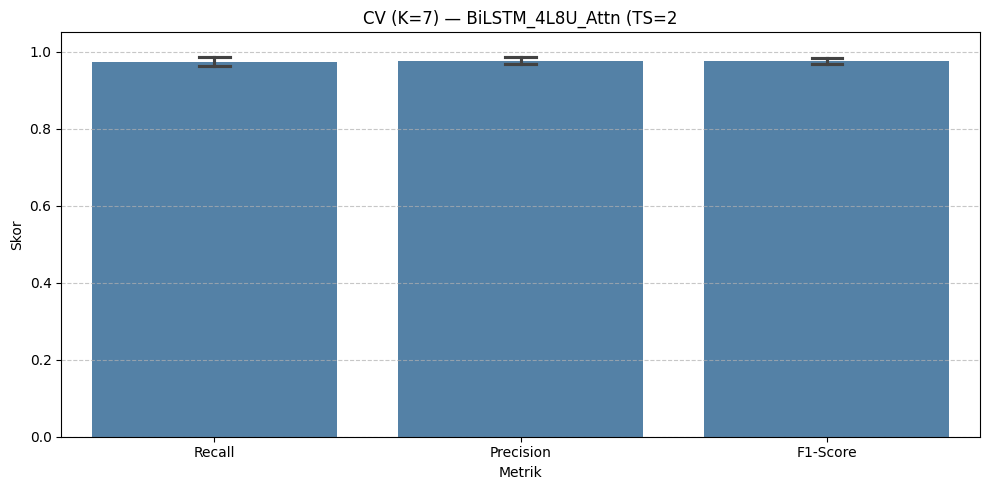

In [ ]:
df_cv_bilstm = run_cross_validation(
    build_cv_best_bilstm, X_train_seq, y_train_seq,
    INPUT_SHAPE, BEST_BILSTM_NAME, CUSTOM_TIMESTEP, k=7)


## 12.4 Cross Validation GRU Terbaik


CROSS VALIDATION (K=7) — GRU_2L32U_Attn (TS=2)
  Fold 1/7 -> Recall: 0.9691 | Precision: 0.9895 | F1: 0.9792
  Fold 2/7 -> Recall: 0.9845 | Precision: 0.9695 | F1: 0.9770
  Fold 3/7 -> Recall: 0.9794 | Precision: 0.9645 | F1: 0.9719
  Fold 4/7 -> Recall: 0.9639 | Precision: 0.9444 | F1: 0.9541
  Fold 5/7 -> Recall: 0.9897 | Precision: 0.9697 | F1: 0.9796
  Fold 6/7 -> Recall: 0.9742 | Precision: 0.9692 | F1: 0.9717
  Fold 7/7 -> Recall: 0.9637 | Precision: 0.9789 | F1: 0.9713

Tabel Hasil Statistik CV (fraudTrain — Validation Fold):
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9749          0.0001             0.0101
       Precision            0.9694          0.0002             0.0138
        F1-Score            0.9721          0.0001             0.0087


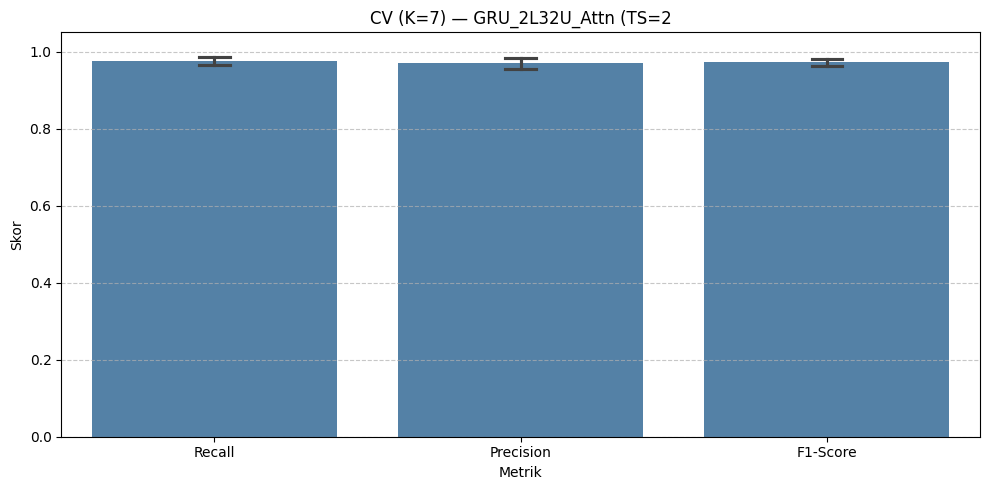

In [ ]:
df_cv_gru = run_cross_validation(
    build_cv_best_gru, X_train_seq, y_train_seq,
    INPUT_SHAPE, BEST_GRU_NAME, CUSTOM_TIMESTEP, k=7)


## 12.5 Cross Validation BiGRU Terbaik


CROSS VALIDATION (K=7) — BiGRU_1L32U (TS=2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 1/7 -> Recall: 0.9845 | Precision: 0.9845 | F1: 0.9845


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 2/7 -> Recall: 0.9742 | Precision: 0.9793 | F1: 0.9767


...

  Fold 5/7 -> Recall: 0.9897 | Precision: 0.9648 | F1: 0.9771


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 6/7 -> Recall: 0.9639 | Precision: 0.9639 | F1: 0.9639


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Fold 7/7 -> Recall: 0.9637 | Precision: 0.9841 | F1: 0.9738

Tabel Hasil Statistik CV (fraudTrain — Validation Fold):
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9757          0.0001             0.0098
       Precision            0.9729          0.0001             0.0102
        F1-Score            0.9742          0.0000             0.0065


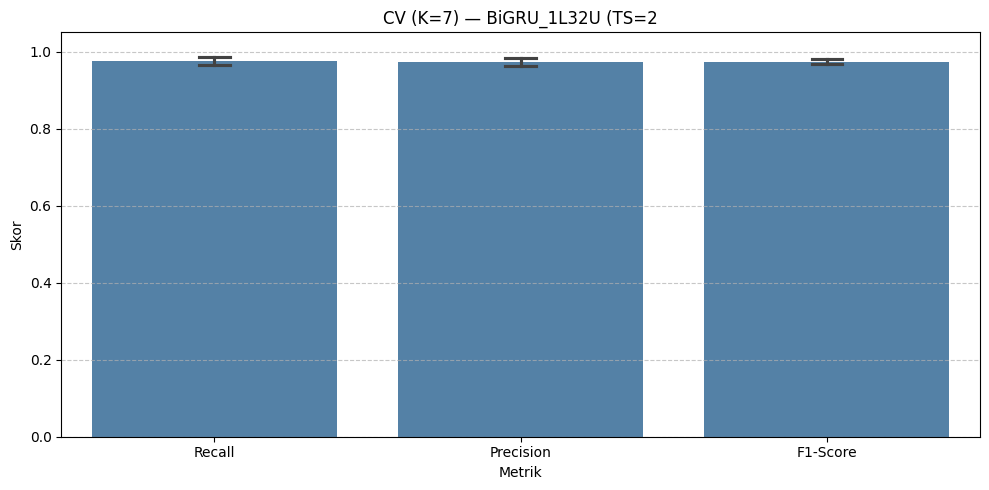

In [ ]:
df_cv_bigru = run_cross_validation(
    build_cv_best_bigru, X_train_seq, y_train_seq,
    INPUT_SHAPE, BEST_BIGRU_NAME, CUSTOM_TIMESTEP, k=7)

## 12.6 Rekap Akhir Cross Validation

In [ ]:
for mname, df_cv in [(BEST_LSTM_NAME,   df_cv_lstm),
                     (BEST_BILSTM_NAME, df_cv_bilstm),
                     (BEST_GRU_NAME,    df_cv_gru),
                     (BEST_BIGRU_NAME,  df_cv_bigru)]:
    print(f"\n=== {mname} ===")
    print(df_cv.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== LSTM_1L8U ===
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9712          0.0001             0.0119
       Precision            0.9756          0.0001             0.0100
        F1-Score            0.9734          0.0001             0.0089

=== BiLSTM_4L8U_Attn ===
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9735          0.0001             0.0121
       Precision            0.9764          0.0001             0.0092
        F1-Score            0.9749          0.0001             0.0079

=== GRU_2L32U_Attn ===
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
          Recall            0.9749          0.0001             0.0101
       Precision            0.9694          0.0002             0.0138
        F1-Score            0.9721          0.0001             0.0087

=== BiGRU_1L32U ===
Metrik Fraud (1)  Rata-rata (Mean)  Variansi (Var)  Std Deviasi (Std)
